# LRD dust $A_V$ Constraint Project

## 准备

### Imports

In [1]:
import sys, os
from pathlib import Path

# 设置路径为 project 的路径。按需调整
project_path = Path('~/Codes/JWST_LRD_SED/LRD_dust_modeling').expanduser()
os.chdir(project_path)

# 添加 src 目录到 sys.path，从而让 LRD_IR_spectrum 模块可以被找到
module_path = project_path / 'src'
sys.path.insert(0, str(module_path))


from LRD_IR_spectrum import *  # 从 LRD_IR_spectrum 中 import 所有符号，方便使用
from LRD_IR_spectrum.common_imports import *  # 一键导入在多个 notebook 中都要用到的模块

# u.set_enabled_equivalencies(u.spectral())  # enable convenient equivalencies for converting between nu, lambda

In [57]:
# # 让 inline 绘图使用 pdf 格式，变得清晰很多！
# # 但对于 pcolormesh 图似乎会造成 vscode 卡退！
# from matplotlib_inline.backend_inline import set_matplotlib_formats
# set_matplotlib_formats('svg', 'pdf')

In [58]:
# deep reload LRD_IR_spectrum
import LRD_IR_spectrum
deep_reload(LRD_IR_spectrum)
from LRD_IR_spectrum import *

### Cosmology

In [59]:
# 定义宇宙学参数，用于观测到的 f_nu 与 L_nu 之间的转换 （需要光度距离）

from astropy.cosmology import Cosmology, FlatLambdaCDM, WMAP9, Planck18
cosmo: Cosmology = WMAP9  # Setton+2025 所用的，Labbe 和 Wang 的 SED
# cosmo: Cosmology = FlatLambdaCDM(H0=70, Om0=0.3)  # Delvecchio+2025 所用的
# cosmo = Planck18  # Akins+2024 所用的

### joblib 并行

In [60]:
# joblib.parallel_config(n_jobs=-1)
joblib.parallel_config(n_jobs=10)

## Data

### Opacity

#### Orion

In [6]:
# Orion
Orion_opacity = OpacityData.from_file('data/opacity_law/Orion.opc', ignore_scatter=True)  #* ignore scatter 以与其他几个数据保持一致，并且能量守恒严格成立

#### from extinction models

In [7]:
from dust_extinction.grain_models import WD01

# 让这几个在 V band 处与 Orion 保持一致
#* 注意：dust_extinction 包内部对「V Band」波长的定义实际上是「model 的数据表中 1/λ 最接近 0.55 um 的那个波长」，而非我采用的 5470 AA。这导致 SMC_opacity.sigma_H_ext_V / Orion_opacity.sigma_H_ext_V 并不严格为 1 （无论采样有多精细）
MW_RV31_opacity = OpacityData.from_extinction_model(model=WD01('MWRV31'), sigma_H_V=Orion_opacity.sigma_H_ext_V)
SMC_opacity = OpacityData.from_extinction_model(model=WD01('SMCBar'), sigma_H_V=Orion_opacity.sigma_H_ext_V)

In [8]:
# ISM R_V=3.1 的 A_V 与 N_H 的转换系数为 5.3e-22，来自 Draine 2011 书上 21.7 式。
# 由此计算出的截面为: 
5.3e-22 * u.cm**2 / 1.086
# 比 Orion 的大 13 倍。其中 10 倍是由于 Orion 取了 0.1 solar metallicity，但剩下的呢？

<Quantity 4.88029466e-22 cm2>

#### Noll 2009

In [9]:
def Calzetti_k(lam: Quantity['length']):
    """
    Calzetti et al. (2000) 公式 (4) 中定义 k(lambda) 函数，但不含结尾的 + R_V 项
    """
    l = np.asarray(lam.to_value(u.um))

    poly = np.piecewise(
        l,
        [
            (0.12 <= l) & (l < 0.63), 
            (0.63 <= l) & (l <= 2.20)
        ],
        [
            lambda l: -2.156 + 1.509/l - 0.198/(l**2) + 0.011/(l**3),
            lambda l: -1.857 + 1.040/l,
            np.nan  # 超出波长范围，默认值为 NaN
        ]
    )
    k = 2.659 * poly
    # 保持标量输入时输出为 float
    if np.isscalar(lam.value):
        return float(k)
    return k

def Noll_2009(lam: Quantity['length'], delta: float = 0):
    """Noll et al. (2009) 公式 (4) 中定义的 modified Calzetti law。但目前不包含 bump 项和 c_R 补偿项。
    """
    R_V = 4.05
    A_rel = (Calzetti_k(lam) / R_V + 1) * (lam / (5500 * u.AA)).cgs**delta
    return A_rel

def super_SMC_A_rel(lam: Quantity['length'], delta: float = 0):    
    A_rel = np.where((0.12*u.um <= lam) & (lam <= 0.55*u.um), 
             Noll_2009(lam, delta=delta), 
             WD01('SMCBar')(lam)
             )
    # A_rel[lam < 0.12 * u.um] = np.nan #TEMP
    return A_rel

In [10]:
# Noll 2009 with delta = -1.8
lam = SMC_opacity.wavelength[SMC_opacity.wavelength > 0.12*u.um]  # 短波部分不要，因为 Calzetti law 不适用
# lam = SMC_opacity.wavelength[SMC_opacity.wavelength > 0.1 *u.um]  # 短波部分不要，因为 Calzetti law 不适用 #TEMP 改为 0.1 um，这样 Akins 的一个数据点进得来
super_SMC_opacity = OpacityData.from_extinction_data(x=lam, A_rel=super_SMC_A_rel(lam, delta = -1.8), sigma_H_V=Orion_opacity.sigma_H_ext_V)

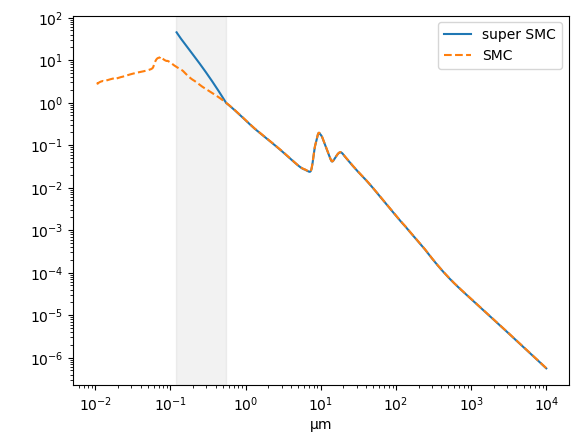

In [11]:
plt.loglog(super_SMC_opacity.wavelength, super_SMC_opacity.sigma_H_ext / super_SMC_opacity.sigma_H_ext_V, label='super SMC')
plt.loglog(SMC_opacity.wavelength, SMC_opacity.sigma_H_ext / SMC_opacity.sigma_H_ext_V, '--', label='SMC')
plt.axvspan(0.12, 0.547, alpha=.1, color='gray')
plt.legend()

#### 汇总

In [12]:
opacity_dict = {'Orion': Orion_opacity, 'MW': MW_RV31_opacity, 'SMC': SMC_opacity, 'super SMC': super_SMC_opacity}
opacity_display_names = {
    'Orion': 'Orion Nebula',
    'MW': 'Milky Way',
    'SMC': 'SMC',
    'super SMC': r'$\delta=-1.8$',
}

#### 波段裁剪

In [13]:
w = Orion_opacity.wavelength
w.size, w[(4e-2 * u.um < w) & (w < 3e2 * u.um)].size

(9244, 2679)

In [14]:
w = SMC_opacity.wavelength
w.size, w[(4e-2 * u.um < w) & (w < 3e2 * u.um)].size

(1000, 645)

In [15]:
[4e-2, 3e2] * u.um

<Quantity [4.e-02, 3.e+02] um>

### SED

#### 定义函数

In [16]:
def create_SED_table_from_observed_flux(observed_flux: QTable, cosmo: Cosmology) -> QTable:
    """从 observed_flux 创建一个 SED_table，包含 wavelength, nu, Lnu 在 rest frame 和 obs frame 下的值  
    需要 observed_flux 这个 QTable 中有 wavelength_obs 和 fnu_obs 两列，并且其 .meta 中有 z 和 magnification 字段
    """

    SED_table = observed_flux.copy()  # copy 一个新的，不改变输入的

    # 转换 wavelength
    SED_table['wavelength_rest'] = SED_table['wavelength_obs'] / (1 + SED_table.meta['z'])
    SED_table['nu_obs'] = SED_table['wavelength_obs'].to(u.Hz, equivalencies=u.spectral())
    SED_table['nu_rest'] = SED_table['wavelength_rest'].to(u.Hz, equivalencies=u.spectral())

    # 从 fnu_obs 计算 nu_L_nu 以及相关量
    SED_table['Lnu_rest'] = L_nu_rest_from_f_nu(  # 从 fnu_obs 计算出 Lnu_rest，运用宇宙学光度距离
        f_nu=SED_table['fnu_obs'],
        cosmology=cosmo,
        z=SED_table.meta['z'],
        magnification=SED_table.meta['magnification'], 
    ).to(u.Lsun/u.Hz) 
    SED_table['nu_L_nu'] = SED_table['nu_rest'] * SED_table['Lnu_rest']
    SED_table['Lnu_obs'] = SED_table['nu_L_nu'] / SED_table['nu_obs']

    return SED_table

In [17]:
def read_table_and_set_meta(filename, *, meta=None, **kwargs):
    """
    读取表格并设置元数据
    """
    table = QTable.read(filename, **kwargs)
    if meta is not None:
        table.meta.update(meta)
    return table

#### Temple Template

In [18]:
# Temple_SED = SED.from_file('data/raw/quasar5.template')
# Temple_SED = SED.from_file('data/raw/quasar5_ly.template')

#### Labbe & Wang photometric data (from Setton 2025)

In [19]:
def read_SED_table(filename: str, *, z: float, magnification: float = 1.0) -> QTable:
    """从数据文件中读取 SED 数据，返回 QTable 类型的数据表。
    假定两列分别是波长和 nu_L_nu，单位分别是 micron 和 Lsun。
    """
    raw_data = Table.read(filename, format='ascii', names=['lambda', 'nu_L_nu'], )
    SED_table = QTable({'wavelength_obs': raw_data['lambda'] * u.micron, 
                        'nu_L_nu': raw_data['nu_L_nu'] * u.Lsun},
                        meta={'z': z, 'magnification': magnification})
    SED_table['wavelength_rest'] = SED_table['wavelength_obs'] / (1 + SED_table.meta['z'])
    SED_table['nu_obs'] = SED_table['wavelength_obs'].to(u.Hz, equivalencies=u.spectral())
    SED_table['nu_rest'] = SED_table['wavelength_rest'].to(u.Hz, equivalencies=u.spectral())
    SED_table['Lnu_obs'] = SED_table['nu_L_nu'] / SED_table['nu_obs']
    SED_table['Lnu_rest'] = SED_table['nu_L_nu'] / SED_table['nu_rest']
    
    # 标记各个波段。注意：这些波长范围可能只适用于 Setton 的两个源
    w = SED_table['wavelength_obs']
    SED_table['Instrument'] = ' '*10  # 初始化为 n 个空格，n 足够大以保证后续赋值不被截断
    instrument = SED_table['Instrument']
    instrument[w < 6 * u.um] = 'NIRCam'
    instrument[(w >= 6 * u.um) & (w < 22 * u.um)] = 'MIRI'
    instrument[(w >= 22 * u.um) & (w < 40 * u.um)] = 'Spitzer'
    instrument[(w >= 40 * u.um) & (w < 400 * u.um)] = 'Herschel'
    instrument[w >= 400 * u.um] = 'ALMA'
    
    # 标记每个点是探测到的还是 upper limit
    SED_table['detection'] = False
    SED_table['detection'][(instrument == 'NIRCam') | (instrument == 'MIRI')] = True
    
    return SED_table

In [20]:
# Setton et al. 2025, Fig 4.a
# A2744-45924
# 政融从图上描下来的。
Labbe_photo = read_SED_table('data/raw/Setton25.csv', z=4.4655, magnification=1.7)

In [21]:
Labbe_photo.colnames

['wavelength_obs',
 'nu_L_nu',
 'wavelength_rest',
 'nu_obs',
 'nu_rest',
 'Lnu_obs',
 'Lnu_rest',
 'Instrument',
 'detection']

In [22]:
#TEMP 尝试：人工把 Labbe 的数据放大 10 倍和缩小 10 倍，看看效果

Labbe_photo_modified = {'1e1': Labbe_photo.copy(), '1e-1': Labbe_photo.copy()}

for colname in ['nu_L_nu', 'Lnu_obs', 'Lnu_rest']:
    Labbe_photo_modified['1e1'][colname] *= 10
    Labbe_photo_modified['1e-1'][colname] *= 0.1

In [23]:
# Setton et al. 2025, Fig 4.b
# RUBIES-BLAGN-1
# 政融从图上描下来的。
Wang_photo = read_SED_table('data/raw/Wang.csv', z=3.1034, magnification=1)

In [24]:
# Labbe_photo = Wang_photo  #TEMP 临时替换

In [25]:
Labbe_SED = SED.from_QTable(Labbe_photo)
# Wang_SED = SED.from_QTable(Wang_photo)

In [26]:
# Appendix，处理审稿人的 Major Comment 1，去除 Balmer Break 之前的 UV incident light 的贡献
wavelength_Balmer_break = 364.5 * u.nm
Labbe_photo_ignore_UV: QTable = Labbe_photo[Labbe_photo['wavelength_rest'] >= wavelength_Balmer_break]

In [27]:
#TEMP: 尝试把 MIRI 的数据减半
# def MIRI_reduce(sed: SED, factor: float = 1.0) -> SED:
#     import copy
#     mask = (2*u.um <= sed.wavelength) & (sed.wavelength <= 8*u.um)
#     new_sed = copy.deepcopy(sed)  # 不改变原来的
#     new_sed.L_nu[mask] *= factor
#     return new_sed

# MIRI_reduce_factor = 0.5
# Labbe_SED_MIRI_reduced = MIRI_reduce(Labbe_SED, factor=MIRI_reduce_factor)
# Labbe_SED_MIRI_remain = MIRI_reduce(Labbe_SED, factor=1-MIRI_reduce_factor)
# Labbe_SED_selected_MIRI_reduced = Labbe_SED_MIRI_reduced.select_wavelength_range(max=8 * u.um).refine(100)  #TEMP

<SecondaryAxis: xlabel='Observed $\\lambda$ [$\\mu m$]'>

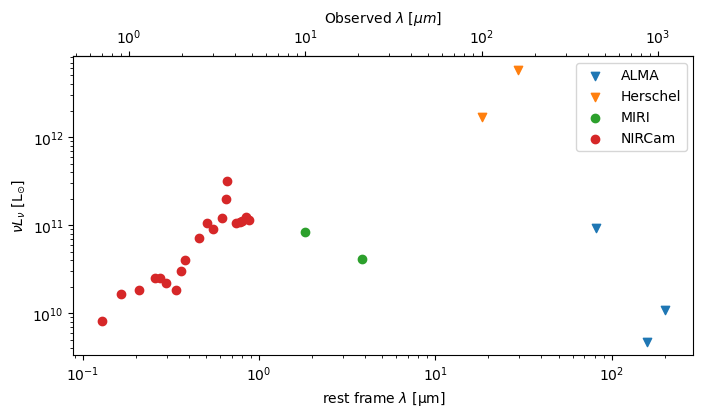

In [28]:
instrument_markers = {'NIRCam': 'o', 'MIRI': 'o', 'Spitzer': 'v', 'Herschel': 'v', 'ALMA': 'v'}

SED_table = Labbe_photo
# SED_table = Wang_photo

fig, ax = plt.subplots(figsize=(8, 6))
# ax.scatter(x='wavelength_rest', y='nu_L_nu', data=SED_table, s=10, label='Setton 2025')
for instrument in np.unique(SED_table['Instrument']):
    mask = SED_table['Instrument'] == instrument
    ax.scatter(x='wavelength_rest', y='nu_L_nu', data=SED_table[mask], s=6**2, label=instrument,
               marker=instrument_markers[instrument])

ax.set_xlabel(fr'rest frame $\lambda$ [{ax.get_xlabel()}]') 
ax.set_ylabel(fr'$\nu L_\nu$ [{ax.get_ylabel()}]') 
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_aspect(.5)
ax.legend()

add_wavelength_obs_xaxis(ax, z=SED_table.meta['z'],)


#### Labbe spectrum

In [29]:
Labbe_spec_raw = read_table_and_set_meta('data/observed_spectrum/uncover-v2_prism-clear_2561_45924.spec.fits', meta=Labbe_photo.meta)
Labbe_spec_observed = Labbe_spec_raw[~Labbe_spec_raw['flux'].mask].copy()  # 只取没被 mask 的部分
Labbe_spec_observed.rename_columns(['wave', 'flux'], ['wavelength_obs', 'fnu_obs'])

Labbe_spec = create_SED_table_from_observed_flux(Labbe_spec_observed, cosmo=WMAP9)

#### Delvecchio 2025 Stacking SED

In [30]:
cosmo_Delvecchio = FlatLambdaCDM(H0=70, Om0=0.3)

Delvecchio_stacking_photo_raw = QTable.read('data/raw/Delvecchio_stacking.tex', 
                                            format='ascii.latex', 
                                            data_start=6, # 跳过表格的 header 和 单位
                                            units=[u.um, 1, u.mJy, u.mJy, u.mJy])

Delvecchio_stacking_photo = QTable({'wavelength_obs': Delvecchio_stacking_photo_raw['wavelength'], 
                                    'fnu_obs': np.char.lstrip(Delvecchio_stacking_photo_raw['Flux'], '<').astype(float), 
                                    'detection': ~np.char.startswith(Delvecchio_stacking_photo_raw['Flux'], '<').value  # 以表格中 Flux 一列是否以 < 开头来判断是否探测到
                                    }, 
                                   meta={'z': 6.2, 'magnification': 1})  # z=6.2 is the median redshift 

# 使用这个函数来覆写 Delvecchio_stacking_photo
Delvecchio_stacking_photo = create_SED_table_from_observed_flux(Delvecchio_stacking_photo, cosmo=cosmo_Delvecchio)

In [31]:
# # 导出，发给 Kohei 用
# Delvecchio_stacking_photo.write('data/export/Delvecchio_stacking_2.csv', format='ascii.csv', overwrite=True, comment='blablabla')

In [32]:
# Delvecchio_stacking_SED = SED.from_QTable(Delvecchio_stacking_photo)

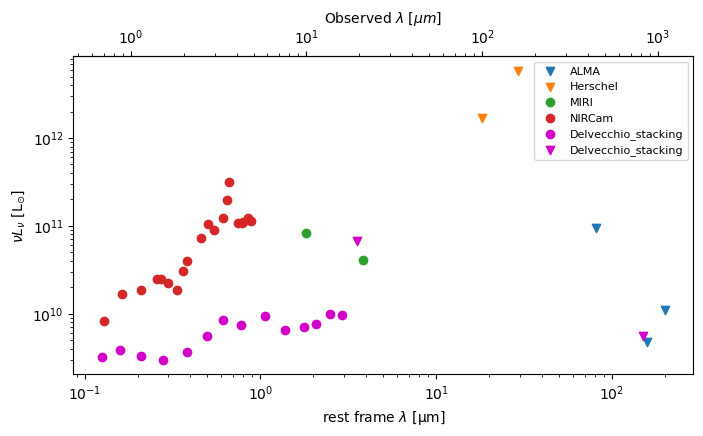

In [33]:
# 接续前面的 Labbe_photo 的绘图，画上 Delvecchio_stacking_photo

SED_table = Delvecchio_stacking_photo

# fig, ax = plt.subplots(figsize=(8, 6))

for detection_type in [True, False]:
    mask = SED_table['detection'] == detection_type
    ax.scatter(x='wavelength_rest', y='nu_L_nu', data=SED_table[mask], 
               s=6**2, label='Delvecchio_stacking', marker={True: 'o', False: 'v'}[detection_type], 
               color="#d300c9"
               )

ax.set_aspect(.5)
ax.legend(fontsize=8)

fig

#### Akins 2024 Stacking SED

In [34]:
Akins_stacking_raw = QTable.read('data/raw/Akins_stacking.txt', format='ascii.tab')
Akins_stacking_raw = Akins_stacking_raw[~np.char.startswith(Akins_stacking_raw['Band'], 'Chandra')]  # 去掉 Chandra 的数据，这些 X ray 数据用不着，而且 F_nu 格式不好 parse
Akins_stacking_raw = Akins_stacking_raw[~np.char.startswith(Akins_stacking_raw['Band'], 'VLA')]
Akins_stacking_raw = Akins_stacking_raw[~np.char.startswith(Akins_stacking_raw['Band'], 'MeerKAT')]
Akins_stacking_raw = Akins_stacking_raw[~np.char.startswith(Akins_stacking_raw['Band'], 'HST')]   # 去掉 HST 的数据，因为这俩数据点波长太短了，超出了 Noll 2009 opacity 的波长范围（在计算 re-emission 时取的是 opacity 的 nu 插值的）。影响不大，因为 0.9 um 有 JWST 的数据点

In [35]:
Akins_stacking_raw

Band,Wavelength,N,Units,F_nu,col5
str19,str9,int64,str14,str18,int64
JWST/NIRCam F090W,0.90 mum,29,nJy,7.37 +or- 1.22,--
JWST/NIRCam F115W,1.16 mum,434,nJy,15.76 +or- 0.62,--
JWST/NIRCam F150W,1.50 mum,434,nJy,16.46 +or- 0.51,--
JWST/NIRCam F200W,2.00 mum,29,nJy,17.66 +or- 0.77,--
JWST/NIRCam F277W,2.77 mum,434,nJy,30.51 +or- 0.23,--
JWST/NIRCam F356W,3.58 mum,29,nJy,83.30 +or- 0.56,--
JWST/NIRCam F410M,4.08 mum,29,nJy,113.56 +or- 1.03,--
JWST/NIRCam F444W,4.42 mum,434,nJy,173.00 +or- 0.33,--
JWST/MIRI F770W,7.66 mum,148,nJy,277.99 +or- 2.94,--


In [36]:
_col_Units = [u.Unit(s) for s in np.char.replace(Akins_stacking_raw['Units'], 'muJy', 'uJy')]

_col_F_nu = Akins_stacking_raw['F_nu']
_col_F_nu = np.char.lstrip(_col_F_nu, '<(')
_col_F_nu = [l[0] for l in np.char.split(_col_F_nu, ' +or- ')]
_col_F_nu = u.Quantity(_col_F_nu, dtype=float)
# _col_F_nu * _col_Units

In [37]:
cosmo_Akins = Planck18

Akins_stacking_photo = QTable(
    {
        'wavelength_obs': u.Quantity([u.Quantity(_str) for _str in np.char.replace(Akins_stacking_raw['Wavelength'], 'mum', 'um')]),
        'fnu_obs': u.Quantity(value=[num * unit for num, unit in zip(_col_F_nu, _col_Units)]),
        'detection': ~(np.char.startswith(Akins_stacking_raw['F_nu'], '<') | 
                       np.char.startswith(Akins_stacking_raw['F_nu'], '(')
                       ).value  # 以表格中 F_nu 一列是否以 < 开头来判断是否探测到
    },
    meta={'z': 6, 'magnification': 1}  # Akins et al. (2024) 的样本，取红移 z=6 ?
)


# 使用这个函数来覆写 Akins_stacking_photo
Akins_stacking_photo = create_SED_table_from_observed_flux(Akins_stacking_photo, cosmo=cosmo_Akins)

In [38]:
Akins_stacking_photo

wavelength_obs,fnu_obs,detection,wavelength_rest,nu_obs,nu_rest,Lnu_rest,nu_L_nu,Lnu_obs
um,nJy,,um,Hz,Hz,solLum / Hz,solLum,solLum / Hz
float64,float64,bool,float64,float64,float64,float64,float64,float64
0.9,7.37,True,0.1285714285714286,333102731111111.06,2331719117777777.5,1.1446024823876026e-06,2668891490.439075,8.012217376713218e-06
1.16,15.76,True,0.1657142857142857,258441774137931.06,1809092418965517.2,2.4476167058926207e-06,4427964827.163692,1.7133316941248345e-05
1.5,16.46,True,0.21428571428571427,199861638666666.66,1399031470666666.8,2.5563306458751613e-06,3576387023.008997,1.7894314521126132e-05
2.0,17.66,True,0.2857142857142857,149896229000000.0,1049273603000000.1,2.7426974001309444e-06,2877839982.974129,1.9198881800916613e-05
2.77,30.51,True,0.39571428571428574,108228324187725.62,757598269314079.4,4.738374726953291e-06,3589784492.5013866,3.3168623088673036e-05
3.58,83.3,True,0.5114285714285715,83740910055865.92,586186370391061.5,1.2936958857922291e-05,7583468956.82396,9.055871200545604e-05
4.08,113.56,True,0.5828571428571429,73478543627450.98,514349805392156.9,1.763650717773896e-05,9071334034.667412,0.00012345555024417272
4.42,173.0,True,0.6314285714285715,67826347963800.91,474784435746606.3,2.6867873738542094e-05,12756448272.66477,0.00018807511616979465


In [39]:
# # 导出，发给 Kohei 用
# Akins_stacking_photo.write('data/export/Akins_stacking.csv', format='ascii.csv', overwrite=True)

In [40]:
import astropy.table

mask = (70 * u.um <= Akins_stacking_photo['wavelength_obs']) & (Akins_stacking_photo['wavelength_obs'] <= 500 * u.um)

Delvecchio_and_Akins_stacking_photo = astropy.table.vstack([Delvecchio_stacking_photo, Akins_stacking_photo[mask]])

#### Akins 2025 所有 LRDs

In [41]:
Akins_all_raw = QTable.read('data/raw/COSMOS-Web_LRDs.dat', format='ascii.ecsv')

In [42]:
Akins_all_raw['Av_qso_med'].mean(), Akins_all_raw['Av_qso_med'].std()

(np.float64(3.484355810761771), np.float64(0.7046040303378321))

(array([ 7., 31., 60., 63., 86., 82., 60., 31., 13.,  1.]),
 array([1.72754583, 2.10877204, 2.48999825, 2.87122446, 3.25245067,
        3.63367688, 4.01490309, 4.3961293 , 4.7773555 , 5.15858171,
        5.53980792]),
 <BarContainer object of 10 artists>)

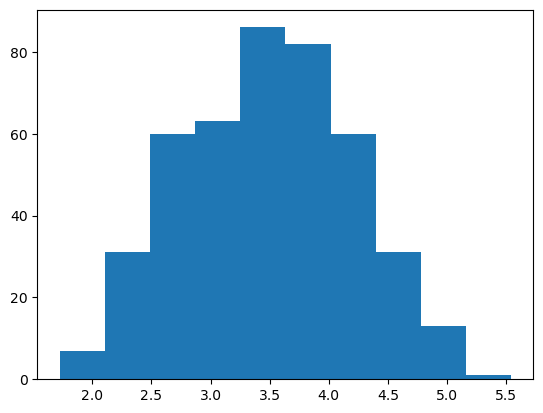

In [43]:
plt.hist(Akins_all_raw['Av_qso_med'])

In [44]:
Akins_all_raw.colnames

['id',
 'ra',
 'dec',
 'in_cw_miri',
 'in_primer_nircam',
 'in_primer_miri',
 'm814',
 'm115',
 'm150',
 'm277',
 'm444',
 'm770',
 'snr814',
 'snr115',
 'snr150',
 'snr277',
 'snr444',
 'snr770',
 'primer_m606',
 'primer_m814',
 'primer_m090',
 'primer_m115',
 'primer_m150',
 'primer_m200',
 'primer_m277',
 'primer_m356',
 'primer_m410',
 'primer_m444',
 'primer_m770',
 'primer_m1800',
 'primer_snr606',
 'primer_snr814',
 'primer_snr090',
 'primer_snr115',
 'primer_snr150',
 'primer_snr200',
 'primer_snr277',
 'primer_snr356',
 'primer_snr410',
 'primer_snr444',
 'primer_snr770',
 'primer_snr1800',
 'z_qso_med',
 'z_qso_u68',
 'z_qso_l68',
 'logLbol_med',
 'logLbol_u68',
 'logLbol_l68',
 'Av_qso_med',
 'Av_qso_u68',
 'Av_qso_l68',
 'chi2_qso',
 'z_gal_med',
 'z_gal_u68',
 'z_gal_l68',
 'logMstar_med',
 'logMstar_u68',
 'logMstar_l68',
 'SFR_100_med',
 'SFR_100_u68',
 'SFR_100_l68',
 'Av_gal_med',
 'Av_gal_u68',
 'Av_gal_l68',
 'chi2_gal',
 'chi2_bd',
 'C444',
 'Reff444_med',
 'Reff444

In [45]:
Akins_all_raw['Av_gal_med'].mean(), Akins_all_raw['Av_gal_med'].std()

(np.float64(3.136861671533203), np.float64(0.851546156604186))

#### 展示数据

<SecondaryAxis: xlabel='Observed $\\lambda$ [$\\mu m$]'>

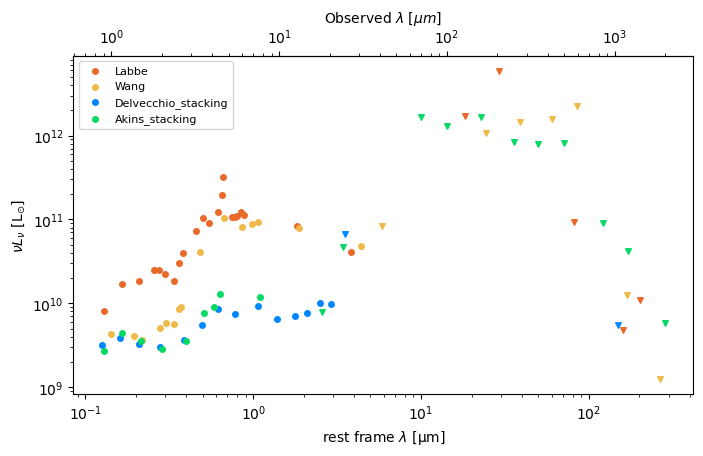

In [46]:

fig, ax = plt.subplots(figsize=(8, 6))


for label, SED_table, color in [
    ('Labbe', Labbe_photo, "#e96929"),
    ('Wang', Wang_photo, "#efba49"),
    ('Delvecchio_stacking', Delvecchio_stacking_photo, "#0087ff"),
    ('Akins_stacking', Akins_stacking_photo, "#06d965"), 
    # ('Delvecchio_and_Akins_stacking', Delvecchio_and_Akins_stacking_photo, "#d300c9"),
]:
    for detection_type in [True, False]:
        mask = SED_table['detection'] == detection_type
        ax.scatter(x='wavelength_rest', y='nu_L_nu', data=SED_table[mask], 
                   s=4**2, 
                   marker={True: 'o', False: 'v'}[detection_type], 
                   label=label if detection_type else None,  # 只在 detection_type 为 True 时添加 label，避免重复
                   color=color
                   )

ax.set_xlabel(fr'rest frame $\lambda$ [{ax.get_xlabel()}]') 
ax.set_ylabel(fr'$\nu L_\nu$ [{ax.get_ylabel()}]') 
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_aspect(.5)
ax.legend(fontsize=8)

add_wavelength_obs_xaxis(ax, z=6,)  #* 各个 SED 的红移不同，这里取个大概 z=6

## 准备 Fiducial model，定义函数

In [47]:
# create_model_with_basic 在 A_V_Model 的基础上，设定一些在整个 notebook 中都相同的参数。
create_model_with_basic = partial(A_V_Model, 
            T_sub=1500 * u.K,
            tau_ph=0,   # 默认 feedback: no
            config={'T_floor': 30 * u.K,},  # CMB 温度限制，why？
)

In [48]:
_opacity = SMC_opacity
# _opacity = Orion_opacity

_observed_SED = get_SED_detection(Labbe_photo) 
# _observed_SED=Labbe_SED_selected_MIRI_reduced,  #TEMP 处理 MIRI 的加和


# create_model_with_fiducial 设定一组 fiducial 参数，作为整个 notebook 中的默认选项。
# 目的是快速创建一个 model（只需要输入 A_V=xxx)。但不应当用作一般的 model_factory
create_model_with_fiducial = partial(create_model_with_basic, 
            n_0 = 1e3 * u.cm**-3,
            gamma = 0.5,
            opacity=_opacity,
            observed_SED=_observed_SED,
)

In [49]:
# # 临时尝试 迭代 解决 MIRI 问题！
# #TEMP

# from functools import lru_cache
# from astropy.units import Quantity

# def model_obs_diff(model: A_V_Model, observed_data: SED) -> tuple[int, float]:
#     # 分别取 log 再 diff。因为 L 随 A_V 接近指数变化，取 log 能让 brentq 的收敛性好不少
#     # diff = model.calc_nu_L_nu(observed_data.nu) - observed_data.nu_L_nu
#     diff = np.log10(model.calc_nu_L_nu(observed_data.nu).to_value(u.Lsun)) - np.log10(observed_data.nu_L_nu.to_value(u.Lsun))
#     index = np.argmax(diff)
#     return index, diff[index]
    
# def test_diff(*, n_0: Quantity, gamma: float, A_V: float, SED_limit: SED, SED_ext:SED):
#     np.seterr(over='ignore', divide='ignore')  # 忽略 overflow 和 divide by zero 的警告
#     # original_SED = Labbe_SED  # 是没有被截断的原始 SED，包括了 Herschel 和 ALMA 的数据
#     # original_SED = Labbe_SED_MIRI_remain  # 是没有被截断的原始 SED，包括了 Herschel 和 ALMA 的数据  #TEMP
#     model = create_model_with_fiducial(
#         n_0=n_0,
#         gamma=gamma,
#         A_V=A_V,
#         observed_SED=SED_ext,
#         # opacity=Orion_opacity,  #TEMP
#     )
    
#     return model_obs_diff(model=model, observed_data=SED_limit)

# #TODO 改名
# def calc_A_V_max(*, gamma: float, n_0: Quantity, SED_limit: SED, SED_ext: SED) -> optimize.RootResults:
#     np.seterr(over='ignore', divide='ignore')  # 忽略 overflow 和 divide by zero 的警告
    
#     # @lru_cache
#     def calc_index_diff(A_V: float):
#         return test_diff(n_0=n_0, gamma=gamma, A_V=A_V, SED_limit=SED_limit, SED_ext=SED_ext)

#     def calc_diff(A_V: float):
#         return calc_index_diff(A_V)[1]
    
#     xmin, xmax = [1e-3, 6]
    
#     success = False
#     while not success:
#         try:
#             res = optimize.root_scalar(
#                 calc_diff, 
#                 bracket=[xmin, xmax],  # 不取到 0，否则 log 的 diff 会给出 -np.inf，虽然 brentq 仍能处理，但预测能力下降，速度稍慢
#                 method='brentq', 
#                 xtol=1e-6,
#                 rtol=1e-3,  # 不用特别精确
#             )
#             success = True
#         except ValueError as e:
#             print(f"Error: {e}. n_0 = {n_0}, gamma = {gamma}, A_V in {[xmin, xmax]}")
#             while calc_diff(xmin) > 0:
#                 xmin /= 10
#             while calc_diff(xmax) < 0:
#                 xmax *= 2
#     return res, *calc_index_diff(A_V=res.root) #, calc_index_diff.cache_info()

## 出图

### 共用参数

In [50]:
dust_to_gas_mass_ratio_Solar = 1e-2
dust_to_gas_mass_ratio = dust_to_gas_mass_ratio_Solar * 0.1 # 取 0.1 Solar metallicity

In [51]:
paras_list_Labbe = [
    (0.5, 1e3 * u.cm**-3),
    (0.5, 10 * u.cm**-3),
    (0, 10 * u.cm**-3),
    (2, 1e4 * u.cm**-3),
    # (2, 1e3 * u.cm**-3),
    # (0, 2 * u.cm**-3),
    # (0, 1 * u.cm**-3),
    # (0.5, 100 * u.cm**-3),
]

In [52]:
paras_list_Wang = [
    (0.5, 1e3 * u.cm**-3),
    (0.25, 10 * u.cm**-3),
    (0, 10 * u.cm**-3),
    # (2, 1e4 * u.cm**-3),
    (0., 1e5 * u.cm**-3),
]

### 图 1：Opacity Laws

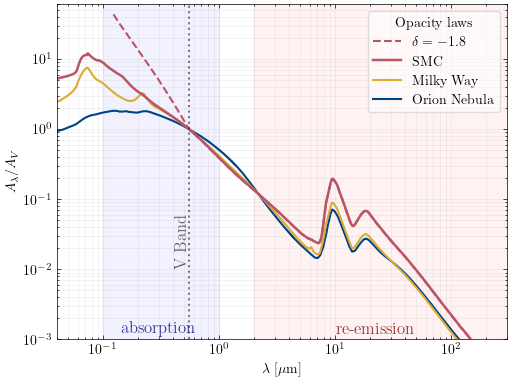

In [728]:
%matplotlib widget
#TEMP 改 style

import scienceplots
plt.rcdefaults()
plt.style.use(['science', 'high-contrast',])
plt.rcParams['lines.linewidth'] = 1.5

fig, ax = plt.subplots(figsize=np.array([4,3])*1.45, )
    
for opacity_name, opacity in opacity_dict.items():
    _props = dict()
    if opacity_name == 'super SMC':  # 对于 super SMC 特殊处理
        _props['linestyle'] = '--'
        _props['color'] = _line.get_color()  # 使用上一条线的颜色

    _line, = ax.loglog(opacity.wavelength, opacity.sigma_H_ext / opacity.sigma_H_ext_V, label=opacity_display_names[opacity_name], **_props)
    
    if opacity_name == 'SMC':  # SMC 线悄悄加粗一些，因为这是 fiducial case
        _line.set_linewidth(_line.get_linewidth() * 1.2) 
    
# 标记 V band
ax.axvline(5470 * u.AA, linestyle=':', color='k', alpha=.5)  
ax.text(5470 * u.AA, 1e-2, 'V Band', ha='right', va='bottom', rotation=90, fontsize=12, alpha=.6)  # V band 竖线附近的文字
# ax.scatter(5470 * u.AA, 1, marker='.', color='k', s=100, label='V Band', zorder=100)

# 标记 absorption 和 re-emission 的范围
ax.axvspan(1e-1 * u.um, 1e0 * u.um, color='blue', alpha=0.05)
ax.axvspan(2 * u.um, 3e2 * u.um, color='red', alpha=0.05)

ax.text(3e-1 * u.um, 1.1e-3, 'absorption', ha='center', va='bottom', fontsize=12, alpha=1, color='#303095', zorder=100)
ax.text(2.2e1 * u.um, 1.1e-3, 're-emission', ha='center', va='bottom', fontsize=12, alpha=1, color='#953030', zorder=100)



# 右边的 y 轴显示 sigma_H_ext
if False:
    def _A_rel_to_sigma_H(A_rel: float) -> float:
        return A_rel * Orion_opacity.sigma_H_ext_V.cgs.value
    def _sigma_H_to_A_rel(sigma_H: float) -> float:
        return sigma_H / Orion_opacity.sigma_H_ext_V.cgs.value
    yaxis_2 = ax.secondary_yaxis('right', functions=(_A_rel_to_sigma_H, _sigma_H_to_A_rel))
    yaxis_2.set_ylabel(r"$\sigma_\nu^{\rm ext}$ [${\rm cm^2}$]")

ax.grid(which='both', lw=.5, alpha=0.2)

ax.set_xlim(*[4e-2, 3e2] * u.um)
ax.set_ylim(1e-3, 60)

set_xylabel_with_unit(ax, xlabel=r'$\lambda$', ylabel=r'$A_\lambda/A_V$')
ax.legend(handles=ax.get_legend_handles_labels()[0][::-1], title='Opacity laws', framealpha=.6, frameon=True)

ax.get_legend()

# fig.savefig('figures/opacity_laws/opacity_laws_4.pdf', bbox_inches='tight')
# fig

In [277]:
ax.legend(handles=ax.get_legend_handles_labels()[0][::-1])

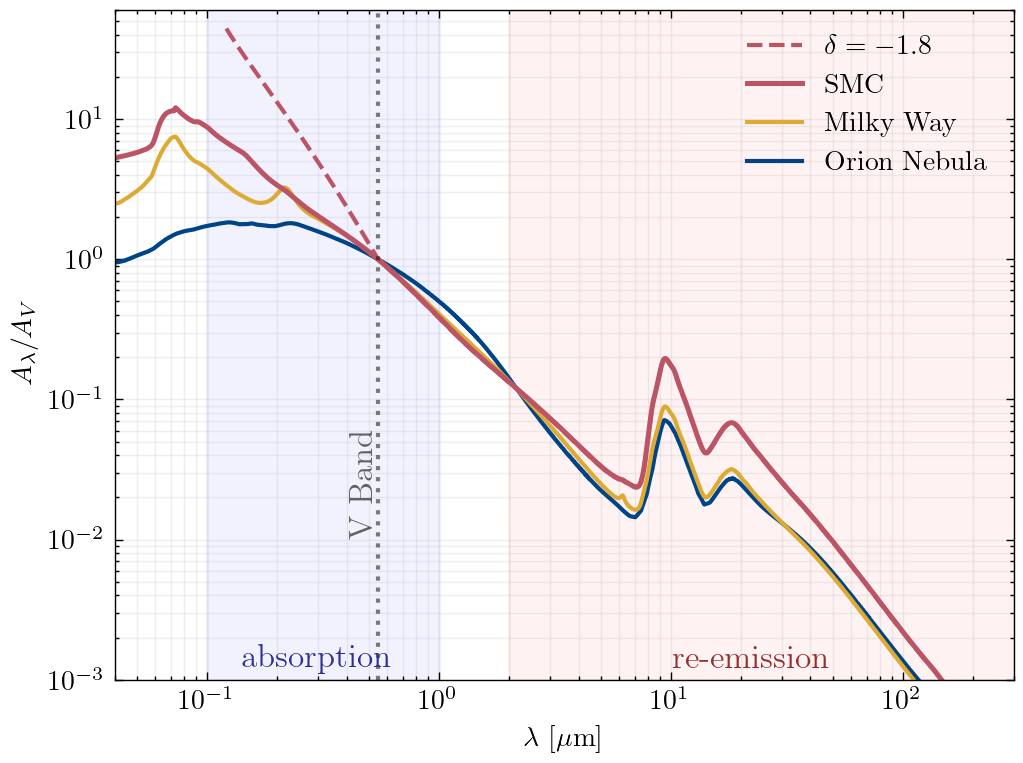

In [278]:
fig

In [254]:
plt.rcParams['grid.color'] = "#d5d5d5"

'#b0b0b0'

In [236]:
fig.get_size_inches()

array([6. , 4.5])

In [66]:
plt.rcParams['figure.constrained_layout.use']

False

In [70]:
plt.rcdefaults()

In [90]:
{op_name: opacity.interp_ext((1215*u.AA).to(u.Hz, equivalencies=u.spectral()))/opacity.sigma_H_ext_V for op_name, opacity in opacity_dict.items() 
#  if op_name != 'super SMC'
 }

{'Orion': <Quantity 1.82856252>,
 'MW': <Quantity 3.37729589>,
 'SMC': <Quantity 6.81453348>,
 'super SMC': <Quantity 44.09326289>}

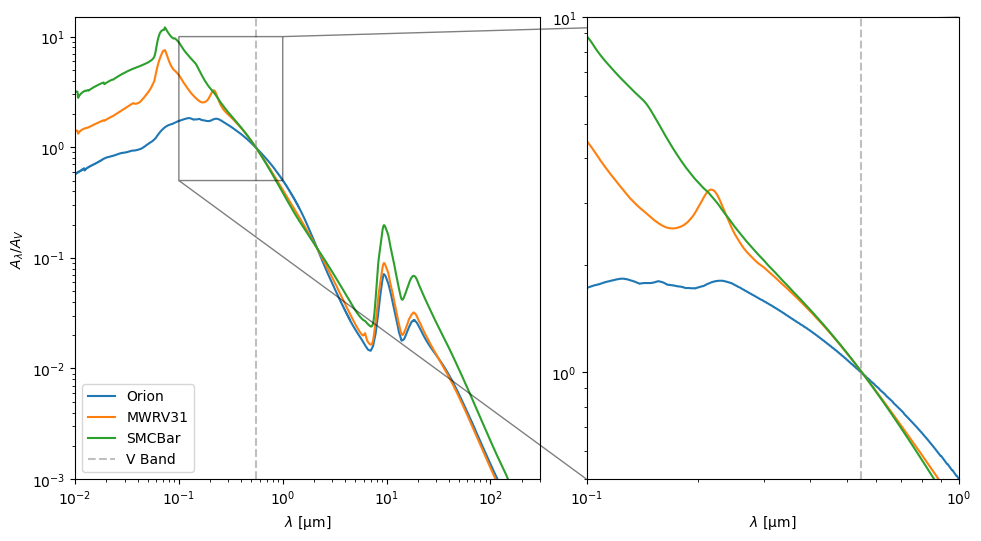

In [ ]:
# # 旧的图：zoom-in
# # 只挑选 3 个模型：Orion, ISM, SMC
# from dust_extinction.grain_models import WD01

# fig, ax = plt.subplots(figsize=[6,6], dpi=100)

# model_names = WD01().possnames.keys()
# ax_inset = ax.inset_axes([1.1, 0, .8, 1], xlim=[1e-1, 1e0] * u.micron, ylim=[5e-1, 1e1])

# # generate the curves and plot them
# lam = np.geomspace(1e-2, 1e4, num=1000) * u.micron

# def _plot(ax: plt.Axes):
#     ax.loglog(Orion_opacity.wavelength, Orion_opacity.sigma_H_ext / Orion_opacity.sigma_H_ext_V, label='Orion')
    
#     for model_name in ['MWRV31', 'SMCBar']:
#         # define the extinction model
#         ext_model = WD01(model_name)
#         ax.loglog(lam, ext_model(lam), label=model_name)
        
#     ax.axvline(5470 * u.AA, linestyle='--', color='gray', label='V Band', alpha=0.5)  
     
# _plot(ax)
# _plot(ax_inset)    


# ax.indicate_inset_zoom(ax_inset, edgecolor='k', )

# ax_inset.set_xticklabels([], minor=True)

# ax.set_xlim(*[1e-2, 3e2]*u.micron)
# ax.set_ylim(1e-3, 15)

# set_xylabel_with_unit(ax, xlabel=r'$\lambda$', ylabel=r'$A_\lambda/A_V$')
# set_xylabel_with_unit(ax_inset, xlabel=r'$\lambda$')
# ax.legend(loc='lower left')

### 图 2：Typical SEDs

#### Labbe's source

In [296]:
%matplotlib inline

In [71]:
import scienceplots
plt.style.use(['science',])

In [299]:
plt.rcParamsDefault['lines.linewidth']

1.5

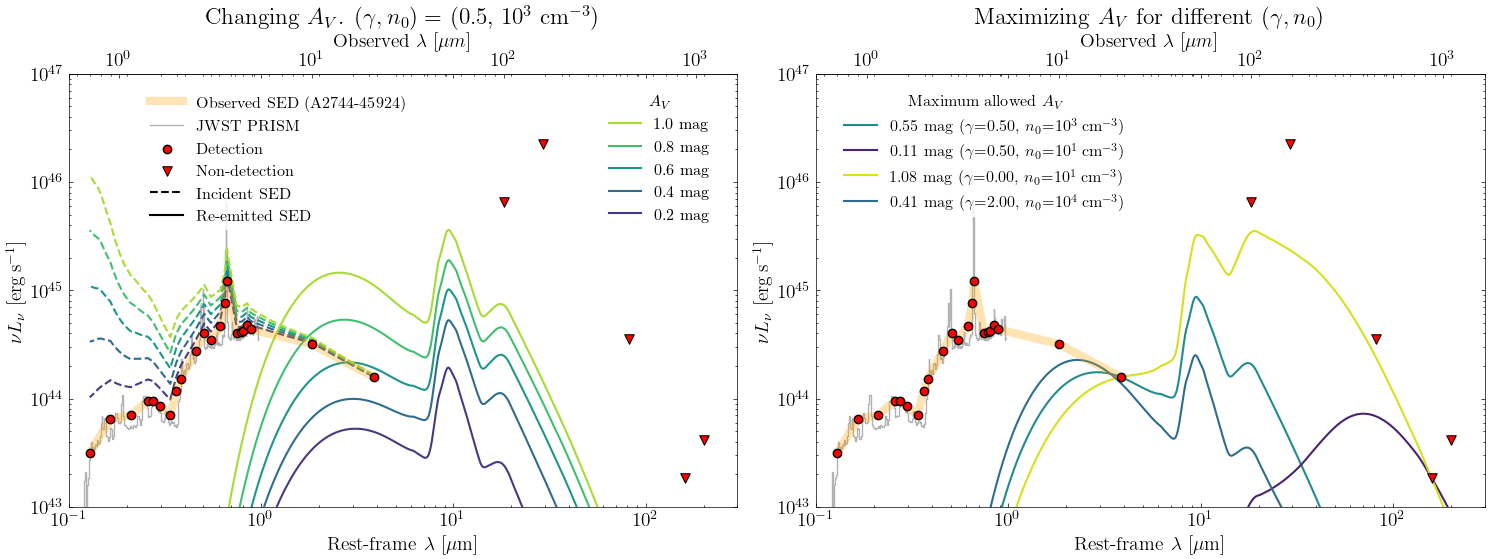

In [690]:
plot_2 = TypicalSEDPlot(
    model_factory=create_model_with_basic, 
    # model_factory=partial(create_model_with_basic, f_scat=.01), #TEMP 测试 f_scat
    opacity=SMC_opacity, 
    SED_table=Labbe_photo, 
    spec_table=Labbe_spec,
)

fig, axs = plot_2.plot_figure(paras_list=paras_list_Labbe, 
                              # A_V_high=3, #TEMP 展示 A_V = 3 有多「糟糕」
                              )

fig.set_size_inches(np.array([8*2, 6]) * 0.93)  # 略微调整图像大小，让 label 大小合适

# fig.savefig('figures/typical_SEDs/typical_SEDs_12.pdf', bbox_inches='tight')
# fig.savefig('figures/temp/typical_SEDs/typical_SEDs_ignore_UV.pdf', bbox_inches='tight')

In [62]:
#TEMP 尝试某种平均温度

model = create_model_with_fiducial(A_V=0.55)
r_array = model.get_r_array()
(trapz_log(model.T_dust_profile(r_array)**4 * model.n_profile(r_array) * 4 * np.pi * r_array**2, r_array) / \
    trapz_log(model.n_profile(r_array) * 4 * np.pi * r_array**2, r_array))**(1/4)  # 计算平均温度

<Quantity 320.81936158 K>

#### Wang's source

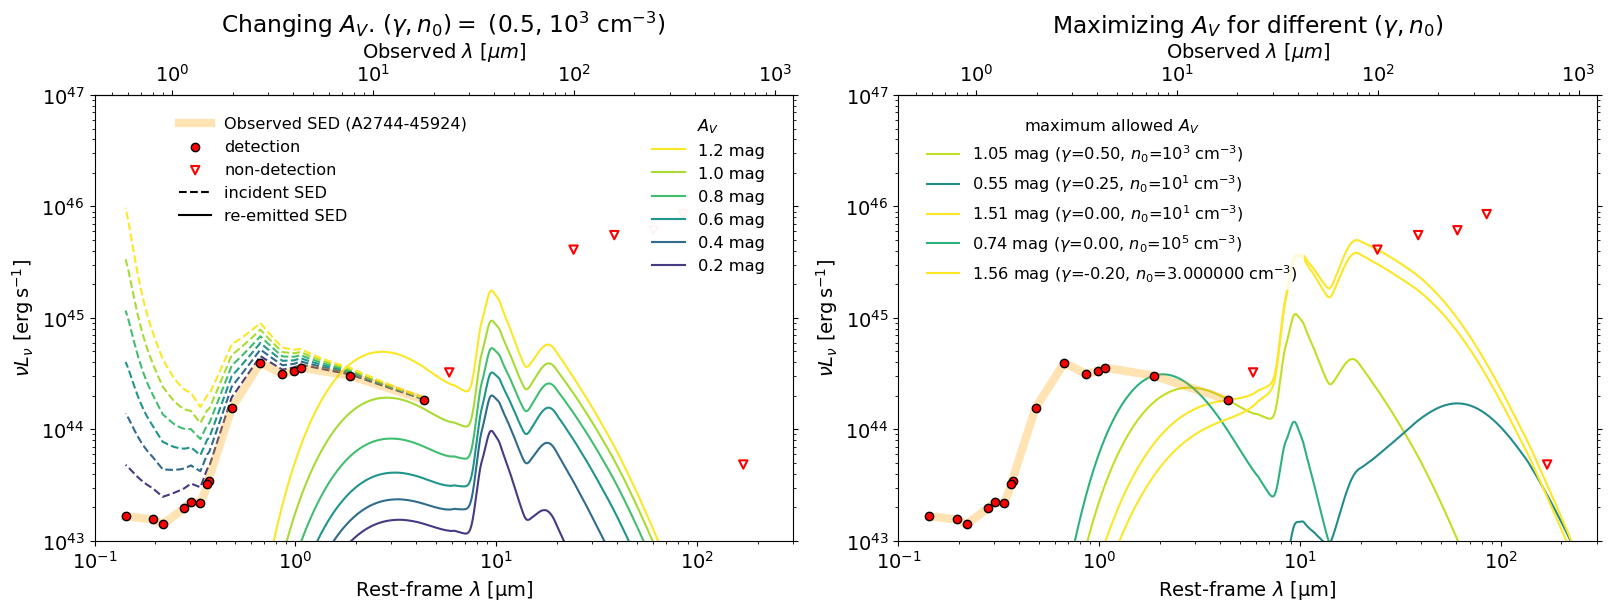

In [167]:
plot_2 = TypicalSEDPlot(
    model_factory=create_model_with_basic,
    opacity=SMC_opacity, 
    SED_table=Wang_photo, 
)

fig, axs = plot_2.plot_figure(A_V_list=np.arange(.2, 1.2+1e-8, .2), paras_list=paras_list_Wang + [(-.2, 3e0 * u.cm**-3),]) #TEMP
    
#TEMP 展示 A_V = 3 有多「糟糕」
# plot_2.plot_panel_A(ax=axs[0], A_V_list=np.append(np.arange(0.2, 1 + 1e-8, 0.2), 3), gamma=0.5, n_0=1e3 * u.cm**-3)


# fig.savefig('figures/typical_SEDs/typical_SEDs_11.pdf', bbox_inches='tight')
# fig.savefig('figures/temp/typical_SEDs/typical_SEDs_ignore_UV.pdf', bbox_inches='tight')

### 图 3：Parameter Space

In [53]:
# 暂时这么定义，用于复用
def load_paras_survey_data(filename: str) -> dict[str, np.ndarray | Quantity | float]:
    npz_file = np.load(filename)
    data_dict = dict(npz_file)
    
    # 恢复单位
    data_dict['n_0_array'] *= u.cm**-3  
    data_dict['M_dust'] *= u.Msun
    
    return data_dict

#### 计算

In [55]:
# 配置参数
#CHANGEME 

# ---------------------------- 把所有需要改动的参数放在开头，统一配置 --------------------------- #
_opacity = SMC_opacity
# _opacity = Orion_opacity

_SED_table = Labbe_photo
# _SED_table = Labbe_photo_modified['1e-1']
# _SED_table = Wang_photo
# _SED_table = Delvecchio_stacking_photo
# _SED_table = Akins_stacking_photo
# _SED_table = Delvecchio_and_Akins_stacking_photo

ignore_UV = False  
# ignore_UV = True  #CHANGEME 用于 appendix，忽略 UV 贡献

f_scat = 0
# f_scat = 1e-2  #CHANGEME #TEMP 尝试 f_scat 的影响
# f_scat = 1e-1


if ignore_UV:  #* 如果忽略 UV 波段，则修改 _SED_table，只取波长比 Balmer Break 更长的数据
    _SED_table = _SED_table[_SED_table['wavelength_rest'] >= wavelength_Balmer_break]

# ---------------------------------------------------------------------------- #


# 配置局部使用的 _model_factory 和 _calc_A_V_max

# 这个 _model_factory 只缺 n_0, gamma 和 A_V 三个参数
_model_factory = partial(
    create_model_with_basic,
    opacity=_opacity,
    observed_SED=get_SED_detection(_SED_table),
    f_scat=f_scat, 
    config={'T_floor': 30 * u.K, 'r_out_limit': 1e4 * u.pc},  #* 在 paras survey 时，额外限定 'r_out_limit': 1e4 * u.pc，从而在 paras survey plot 中画出 r > 10 kpc 的区域。
    # config={'T_floor': 0 * u.K, 'r_out_limit': 1e4 * u.pc},  #TEMP 尝试取消 T_floor
)
_calc_A_V_max_for_paras = partial(
    calc_A_V_max_for_paras,
    model_factory=_model_factory,
    constraint_SED=SED.from_QTable(_SED_table),
)


In [321]:
# 创建网格
gamma_array = np.linspace(0, 2, 9*10)
# gamma_array = np.linspace(-5, 1, 9*3)
n_0_array = np.geomspace(1e0, 1e5, 11*10) * u.cm**-3

X, Y = np.meshgrid(gamma_array, n_0_array)

In [248]:
# 用 joblib 并行计算

# del A_V_max_result_arrays  # 先删除旧的变量，避免误用

# 返回一个 generator，从而可以在后台计算，在前台做一些其他事情。
# 如果需要中止计算，可以在某个别的单元中停止计算来触发 KeyboardInterrupt，或者直接重新运行本单元格
A_V_max_result_list = Parallel(return_as='generator')(
    delayed(_calc_A_V_max_for_paras)(gamma=gamma, n_0=n_0) for n_0, gamma in tqdm(list(product(n_0_array, gamma_array)))  # 外层循环 y 轴，内层循环 x 轴
)

#* 运行完后，记得提取结果

  0%|          | 0/9900 [00:00<?, ?it/s]

In [249]:

# 从 generator 转为 list
A_V_max_result_list: list[A_V_max_Result] = list(A_V_max_result_list)

# 从 A_V_max_result_list 中的每一项中，自动提取 dataclass 的所有 field，组成列表。
# 把 list of A_V_max_Result 转换为 dict of list
A_V_max_result_dict = extract_dataclass_fields_to_dict(A_V_max_result_list, A_V_max_Result)

# 提取所需的结果，reshape 成 和 X, Y 相同的二维形状

if not all(res.converged for res in A_V_max_result_dict['root_result']):
    print("有的 root 没有收敛！")

A_V_max_result_arrays: dict[str, np.ndarray | Quantity | float] = {
    'gamma_array'   : gamma_array,
    'n_0_array'     : n_0_array,
    'A_V_max'       : np.reshape(A_V_max_result_dict['A_V_max'], X.shape), 
    'constrained_by': np.reshape(A_V_max_result_dict['constrained_by'], X.shape),
    'crit_index'    : np.reshape(A_V_max_result_dict['crit_index'], X.shape),
    'M_dust'        : Quantity(A_V_max_result_dict['M_gas']).reshape(X.shape) * dust_to_gas_mass_ratio, 
    'dust_to_gas_mass_ratio': dust_to_gas_mass_ratio, 
    'f_scat'        : f_scat, 
}

In [158]:
print(f"max iterations: {max([res.iterations for res in A_V_max_result_dict['root_result']])}")

max iterations: 45


In [ ]:
# # 保存数据

# _dump_filename = 'data/dump/paras_survey/test_2.npz'

# np.savez(_dump_filename, **A_V_max_result_arrays)

In [ ]:
# _dump_filename = 'data/dump/paras_survey/test_2.npz'

# _data_from_file = load_paras_survey_data(_dump_filename);

[Parallel(n_jobs=10)]: Done 6030 tasks      | elapsed:  6.6min


#### Labbe's SED + SMC

In [ ]:
# # 保存数据

# _dump_filename = 'data/dump/paras_survey/Labbe+SMC_res=90*110.npz'
# # _dump_filename = 'data/dump/paras_survey/Labbe+SMC_res=100_100.npz'

# np.savez_compressed(_dump_filename, **A_V_max_result_arrays)

In [82]:
# 读取数据
_dump_filename = 'data/dump/paras_survey/Labbe+SMC_res=90*110.npz'
# _dump_filename = 'data/dump/paras_survey/Labbe+SMC_res=100_100.npz'

_data_from_file = load_paras_survey_data(_dump_filename);

In [70]:
%matplotlib widget

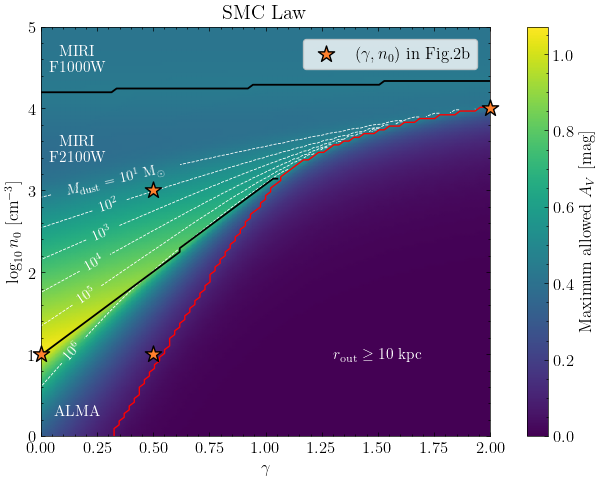

In [ ]:
# Labbe's SED + SMC

from shapely import LineString

# # 尝试加粗体
# plt.rcParams.update({
# "text.latex.preamble": (
#         r"\usepackage{amsmath}"
#         r"\usepackage{amssymb}"
#         # 使用 Times 字体，并确保粗体可用
#         r"\usepackage{mathptmx}"
#         # T1 字体编码，用于正确显示特殊字符
#         r"\usepackage[T1]{fontenc}"
#         # 加载 bm 宏包，用于加粗数学符号（非常有用！）
#         r"\usepackage{bm}"
#         # 全局开启粗体系列
#         r"\bfseries"
#     )
# })

_data_dict = _data_from_file
# _data_dict = A_V_max_result_arrays

plot_3a = ParasSurveyPlot(
    gamma_array=_data_dict["gamma_array"],
    n_0_array=_data_dict["n_0_array"],
    clabel_pos_line=LineString([[0.05, 0], [0.5, 5]]),
)

fig, ax = plot_3a.plot_figure_from_dict(
    data_dict=_data_dict,
    paras_list=paras_list_Labbe,
    fig_ref='Fig.2b'
)

# 添加文字，标记各个区域的限制波长（instrument）
_text_props = dict(ha='center', va='center', color='w', fontsize=11, )
ax.text(.16, 0.3, "ALMA", **_text_props)
ax.text(.16, 3.5, "MIRI\nF2100W", **_text_props)
ax.text(.16, 4.6, "MIRI\nF1000W", **_text_props)
ax.text(1.5, 1, r"$r_{\rm out} \geq 10~{\rm kpc}$", **_text_props)  #TEMP


ax.set_title("SMC Law")

# #TEMP 尝试给「r_out ≥ 10 kpc」的禁区加上 hatch
# #* 但实际上不该加？因为这里并不是完全禁区，只是 A_V 限制到很小
# ax.contourf(
#     X, np.log10(Y.value), _data_from_file['constrained_by'] == Constraint.NH_MAX,
#     levels=[0.5, 1.5],       # 只填充值为 1 (True) 的区域
#     colors='none',           # 无颜色填充
#     hatches=['xx'],          # 设置影线样式
#     extend='lower'
# )

# fig.savefig('figures/paras_survey/Labbe+SMC_v3.pdf', bbox_inches='tight')
# fig.savefig('figures/paras_survey/Labbe+SMC_res=100*100_v1.pdf', bbox_inches='tight')

#### Labbe's SED + Orion

In [ ]:
# # 保存数据

# _dump_filename = 'data/dump/paras_survey/Labbe+Orion.npz'

# np.savez_compressed(_dump_filename, **A_V_max_result_arrays)

In [87]:
# 读取数据
_dump_filename = 'data/dump/paras_survey/Labbe+Orion.npz'

_data_from_file = load_paras_survey_data(_dump_filename);

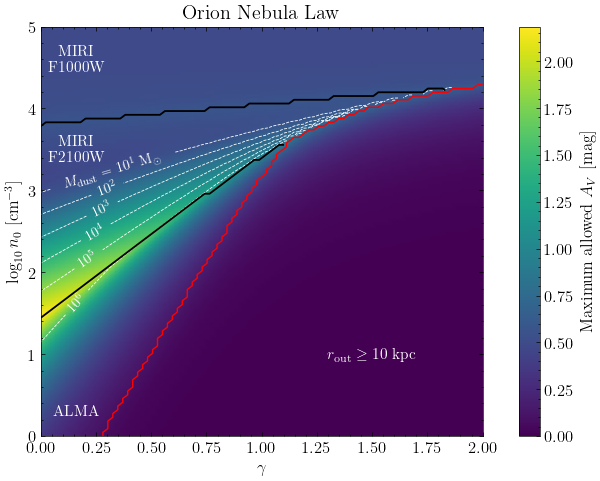

In [ ]:
# Labbe's SED + Orion

_data_dict = _data_from_file
# _data_dict = A_V_max_result_arrays

plot_3b = ParasSurveyPlot(
    gamma_array=_data_dict["gamma_array"],
    n_0_array=_data_dict["n_0_array"],
    clabel_pos_line=LineString([[0, 0], [0.5, 5]]),
)

fig, ax = plot_3b.plot_figure_from_dict(
    data_dict=_data_dict,
)

# 添加文字，标记各个区域的限制波长（instrument）
_text_props = dict(ha='center', va='center', color='w', fontsize=11)
ax.text(.16, 0.3, "ALMA", **_text_props)
ax.text(.16, 3.5, "MIRI\nF2100W", **_text_props)
ax.text(.16, 4.6, "MIRI\nF1000W", **_text_props)
ax.text(1.5, 1, r"$r_{\rm out} \geq 10~{\rm kpc}$", **_text_props)  #TEMP

ax.set_title("Orion Nebula Law")

# fig.savefig('figures/paras_survey/Labbe+Orion_v3.pdf', bbox_inches='tight')

#### Labbe's SED + SMC + ignore_UV

In [ ]:
# # 保存数据

# _dump_filename = 'data/dump/paras_survey/Labbe+SMC+ignore_UV.npz'

# np.savez_compressed(_dump_filename, **A_V_max_result_arrays)

In [90]:
# 读取数据
_dump_filename = 'data/dump/paras_survey/Labbe+SMC+ignore_UV.npz'

_data_from_file = load_paras_survey_data(_dump_filename);

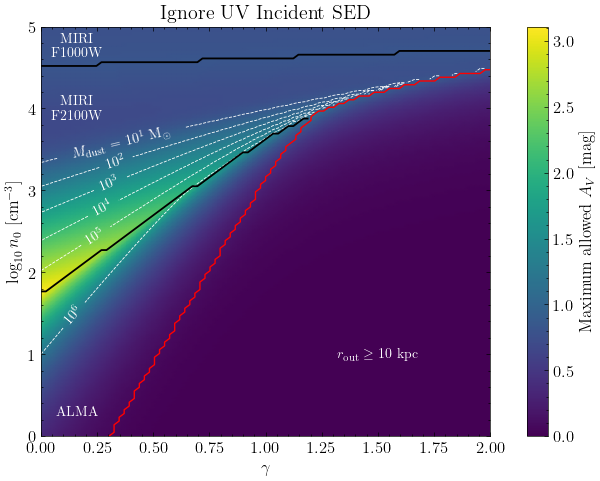

In [92]:
# Labbe's SED + SMC + ignore_UV

_data_dict = _data_from_file
# _data_dict = A_V_max_result_arrays

plot_appendix_1 = ParasSurveyPlot(
    gamma_array=_data_dict["gamma_array"],
    n_0_array=_data_dict["n_0_array"],
    clabel_pos_line=LineString([[0, 0], [0.5, 5]]),
)


fig, ax = plot_appendix_1.plot_figure_from_dict(
    data_dict=_data_dict,
)

# 添加文字，标记各个区域的限制波长（instrument）
_text_props = dict(ha='center', va='center', color='w', fontsize=10)
ax.text(.16, 0.3, "ALMA", **_text_props)
ax.text(.16, 4, "MIRI\nF2100W", **_text_props)
ax.text(.16, 4.76, "MIRI\nF1000W", **_text_props)
ax.text(1.5, 1, r"$r_{\rm out} \geq 10~{\rm kpc}$", **_text_props)  #TEMP

# ax.set_title("SMC Law")
ax.set_title("Ignore UV Incident SED")

# fig.savefig('figures/paras_survey/ignore_UV/Labbe+SMC+ignore_UV_v4.pdf', bbox_inches='tight')

#### Labbe's SED + SMC + f_scat

In [ ]:
# # # 保存数据

# # _dump_filename = 'data/dump/paras_survey/Labbe+SMC+f_scat=1e-2.npz'
# _dump_filename = 'data/dump/paras_survey/Labbe+SMC+f_scat=1e-1.npz'

# np.savez_compressed(_dump_filename, **A_V_max_result_arrays)

In [93]:
# 读取数据
_dump_filename = 'data/dump/paras_survey/Labbe+SMC+f_scat=1e-2.npz'
# _dump_filename = 'data/dump/paras_survey/Labbe+SMC+f_scat=1e-1.npz'

_data_from_file = load_paras_survey_data(_dump_filename);

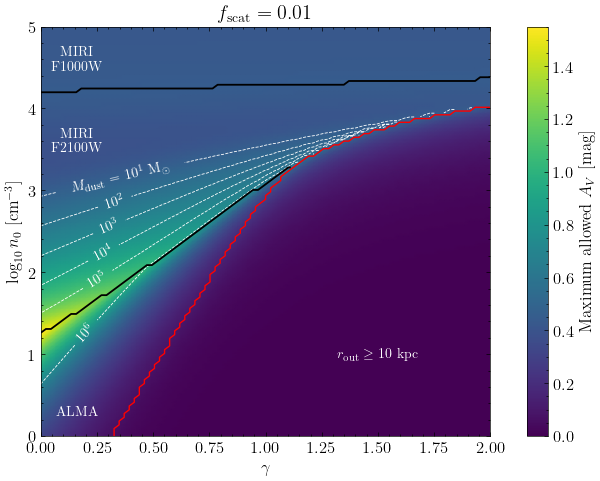

In [ ]:
# Labbe's SED + SMC + f_scat

_data_dict = _data_from_file
# _data_dict = A_V_max_result_arrays

plot_appendix_1 = ParasSurveyPlot(
    gamma_array=_data_dict["gamma_array"],
    n_0_array=_data_dict["n_0_array"],
    clabel_pos_line=LineString([[0.1, 0], [0.5, 5]]),
)


fig, ax = plot_appendix_1.plot_figure_from_dict(
    data_dict=_data_dict,
)

# 添加文字，标记各个区域的限制波长（instrument）
_text_props = dict(ha='center', va='center', color='w', fontsize=10)
ax.text(.16, 4.6, "MIRI\nF1000W", **_text_props)
ax.text(.16, 3.6, "MIRI\nF2100W", **_text_props)
ax.text(.16, 0.3, "ALMA", **_text_props)
ax.text(1.5, 1, r"$r_{\rm out} \geq 10~{\rm kpc}$", **_text_props)  #TEMP

ax.set_title(rf"$f_{{\rm scat}}={_data_dict.get('f_scat')}$")

# fig.savefig('figures/paras_survey/ignore_UV/Labbe+SMC+f_scat=1e-2_v3.pdf', bbox_inches='tight')

#### Labbe's SED + Orion + ignore_UV

In [ ]:
# # 保存数据

# _dump_filename = 'data/dump/paras_survey/Labbe+Orion+ignore_UV.npz'

# np.savez_compressed(_dump_filename, **A_V_max_result_arrays)

In [406]:
# 读取数据
_dump_filename = 'data/dump/paras_survey/Labbe+Orion+ignore_UV.npz'

_data_from_file = load_paras_survey_data(_dump_filename);

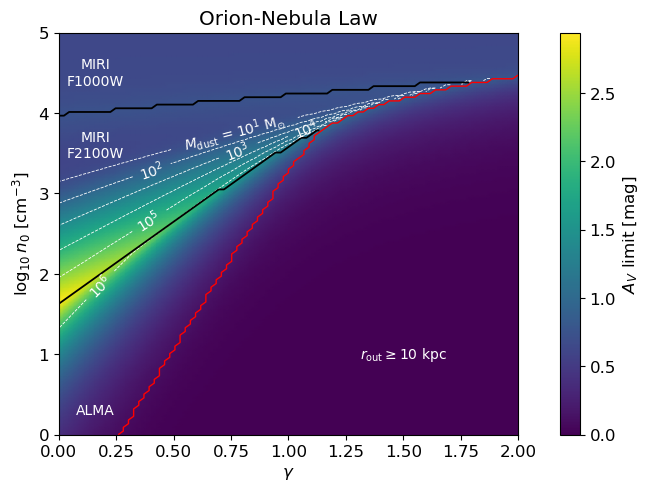

In [ ]:
# Labbe's SED + Orion + ignore_UV

_data_dict = _data_from_file
# _data_dict = A_V_max_result_arrays

plot_appendix_1 = ParasSurveyPlot(gamma_array=_data_dict['gamma_array'], n_0_array=_data_dict['n_0_array'])


fig, ax = plot_appendix_1.plot_figure_from_dict(
    data_dict=_data_dict,
)

# 添加文字，标记各个区域的限制波长（instrument）
_text_props = dict(ha='center', va='center', color='w', fontsize=10)
ax.text(.16, 4.5, "MIRI\nF1000W", **_text_props)
ax.text(.16, 3.6, "MIRI\nF2100W", **_text_props)
ax.text(.16, 0.3, "ALMA", **_text_props)
ax.text(1.5, 1, r"$r_{\rm out} \geq 10~{\rm kpc}$", **_text_props)  #TEMP

ax.set_title("Orion-Nebula Law")

# fig.savefig('figures/paras_survey/ignore_UV/Labbe+Orion+ignore_UV_v2.pdf', bbox_inches='tight')

#### Labbe's SED + Orion + f_scat

In [ ]:
# # 保存数据

# # _dump_filename = 'data/dump/paras_survey/Labbe+Orion+f_scat=1e-2.npz'
# _dump_filename = 'data/dump/paras_survey/Labbe+Orion+f_scat=1e-1.npz'

# np.savez_compressed(_dump_filename, **A_V_max_result_arrays)

In [251]:
# 读取数据
# _dump_filename = 'data/dump/paras_survey/Labbe+Orion+f_scat=1e-2.npz'
_dump_filename = 'data/dump/paras_survey/Labbe+Orion+f_scat=1e-1.npz'

_data_from_file = load_paras_survey_data(_dump_filename);

Text(0.5, 1.0, 'Orion-Nebula Law ($f_{\\rm scat}=0.1$)')

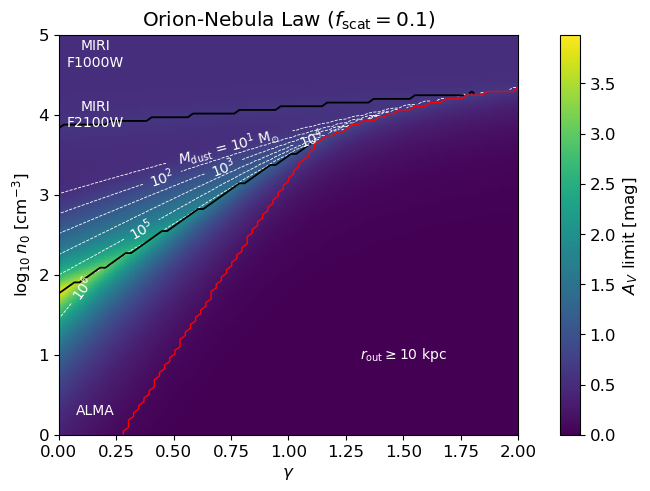

In [252]:
# Labbe's SED + Orion + f_scat

_data_dict = _data_from_file
# _data_dict = A_V_max_result_arrays

plot_appendix_1 = ParasSurveyPlot(gamma_array=_data_dict['gamma_array'], n_0_array=_data_dict['n_0_array'])


fig, ax = plot_appendix_1.plot_figure_from_dict(
    data_dict=_data_dict,
)

# 添加文字，标记各个区域的限制波长（instrument）
_text_props = dict(ha='center', va='center', color='w', fontsize=10)
ax.text(.16, 0.3, "ALMA", **_text_props)
ax.text(.16, 4, "MIRI\nF2100W", **_text_props)
ax.text(.16, 4.76, "MIRI\nF1000W", **_text_props)
ax.text(1.5, 1, r"$r_{\rm out} \geq 10~{\rm kpc}$", **_text_props)  #TEMP

ax.set_title(rf"Orion-Nebula Law ($f_{{\rm scat}}={_data_dict.get('f_scat')}$)")

# fig.savefig('figures/paras_survey/ignore_UV/Labbe+Orion+f_sact=1e-2.pdf', bbox_inches='tight')

#### Wang's SED + SMC

In [ ]:
# # 保存数据

# _dump_filename = 'data/dump/paras_survey/Wang+SMC.npz'

# np.savez_compressed(_dump_filename, **A_V_max_result_arrays)

In [131]:
# 读取数据
_dump_filename = 'data/dump/paras_survey/Wang+SMC.npz'

_data_from_file = load_paras_survey_data(_dump_filename);

Text(0.5, 1.0, 'SMC Law')

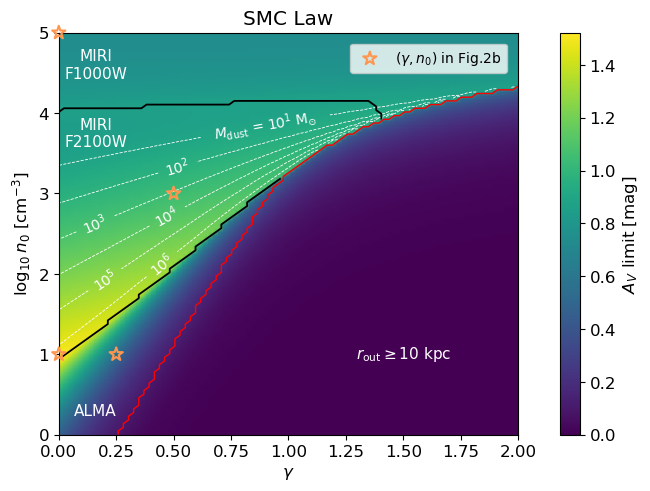

In [147]:
# Wang's SED + SMC

_data_dict = _data_from_file
# _data_dict = A_V_max_result_arrays

plot_3a = ParasSurveyPlot(gamma_array=_data_dict['gamma_array'], n_0_array=_data_dict['n_0_array'])

fig, ax = plot_3a.plot_figure_from_dict(
    data_dict=_data_dict,
    paras_list=paras_list_Wang,
    fig_ref='Fig.2b'
)

# 添加文字，标记各个区域的限制波长（instrument）
_text_props = dict(ha='center', va='center', color='w', fontsize=11)
ax.text(.16, 4.6, "MIRI\nF1000W", **_text_props)
ax.text(.16, 3.75, "MIRI\nF2100W", **_text_props)
ax.text(.16, 0.3, "ALMA", **_text_props)
ax.text(1.5, 1, r"$r_{\rm out} \geq 10~{\rm kpc}$", **_text_props)  #TEMP

ax.set_title("SMC Law")

# fig.savefig('figures/paras_survey/Wang+SMC_v1.pdf', bbox_inches='tight')
# fig.savefig('figures/paras_survey/Wang+SMC_res=100*100_v1.pdf', bbox_inches='tight')

#### Wang's SED + Orion

In [ ]:
# # 保存数据

# _dump_filename = 'data/dump/paras_survey/Wang+Orion.npz'

# np.savez_compressed(_dump_filename, **A_V_max_result_arrays)

In [148]:
# 读取数据
_dump_filename = 'data/dump/paras_survey/Wang+Orion.npz'

_data_from_file = load_paras_survey_data(_dump_filename);

Text(0.5, 1.0, 'Orion Law')

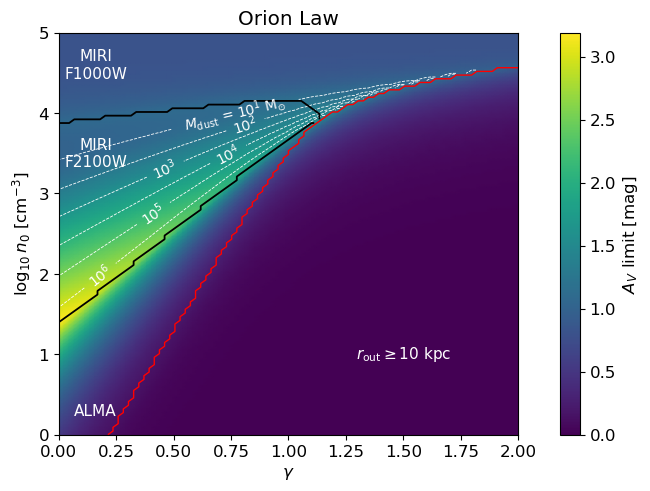

In [149]:
# Wang's SED + Orion

_data_dict = _data_from_file
# _data_dict = A_V_max_result_arrays

plot_3a = ParasSurveyPlot(gamma_array=_data_dict['gamma_array'], n_0_array=_data_dict['n_0_array'])

fig, ax = plot_3a.plot_figure_from_dict(
    data_dict=_data_dict,
    # paras_list=paras_list_Labbe,
    # fig_ref='Fig.2b'
)

# 添加文字，标记各个区域的限制波长（instrument）
_text_props = dict(ha='center', va='center', color='w', fontsize=11)
ax.text(.16, 4.6, "MIRI\nF1000W", **_text_props)
ax.text(.16, 3.5, "MIRI\nF2100W", **_text_props)
ax.text(.16, 0.3, "ALMA", **_text_props)
ax.text(1.5, 1, r"$r_{\rm out} \geq 10~{\rm kpc}$", **_text_props)  #TEMP

ax.set_title("Orion Law")

# fig.savefig('figures/paras_survey/Wang+Orion_v1.pdf', bbox_inches='tight')
# fig.savefig('figures/paras_survey/Wang+SMC_res=100*100_v1.pdf', bbox_inches='tight')

#### Wang's SED + SMC + ignore_UV

In [ ]:
# # 保存数据

# _dump_filename = 'data/dump/paras_survey/Wang+SMC+ignore_UV.npz'

# np.savez_compressed(_dump_filename, **A_V_max_result_arrays)

In [158]:
# 读取数据
_dump_filename = 'data/dump/paras_survey/Wang+SMC+ignore_UV.npz'

_data_from_file = load_paras_survey_data(_dump_filename);

Text(0.5, 1.0, 'SMC Law (Ignore UV Incident SED)')

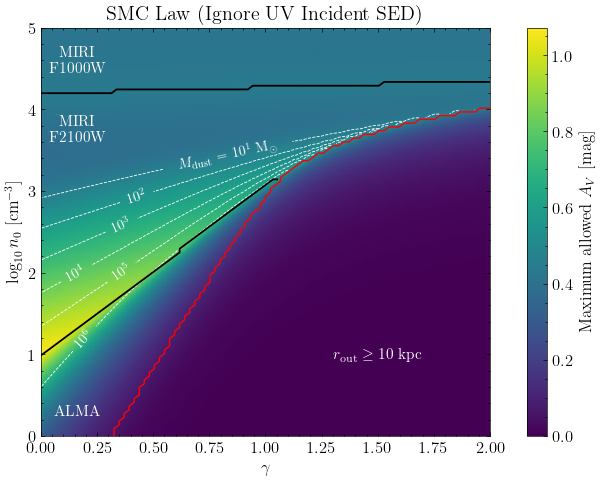

In [231]:
# Wang's SED + SMC + ignore_UV

_data_dict = _data_from_file
# _data_dict = A_V_max_result_arrays

plot_3a = ParasSurveyPlot(gamma_array=_data_dict['gamma_array'], n_0_array=_data_dict['n_0_array'])

fig, ax = plot_3a.plot_figure_from_dict(
    data_dict=_data_dict,
    # paras_list=paras_list_Wang,
    # fig_ref='Fig.2b'
)

# 添加文字，标记各个区域的限制波长（instrument）
_text_props = dict(ha='center', va='center', color='w', fontsize=11)
ax.text(.16, 4.6, "MIRI\nF1000W", **_text_props)
ax.text(.16, 3.75, "MIRI\nF2100W", **_text_props)
ax.text(.16, 0.3, "ALMA", **_text_props)
ax.text(1.5, 1, r"$r_{\rm out} \geq 10~{\rm kpc}$", **_text_props)  #TEMP

ax.set_title("SMC Law (Ignore UV Incident SED)")

# fig.savefig('figures/paras_survey/Wang+SMC_v1.pdf', bbox_inches='tight')
# fig.savefig('figures/paras_survey/Wang+SMC_res=100*100_v1.pdf', bbox_inches='tight')

#### 根据 Fig.3 给出具体数值

SMC  +Labbe+ignore_UV: A_V_max = 3.11, (@ gamma=0, n_0=55); for gamma>=1: A_V_max = 1.36, n_0=4674

Orion+Labbe+ignore_UV: A_V_max = 2.94, (@ gamma=0, n_0=45); for gamma>=1: A_V_max = 1.22, n_0=4206

In [68]:
A_V_max_array = _data_dict['A_V_max']

In [69]:
print(A_V_max_array.max())

max_index = A_V_max_array.argmax()
X.flat[max_index], Y.flat[max_index], A_V_max_array.flat[max_index], 

2.185321796878856


(np.float64(0.0),
 <Quantity 29.36905065 1 / cm3>,
 np.float64(2.185321796878856))

In [ ]:
print(A_V_max_array.max())

max_index = A_V_max_array.argmax()
X.flat[max_index], Y.flat[max_index], A_V_max_array.flat[max_index], 

3.1103640419317813


(np.float64(0.0),
 <Quantity 55.35020912 1 / cm3>,
 np.float64(3.1103640419317813))

In [79]:
print(A_V_max_array[X > 1].max())

max_index = A_V_max_array[X > 1].argmax()
X[X > 1].flat[max_index], Y[X > 1].flat[max_index], A_V_max_array[X > 1].flat[max_index], 

1.3597777836858471


(np.float64(1.0337078651685392),
 <Quantity 4674.38813186 1 / cm3>,
 np.float64(1.3597777836858471))

In [ ]:
A_V_max_array[X > 1]

array([2.14989279e-04, 1.90681212e-04, 1.70480025e-04, ...,
       6.41540281e-01, 6.41546938e-01, 6.41553707e-01], shape=(4950,))

#### 尝试

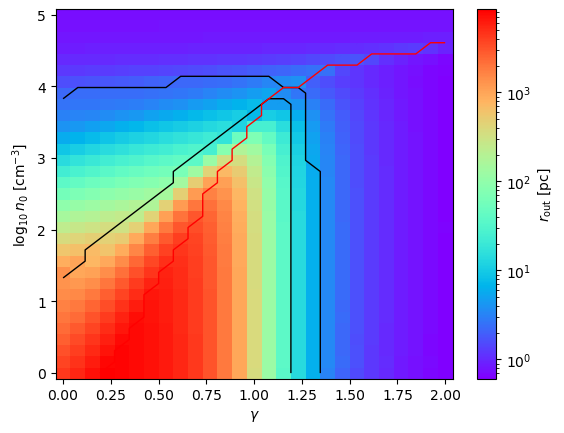

In [ ]:
fig, ax = plt.subplots()
p = ax.pcolormesh(gamma_array, np.log10(n_0_array.value), 
                #   np.reshape(index_list, X.shape), 
                  # critical_wavelength_array.to_value(u.um), 
                  # constraint_array,
                  # M_dust_array.to_value(u.Msun),
                  r_out_array.to_value(u.pc),
                  # -np.reshape(diff_list, X.shape),
                  shading='auto', 
                  # shading='gouraud', 
                  cmap='rainbow',
                  norm='log'
                  )
# ax.set_yscale('log')
# colorbar
# cbar = fig.colorbar(p, ax=ax, label=r"critical $\lambda$ [${\rm \mu m}$]")
# cbar = fig.colorbar(p, ax=ax, label=r"$M_{\rm dust}$ [$M_\odot$]")
cbar = fig.colorbar(p, ax=ax, label=r"$r_{\rm out}$ [pc]")
ax.set_xlabel(r"$\gamma$")
ax.set_ylabel(r"$\log_{10} n_0$ [${\rm cm}^{-3}$]")

# ax.contour(gamma_array, np.log10(n_0_array.value), 
#            critical_wavelength_array.to_value(u.um), 
#            colors='k', 
#            levels=[1, 3, 5, 100])

# 关键限制波长的分界线
# ax.contour(gamma_array, np.log10(n_0_array.value), critical_wavelength_array.to_value(u.um), colors='k', levels=[1, 3, 5, 100])
all_crit_indices = np.unique(crit_index_list)
ax.contour(gamma_array, np.log10(n_0_array.value),
         #   np.reshape(crit_index_list, X.shape), 
           np.ma.array(np.reshape(crit_index_list, X.shape), ),
           levels=(all_crit_indices[1:] + all_crit_indices[:-1]) / 2,
           colors='k', linewidths=1,
           )

#TEMP 画出由 NH_MAX 限制的区域
ax.contour(gamma_array, np.log10(n_0_array.value),
           constraint_array,
           levels=[(Constraint.NH_MAX+Constraint.RE_EMISSION)/2, ],
           colors='r', linewidths=1,
           )


In [ ]:
# 并行计算
A_V_max_from_M_gas_list = Parallel()(
    delayed(calc_A_V_max_from_M_gas_intersection_for_paras)(gamma=gamma, n_0=n_0, M_gas = 1e8*u.Msun) for n_0 in n_0_array for gamma in gamma_array   # 外层循环 y 轴，内层循环 x 轴
)

A_V_max_from_M_gas_array = np.reshape(A_V_max_from_M_gas_list, X.shape)

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Batch computation too fast (0.056205034255981445s.) Setting batch_size=2.
[Parallel(n_jobs=10)]: Done   5 tasks      | elapsed:    0.1s
[Parallel(n_jobs=10)]: Done  12 tasks      | elapsed:    0.1s
[Parallel(n_jobs=10)]: Done  22 tasks      | elapsed:    0.2s
[Parallel(n_jobs=10)]: Batch computation too fast (0.10948705673217773s.) Setting batch_size=4.
[Parallel(n_jobs=10)]: Done  40 tasks      | elapsed:    0.2s
[Parallel(n_jobs=10)]: Done  59 tasks      | elapsed:    0.3s
[Parallel(n_jobs=10)]: Done  72 tasks      | elapsed:    0.4s
[Parallel(n_jobs=10)]: Done  90 out of  99 | elapsed:    0.6s remaining:    0.1s
[Parallel(n_jobs=10)]: Done  99 out of  99 | elapsed:    0.7s finished


Text(0, 0.5, '$\\log_{10} n_0$ [${\\rm cm}^{-3}$]')

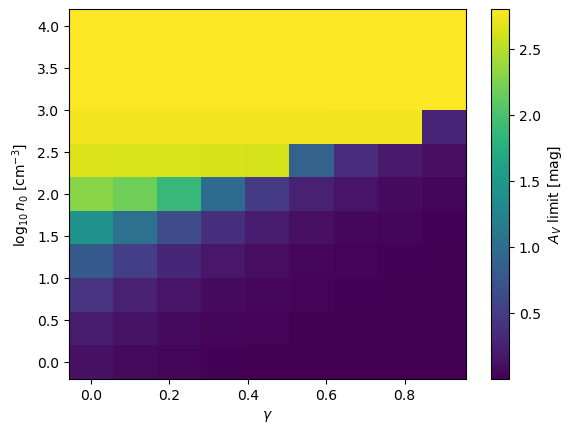

In [ ]:
fig, ax = plt.subplots()
p = ax.pcolormesh(gamma_array, np.log10(n_0_array.value), A_V_max_from_M_gas_array, 
                  shading='auto', 
                  # shading='gouraud', 
                  cmap='viridis')
# ax.set_yscale('log')
# colorbar
cbar = fig.colorbar(p, ax=ax, label=r"$A_V$ limit [mag]")
ax.set_xlabel(r"$\gamma$")
ax.set_ylabel(r"$\log_{10} n_0$ [${\rm cm}^{-3}$]")



# fig.savefig('figures/paras_survey/SMC_no_feedback_2.pdf', bbox_inches='tight')

Text(0, 0.5, '$\\log_{10} n_0$ [${\\rm cm}^{-3}$]')

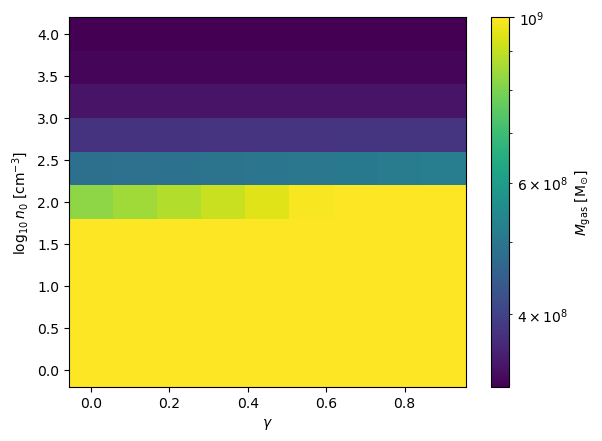

In [ ]:
from matplotlib.colors import LogNorm

fig, ax = plt.subplots()
p = ax.pcolormesh(gamma_array, np.log10(n_0_array.value), M_gas_array, 
                  shading='auto', 
                  # shading='gouraud', 
                  cmap='viridis',
                  norm=LogNorm( vmax=1e9),
                  )
# ax.set_yscale('log')
# colorbar
cbar = fig.colorbar(p, ax=ax, label=r"$M_{\rm gas}$ [${\rm M}_{\odot}$]")
ax.set_xlabel(r"$\gamma$")
ax.set_ylabel(r"$\log_{10} n_0$ [${\rm cm}^{-3}$]")



# fig.savefig('figures/paras_survey/SMC_no_feedback_2.pdf', bbox_inches='tight')

#### 旧版：提取结果、IO、计算 r_out 和 T_out 的尝试

In [ ]:
# # (旧版) 从 root_result_list 中提取结果
# root_result_list = list(root_result_list)

# A_V_max_list, res_list, constraint_list, crit_index_list, diff_list, M_gas_list = zip(*root_result_list)

# if not all(res.converged for res in res_list):
#     print("有的 root 没有收敛！")

# A_V_max_array = np.asarray(A_V_max_list).reshape(X.shape)
# constraint_array = np.asarray([c.value for c in constraint_list]).reshape(X.shape)
# crit_index_array = np.reshape(crit_index_list, X.shape)
# # critical_wavelength_array = Labbe_SED.wavelength[list(crit_index_list)].to(u.um).reshape(X.shape)  # 这里不应该固定为 Labbe_SED 的波长

# M_gas_array = Quantity(M_gas_list).reshape(X.shape)
# dust_to_gas_mass_ratio = 1e-2 * 0.1
# M_dust_array = M_gas_array * dust_to_gas_mass_ratio

TypeError: 'A_V_max_Result' object is not iterable

In [ ]:
# 保存数据

# _filename = 'data/dump/paras_survey/Labbe+Orion_compressed.npz'
# # _filename = 'data/dump/paras_survey/Labbe+SMC+ignore_UV.npz'

# np.savez_compressed(_filename, 
#          gamma_array=gamma_array, 
#          n_0_array=n_0_array, 
#          A_V_max_array=A_V_max_array, 
#          constraint_array=constraint_array,
#          crit_index_list=crit_index_list,
#          M_dust_array=M_dust_array,
#          )

In [ ]:
# 读取数据

# _dump_filename = 'data/dump/paras_survey/SMC.npz'
# # _dump_filename = 'data/dump/paras_survey/Orion.npz'

# data_from_file = np.load(_dump_filename)

# gamma_array = data_from_file['gamma_array']
# n_0_array = data_from_file['n_0_array'] * u.cm**-3  # savez 的时候会丢掉单位
# X, Y = np.meshgrid(gamma_array, n_0_array)

# A_V_max_array = data_from_file['A_V_max_array']
# constraint_array = data_from_file['constraint_array']
# crit_index_list = data_from_file['crit_index_list']

In [ ]:
# _dump_filename = 'data/dump/paras_survey/Labbe+SMC.npz'

# data_from_file = np.load(_dump_filename)

In [ ]:
def calc_r_out(*, n_0: Quantity, gamma: float, A_V: float) -> Quantity:
    np.seterr(over='ignore', divide='ignore')  # 忽略 overflow 和 divide by zero 的警告
    return create_model_with_fiducial(n_0=n_0, gamma=gamma, A_V=A_V).r_out

r_out_array = Parallel()(
    delayed(calc_r_out)(n_0=n_0, gamma=gamma, A_V=A_V) for gamma, n_0, A_V in tqdm(list(zip(X.flat, Y.flat, A_V_max_array.flat)))
)

r_out_array = Quantity(r_out_array).reshape(X.shape)

  0%|          | 0/9900 [00:00<?, ?it/s]

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  40 tasks      | elapsed:    0.3s
[Parallel(n_jobs=10)]: Done 3180 tasks      | elapsed:    3.0s
[Parallel(n_jobs=10)]: Done 9900 out of 9900 | elapsed:    7.8s finished


In [ ]:
def calc_T_out(*, n_0: Quantity, gamma: float, A_V: float) -> Quantity:
    np.seterr(over='ignore', divide='ignore')  # 忽略 overflow 和 divide by zero 的警告
    return create_model_with_fiducial(n_0=n_0, gamma=gamma, A_V=A_V).T_out

T_out_array = Parallel()(
    delayed(calc_T_out)(n_0=n_0, gamma=gamma, A_V=A_V) for gamma, n_0, A_V in tqdm(list(zip(X.flat, Y.flat, A_V_max_array.flat)))
)

T_out_array = Quantity(T_out_array).reshape(X.shape)

  0%|          | 0/891 [00:00<?, ?it/s]

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.


R_out_Error: The NH = <Quantity 1.30963436e+18 1 / cm2> is larger than possible self.NH_max = <Quantity 1.30772904e+18 1 / cm2> in this NH_profile with gamma = np.float64(1.3846153846153846), cannot find r

### 图 4：Analysis of stacked SED

In [101]:
paras_list_Delvecchio = [
    (0.5, 1e3 * u.cm**-3),
    (0.25, 10 * u.cm**-3),
    (0, 10 * u.cm**-3),
    (0, 1e5 * u.cm**-3),
    # (0.75, 5e2 * u.cm**-3),  # 在三个区域的交界处
]

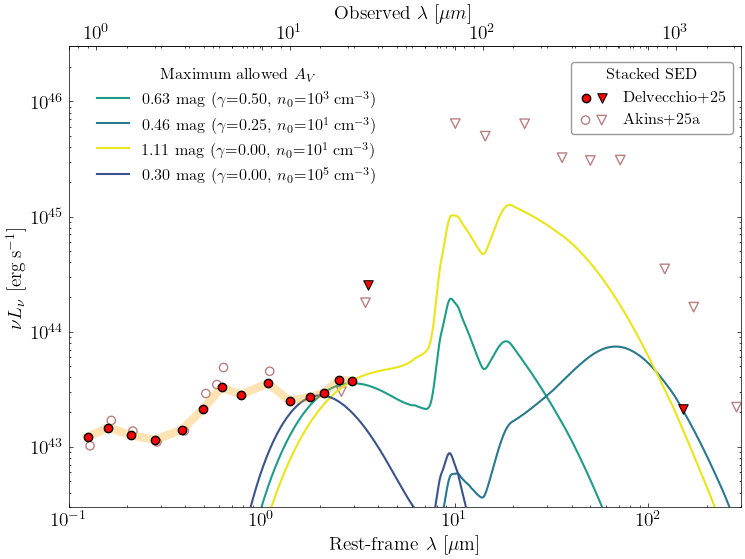

In [109]:
# 实心 vs 空心 表示不同数据
fig, ax = plt.subplots(figsize=np.array([8, 6]) * 0.93, layout='constrained',)

plot_4a = TypicalSEDPlot(
    model_factory=partial(create_model_with_basic),
    opacity=SMC_opacity,
    SED_table=Delvecchio_stacking_photo, 
    fmt = partial(quantity_to_latex, formatter='e', p=2)
)

plot_4a.set_style()

plot_4a.plot_panel_B(ax=ax, paras_list=paras_list_Delvecchio)

# 改变 Delvecchio detection 和 non-detection 的 marker style
import matplotlib as mpl
_handle_detection_foreground, _handle_nondetection_foreground = ax.findobj(mpl.collections.PathCollection)
# _handle_nondetection.set(lw=.75, sizes=[36*1.4])

ax.add_artist(ax.get_legend())

# ----------------------------- 画上 Akins 的数据，作为参考 ---------------------------- #

mask = (20 * u.um <= Akins_stacking_photo['wavelength_obs'])  # 筛选出我要的 non-detection 数据。有一个点与 Delvecchio 的 detection 波长范围重合，不要包括它
mask = slice(None)  # 尝试：画出所有 Akins 数据

_line_observed_sed, _handle_detection_background, _handle_nondetection_background = plot_observed_table(
    ax,
    x='wavelength_rest',
    y='nu_L_nu',
    table=Akins_stacking_photo[mask],
)

# 对于 Akins+24 中的 detection 的 marker 的 style 设置，by Kohei
_line_observed_sed.remove()
_handle_detection_background   .set(alpha=0.5, facecolor='none', edgecolor='#770000', lw=1, zorder=0)
_handle_nondetection_background.set(alpha=0.5, facecolor='none', edgecolor='#770000', lw=1, zorder=0)

from matplotlib.legend_handler import HandlerTuple
ax.legend([(_handle_detection_foreground, _handle_nondetection_foreground), 
           (_handle_detection_background, _handle_nondetection_background)], 
          ['Delvecchio+25', 'Akins+25a'], 
          handler_map={tuple: HandlerTuple(ndivide=None, pad=0)}, 
          title='Stacked SED',
          edgecolor='gray', 
          loc='upper right', 
          bbox_to_anchor=(1, .985)
          
)

ax.set_ylim(*[3e42, 3e46] * u.erg/u.s)

ax.set_title(None)


# fig.savefig('figures/stacked_SEDs/Delvecchio_typical_SEDs_v5.pdf', bbox_inches='tight')

In [ ]:
# 把 plot_4a 中的几条 SEDs 导出，用来发给 Kohei

table = QTable(
    {
        'wavelength_rest': plot_4a.panel_B_models[0].opacity.wavelength,
    } | {
        f"gamma={model.gamma}_n_0={model.n_0.to_value(u.cm**-3):.1e}_A_V={model.A_V.value:.2f}": model.calc_nu_L_nu()
        for model in plot_4a.panel_B_models
    }
)

table.write('data/export/plot4a_SEDs.csv', overwrite=True)

#### Delvecchio's SED + SMC, paras survey plot

In [ ]:
# # 保存数据

# # _dump_filename = 'data/dump/paras_survey/Delvecchio+SMC.npz'
# _dump_filename = 'data/dump/paras_survey/Delvecchio+SMC_Tfloor=0.npz'

# np.savez_compressed(_dump_filename, **A_V_max_result_arrays)

In [127]:
# 读取数据
_dump_filename = 'data/dump/paras_survey/Delvecchio+SMC.npz'
# _dump_filename = 'data/dump/paras_survey/Delvecchio+SMC_Tfloor=0.npz'

_data_from_file = load_paras_survey_data(_dump_filename);

In [171]:
%matplotlib widget

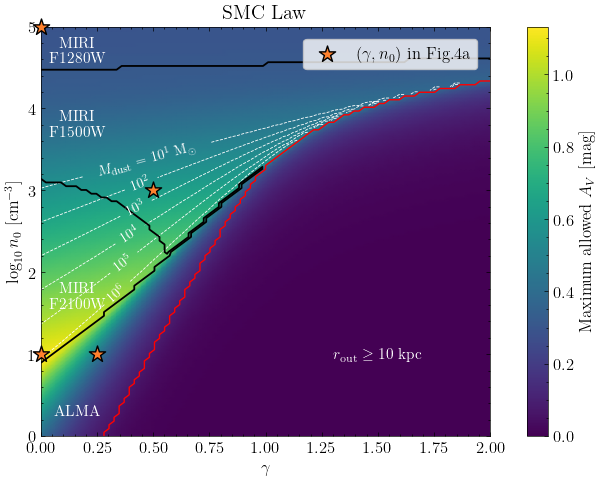

In [132]:
# Delvecchio's SED + SMC

_data_dict = _data_from_file
# _data_dict = A_V_max_result_arrays

plot_4b = ParasSurveyPlot(
    gamma_array=_data_dict["gamma_array"],
    n_0_array=_data_dict["n_0_array"],
    clabel_pos_line=LineString([[0.2, 0], [0.6, 5]]),
)

fig, ax = plot_4b.plot_figure_from_dict(
    data_dict=_data_dict,
    paras_list=paras_list_Delvecchio,
    fig_ref='Fig.4a'
)

# 添加文字，标记各个区域的限制波长（instrument）
_text_props = dict(ha='center', va='center', color='w', fontsize=11)
ax.text(.16, 0.3, "ALMA", **_text_props)
ax.text(.16, 1.7, "MIRI\nF2100W", **_text_props, zorder=100)
ax.text(.16, 3.8, "MIRI\nF1500W", **_text_props)
ax.text(.16, 4.7, "MIRI\nF1280W", **_text_props)
ax.text(1.5, 1, r"$r_{\rm out} \geq 10~{\rm kpc}$", **_text_props)  #TEMP

ax.set_title("SMC Law")

# fig.savefig('figures/paras_survey/Delvecchio+SMC_v5.pdf', bbox_inches='tight')

In [481]:
_data_dict['A_V_max'].max()

np.float64(1.1325050162343342)

(<matplotlib.collections.QuadMesh at 0x376cd6ad0>,
 <matplotlib.colorbar.Colorbar at 0x37100f9d0>)

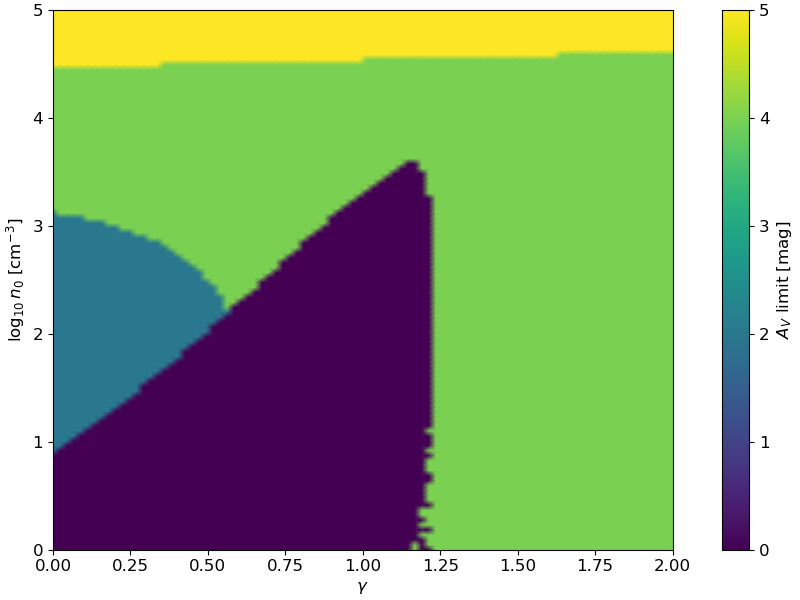

In [370]:
fig, ax = plt.subplots(figsize=(8, 6), layout='constrained',)

_plot = ParasSurveyPlot(gamma_array=_data_dict['gamma_array'], n_0_array=_data_dict['n_0_array'])

_plot.plot_A_V_max(fig=fig, ax=ax, A_V_max_array=_data_dict['crit_index'])

In [378]:
all_crit_indices = np.unique(_data_dict['crit_index'])

new_table = Delvecchio_stacking_photo.copy()
new_table.sort('nu_obs')
new_table[all_crit_indices]

wavelength_obs,fnu_obs,detection,wavelength_rest,nu_obs,nu_rest,Lnu_rest,nu_L_nu,Lnu_obs
um,mJy,,um,Hz,Hz,solLum / Hz,solLum,solLum / Hz
float64,float64,bool,float64,float64,float64,float64,float64,float64
1080.0,0.0177,False,150.0,277585609259.2593,1998616386666.6667,0.0029075698603806543,5811116768.334888,0.02093450299474071
21.0,0.000608,True,2.9166666666666665,14275831333333.334,102785985600000.0,9.987584605149368e-05,10265837274.036646,0.0007191060915707544
15.0,0.000342,True,2.0833333333333335,19986163866666.668,143900379840000.0,5.618016340396519e-05,8084346853.303859,0.0004044971765085494
12.8,0.000268,True,1.777777777777778,23421285781249.996,168633257624999.97,4.4024221614803125e-05,7423947905.309188,0.0003169743956265825


ALMA/Band-6 1080 um  
MIRI f2100w 21 um  
MIRI f1500w 15 um  
MIRI f1280w 12.8 um  

#### Akins's SED + SMC, paras survey plot

In [ ]:
# # 保存数据

# _dump_filename = 'data/dump/paras_survey/Akins+SMC.npz'

# np.savez_compressed(_dump_filename, **A_V_max_result_arrays)

In [497]:
# 读取数据
_dump_filename = 'data/dump/paras_survey/Akins+SMC.npz'

_data_from_file = load_paras_survey_data(_dump_filename);

In [ ]:
%matplotlib widget

Text(0.5, 1.0, 'SMC Law')

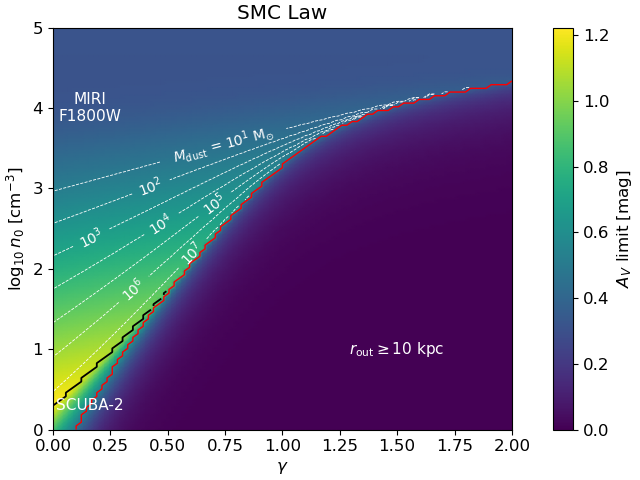

In [512]:
# Akins's SED + SMC

_data_dict = _data_from_file
# _data_dict = A_V_max_result_arrays

plot_4b = ParasSurveyPlot(gamma_array=_data_dict['gamma_array'], n_0_array=_data_dict['n_0_array'])

fig, ax = plot_4b.plot_figure_from_dict(
    data_dict=_data_dict,
)

# 添加文字，标记各个区域的限制波长（instrument）
_text_props = dict(ha='center', va='center', color='w', fontsize=11)
ax.text(.16, 0.3, "SCUBA-2", **_text_props)
ax.text(.16, 4, "MIRI\nF1800W", **_text_props)
ax.text(1.5, 1, r"$r_{\rm out} \geq 10~{\rm kpc}$", **_text_props)  #TEMP

ax.set_title("SMC Law")

# fig.savefig('figures/paras_survey/Akins+SMC_v2.pdf', bbox_inches='tight')

In [506]:
_data_dict['A_V_max'].max()

np.float64(1.2227482326827999)

(<matplotlib.collections.QuadMesh at 0x3787caad0>,
 <matplotlib.colorbar.Colorbar at 0x378a0c410>)

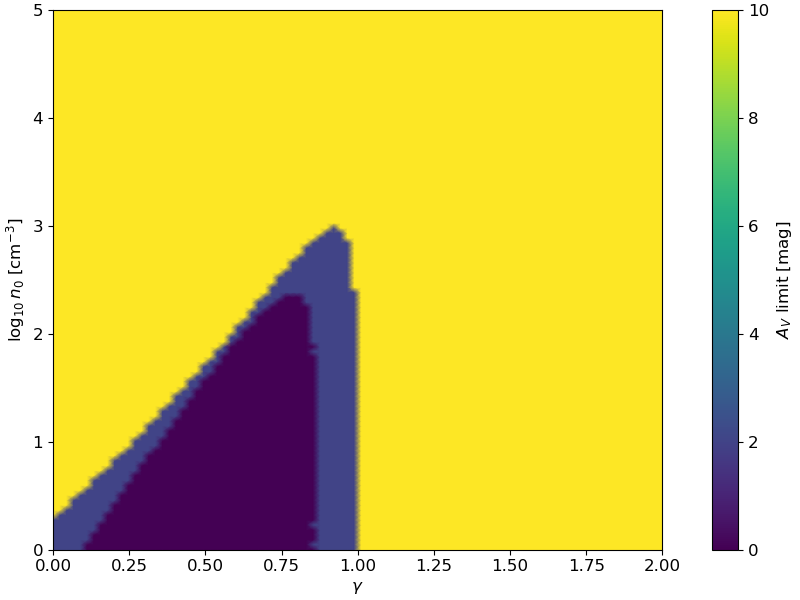

In [499]:
fig, ax = plt.subplots(figsize=(8, 6), layout='constrained',)

_plot = ParasSurveyPlot(gamma_array=_data_dict['gamma_array'], n_0_array=_data_dict['n_0_array'])

_plot.plot_A_V_max(fig=fig, ax=ax, A_V_max_array=_data_dict['crit_index'])

In [500]:
all_crit_indices = np.unique(_data_dict['crit_index'])

new_table = Akins_stacking_photo.copy()
new_table.sort('nu_obs')
new_table[all_crit_indices]

wavelength_obs,fnu_obs,detection,wavelength_rest,nu_obs,nu_rest,Lnu_rest,nu_L_nu,Lnu_obs
um,nJy,,um,Hz,Hz,solLum / Hz,solLum,solLum / Hz
float64,float64,bool,float64,float64,float64,float64,float64,float64
2000.0000000000002,35399.99999999999,False,285.7142857142857,149896229000.0,1049273602999.9999,0.005497819250545607,5768716613.662748,0.03848473475381924
850.0,238999.99999999997,False,121.42857142857143,352697009411.7647,2468879065882.353,0.037118045222610176,91639964816.57675,0.25982631655827126
18.0,435.2,False,2.5714285714285716,16655136555555.555,116585955888888.88,6.758900954343075e-05,7879929285.204106,0.0004731230668040152


### 图 4：？

Text(0.5, 0, '$A_V$ [mag]')

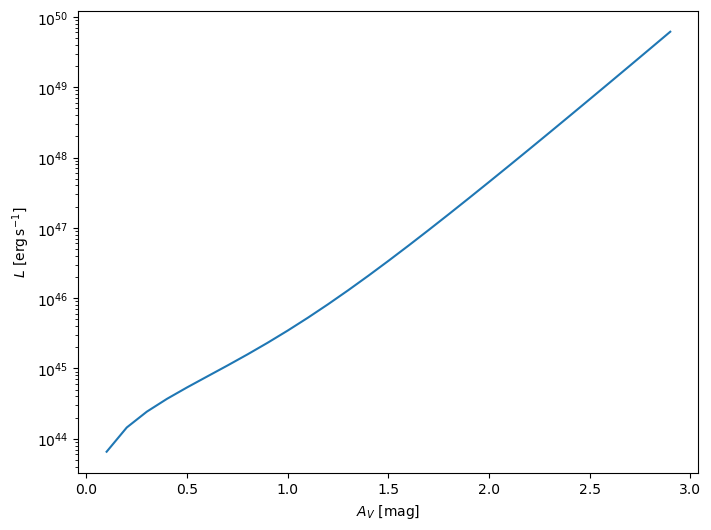

In [ ]:
A_V_list = np.arange(0.1, 3, 0.1)


fig, ax = plt.subplots(figsize=(8, 6))
L_list = Quantity([create_model_with_fiducial(A_V=A_V).calc_L_from_extinction() for A_V in A_V_list])
ax.plot(A_V_list, L_list, label='L from extinction')
ax.set_yscale('log')

set_xylabel_with_unit(ax, ylabel=r"$L$")
ax.set_xlabel(r"$A_V$ [mag]")

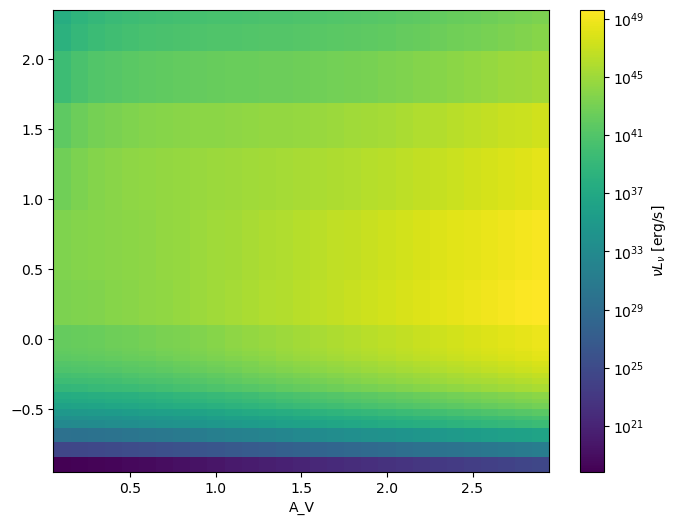

In [ ]:
from matplotlib.colors import LogNorm
def _func(A_V):
    model = create_model_with_fiducial(A_V=A_V)
    return model.calc_nu_L_nu(Labbe_SED.nu)
nu_L_nu_array = u.Quantity([_func(A_V=A_V) for A_V in A_V_list])

fig, ax = plt.subplots(figsize=(8, 6))

# cmap = plt.get_cmap('rainbow')
p = ax.pcolormesh(A_V_list, np.log10(Labbe_SED.wavelength.to_value(u.um)), nu_L_nu_array.T.value, label='L from SED', 
              shading='nearest', 
              cmap='viridis',
              norm=LogNorm()
             )
# ax.set_yscale('log')
ax.set_xlabel('A_V')
fig.colorbar(p, label=r"$\nu L_\nu$ [erg/s]")

### 图 5：Summary Plot

In [47]:
# 创建网格
gamma_array = np.linspace(0, 2, 9*10)
n_0_array = np.geomspace(1e0, 1e5, 11*10) * u.cm**-3

X, Y = np.meshgrid(gamma_array, n_0_array)

In [ ]:
# # 创建网格
# gamma_array = np.linspace(0, 2, 3)
# n_0_array = np.geomspace(1e0, 1e5, 2) * u.cm**-3

# X, Y = np.meshgrid(gamma_array, n_0_array)

In [115]:
(2+2)*4*(1+4)

80

In [47]:
calc_A_V_max_array_in_paras_space(
    gamma_array=gamma_array,
    n_0_array=n_0_array,
    model_factory=_model_factory,
    constraint_SED=SED.from_QTable(Labbe_photo)
)

NameError: name '_model_factory' is not defined

In [49]:
joblib.parallel_config(n_jobs=10)

In [50]:
obs_data_dict = {
    'A2744-45924': Labbe_photo, 
    'RUBIES-BLAGN-1': Wang_photo, 
    'Delvecchio+25': Delvecchio_stacking_photo,
    'Akins+24': Akins_stacking_photo,
    }
M_dust_limit_list = [np.inf, 1e6, 1e5, 1e4] * u.Msun

#* 输入参数：gamma_array, n_0_array, obs_data_dict, opacity_dict, M_dust_limit_list, create_model_with_basic。
#* 输出参数：rows

rows = []
for data_name, SED_table in tqdm(obs_data_dict.items(), desc="Observed SEDs"):
    for opacity_name, opacity in tqdm(opacity_dict.items(), desc="Opacity Laws"):

        _model_factory = partial(
            create_model_with_basic,
            opacity=opacity,
            observed_SED=get_SED_detection(SED_table),
            config={'T_floor': 30 * u.K, 'r_out_limit': 1e4 * u.pc},  #* 在 paras survey 时，额外限定 'r_out_limit': 1e4 * u.pc，从而在 paras survey plot 中画出 r > 10 kpc 的区域。
        )
        
        # 计算 re-emission 限制下的 A_V_max_array。与 M_dust_limit 无关
        A_V_max_array = calc_A_V_max_array_in_paras_space(
            n_0_array=n_0_array,
            gamma_array=gamma_array,
            model_factory=_model_factory,
            constraint_SED=SED.from_QTable(SED_table),
        )  # 从全局引入 n_0_array, gamma_array
        
        # 计算不同 M_dust_limit 下的 A_V_max_from_M_gas_array
        for M_dust_limit in M_dust_limit_list:
            if M_dust_limit == np.inf:
                A_V_max_from_M_gas_array = np.full_like(A_V_max_array, fill_value=np.inf)   # 对于不限制 M_dust 的情况，A_V_max_from_M_gas_array 设为 inf
            else:
                _map_func = partial(calc_A_V_max_from_M_gas_intersection_for_paras, M_gas=M_dust_limit / dust_to_gas_mass_ratio, model_factory=_model_factory)
                A_V_max_from_M_gas_array = Parallel()(
                    delayed(_map_func)(gamma=gamma, n_0=n_0) for n_0, gamma in product(n_0_array, gamma_array)  # 外层循环 y 轴，内层循环 x 轴  # 这里不加 tqdm，因为这个计算相比于 re-emission 限制的计算很快
                )
                
                shape = (len(n_0_array), len(gamma_array))
                A_V_max_from_M_gas_array = np.reshape(A_V_max_from_M_gas_array, shape)
            
            A_V_limit = np.minimum(A_V_max_array, A_V_max_from_M_gas_array).max()

            rows.append(
                (data_name, opacity_name, M_dust_limit, A_V_limit, A_V_max_array, A_V_max_from_M_gas_array,)
            )

Observed SEDs:   0%|          | 0/4 [00:00<?, ?it/s]

Opacity Laws:   0%|          | 0/4 [00:00<?, ?it/s]

paras survey:   0%|          | 0/9900 [00:00<?, ?it/s]

paras survey:   0%|          | 0/9900 [00:00<?, ?it/s]

paras survey:   0%|          | 0/9900 [00:00<?, ?it/s]

...

Opacity Laws:   0%|          | 0/4 [00:00<?, ?it/s]

paras survey:   0%|          | 0/9900 [00:00<?, ?it/s]

paras survey:   0%|          | 0/9900 [00:00<?, ?it/s]

paras survey:   0%|          | 0/9900 [00:00<?, ?it/s]

paras survey:   0%|          | 0/9900 [00:00<?, ?it/s]

In [51]:
summary_table_all = QTable(rows=rows, 
                          names=['observed_data', 'opacity', 'M_dust_limit', 'A_V_limit', 'A_V_max_array', 'A_V_max_from_M_gas_array'],
                          meta={'gamma_array': gamma_array, 'n_0_array': n_0_array})
#TEMP
A_V_max_from_all_array_table = np.minimum(summary_table_all['A_V_max_array'], summary_table_all['A_V_max_from_M_gas_array'])  # 把 Table 中每一行的 'A_V_max_array' 和 'A_V_max_from_M_gas_array' 取 minimum，得到一个 Column
summary_table_all['A_V_limit_gamma>=1'] = A_V_max_from_all_array_table[:, X >= 1].max(axis=1)  # 遍历所有 row，对每个元素（是个二维数组）筛选 X>=1，之后再对每一行求 max

In [52]:
scalar_names = [name for name in summary_table_all.colnames if summary_table_all[name].ndim <= 1]
summary_table = summary_table_all[scalar_names]

In [106]:
summary_table[summary_table['opacity'] == 'super SMC']

observed_data,opacity,M_dust_limit,A_V_limit,A_V_limit_gamma>=1
,,solMass,,
str14,str9,float64,float64,float64
A2744-45924,super SMC,inf,0.200818067345097,0.12523134212200288
A2744-45924,super SMC,1000000.0,0.200818067345097,0.12523134212200288
A2744-45924,super SMC,100000.0,0.17711163118451456,0.1214342413814921
A2744-45924,super SMC,10000.0,0.15492823940593303,0.1214342413814921
RUBIES-BLAGN-1,super SMC,inf,0.3100473298965901,0.2274438246036048
RUBIES-BLAGN-1,super SMC,1000000.0,0.2819798043822239,0.2274438246036048
RUBIES-BLAGN-1,super SMC,100000.0,0.2691500894741196,0.2274438246036048
RUBIES-BLAGN-1,super SMC,10000.0,0.2568314529909419,0.21574118946617935


In [ ]:
# summary_table_all = Table.read('data/processed/A_V_limit_summary_array.txt', format='ascii.ecsv')

In [111]:
# _table_file_name = 'summary_v1_res=9*11'
_table_file_name = 'summary_v1_res=27*33'      # default choice
# _table_file_name = 'summary_v1_res=90*110'

In [ ]:
# # 储存结果
# summary_table_all.write(f'data/processed/summary_table/{_table_file_name}_array.hdf5', serialize_meta=True, overwrite=True)
# summary_table    .write(f'data/processed/summary_table/{_table_file_name}_scalar.hdf5', serialize_meta=True, overwrite=True)

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/io/misc/hdf5.py:282: UserWarning: table path was not set via the path= argument; using default path __astropy_table__
  warnings.warn(


In [112]:
# 读取结果
summary_table_all = Table.read(f'data/processed/summary_table/{_table_file_name}_array.hdf5')
summary_table_all['observed_data'] = summary_table_all['observed_data'].astype(str)  # 确保 observed_data 是字符串类型

summary_table = Table.read(f'data/processed/summary_table/{_table_file_name}_scalar.hdf5')
summary_table['observed_data'] = summary_table['observed_data'].astype(str)  # 确保 observed_data 是字符串类型

In [633]:
summary_table[(summary_table['observed_data'] == 'RUBIES-BLAGN-1') & (summary_table['opacity'] == 'SMC')]

observed_data,opacity,M_dust_limit,A_V_limit,A_V_limit_gamma>=1
,,solMass,,
str14,bytes9,float64,float64,float64
RUBIES-BLAGN-1,SMC,inf,1.5285953547354558,1.0561647770433162
RUBIES-BLAGN-1,SMC,1000000.0,1.4322892629912307,1.0159712128862413
RUBIES-BLAGN-1,SMC,100000.0,1.338272164364825,1.0159712128862413
RUBIES-BLAGN-1,SMC,10000.0,1.2035447216169948,0.9776794690032656


In [56]:
# ...existing code...
import numpy as np
from astropy.table import Column

def three_values_to_asym_latex(values, *, unit=None, sort=True, fmt=".2f"):
    """
    values: 可迭代长度为 3 (lower, mid, upper) 或无序 3 个数
    unit:   astropy 的 Unit 或者字符串；None 则不加单位
    sort:   若 True，会先排序；若你已保证顺序就设 False
    fmt:    主值与误差的格式，如 '.2f'
    """
    arr = np.array(values, dtype=float)
    if arr.size != 3:
        raise ValueError("必须正好 3 个数")
    if sort:
        arr = np.sort(arr)
    lower, mid, upper = arr
    center = mid
    err_minus = center - lower
    err_plus  = upper - center
    # 允许误差为 0
    latex = f"{center:{fmt}}_{{-{err_minus:{fmt}}}}^{{+{err_plus:{fmt}}}}"
    if unit:
        latex += r"\,\mathrm{" + str(unit) + "}"
    return latex

# 使用示例：
mask = (
    (summary_table['observed_data'] == 'Delvecchio+25')
    & (summary_table['opacity'] == 'Orion')
    & (summary_table['M_dust_limit'] != np.inf)
)

col = summary_table[mask]['A_V_limit']          # 这是那一列 (3 个值)
# 若还想按照 M_dust_limit 升序对齐：
order = np.argsort(summary_table[mask]['M_dust_limit'])
vals = np.array(col)[order]

latex_str = three_values_to_asym_latex(vals, unit="mag")  # 或者 unit=col.unit (若有)
latex_str
# ...existing code...

'2.45_{-0.38}^{+0.40}\\,\\mathrm{mag}'

In [57]:
print(latex_str)

2.45_{-0.38}^{+0.40}\,\mathrm{mag}


In [ ]:
np.diff([0.8237114534870557, 0.9509031687052207, 1.0464143127263763]) # Labbe, SMC

array([0.12719172, 0.09551114])

In [ ]:
np.diff([1.4490613550478917, 1.8146877357527056, 2.12380949778004]) # Labbe, Orion

array([0.36562638, 0.30912176])

In [ ]:
np.diff([1.20368315077708, 1.3382712483924795, 1.4493198624790091])  # Wang, SMC 

array([0.1345881 , 0.11104861])

In [ ]:
np.diff([2.2255617072579064, 2.587560947022639, 2.861808739206081])  # Wang, Orion

array([0.36199924, 0.27424779])

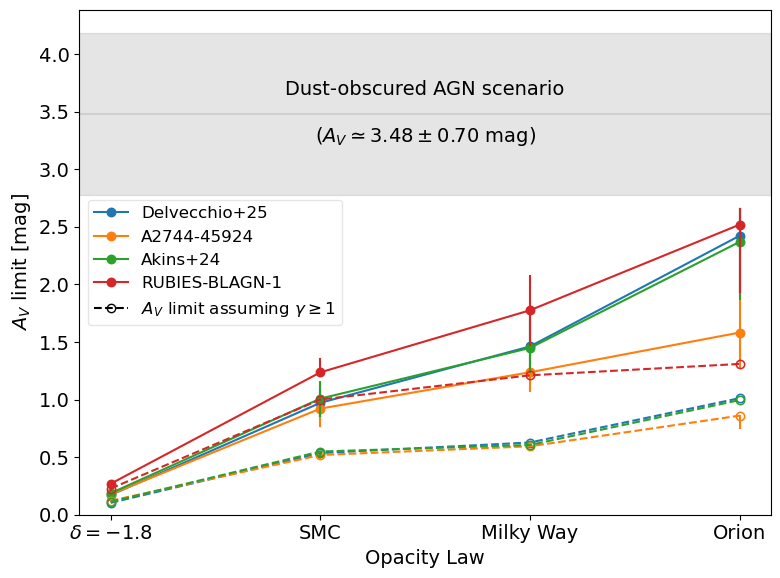

In [ ]:
# # 旧版 summary plot
# plt.rcdefaults()

# plt.rcParams['font.size'] = 14

# _table = summary_table[np.isfinite(summary_table['M_dust_limit'])]

# _options = dict(estimator=np.median, #TEMP 因为只有 3 个点，median 就是中间的 1e5 Msun
#                 errorbar=lambda arr: (arr.min(), arr.max()),
#                 # dodge=True, 
#                 markersize=6,
#                 lw=1.5,
#                 )

# g = sns.catplot(data=_table.to_pandas().sort_values('A_V_limit'), 
#             y='A_V_limit', x='opacity', hue='observed_data', 
#             kind='point', 
#             **_options,
#             height=6, aspect=4/3, 
#             legend='auto', legend_out=False)
# sns.pointplot(data=_table.to_pandas().sort_values('A_V_limit'), 
#             y='A_V_limit_gamma>=1', x='opacity', hue='observed_data', 
#             **_options,
#             fillstyle='none',
#             ls='--',
#             ax=g.ax,
#             legend=False)
# g.set_axis_labels(x_var='Opacity Law', y_var=r"$A_V$ limit [mag]")

# g.set_xticklabels(list(opacity_display_names.values())[::-1]) #TEMP 不该这么写的

# g.ax.plot([], [], color='k', marker='o',
#          label=r'$A_V$ limit assuming $\gamma \geq 1$', fillstyle='none', ls='--')  # 添加一个空的图例句柄
# #TEMP
# g.ax.legend(loc='best', frameon=True, 
#             # bbox_to_anchor=(0.02, 0.97), 
#             fontsize=12, 
#             framealpha=.5
#             )
# # g.ax.get_legend().set_title('Observed data')
# # g.legend.set_loc('upper left')



# A_V_Akins = 3.48
# g.ax.axhspan(A_V_Akins-.7, A_V_Akins+.7, color='gray', alpha=0.2)
# g.ax.axhline(A_V_Akins, color='gray', alpha=0.2)
# g.ax.text(1.5, A_V_Akins, 'Dust-obscured AGN scenario' + '\n\n' + r'($A_V \simeq 3.48\pm 0.70~{\rm mag}$)', ha='center', va='center')

# if False:
#     A_V_Galaxy = 2
#     g.ax.axhspan(A_V_Galaxy-.2, A_V_Galaxy+.2, color="#80BDD4", alpha=0.15)
#     g.ax.text(-.3, A_V_Galaxy, r'Galaxy@$z \sim ??$ (TEMP)', ha='left', va='center')

# g.ax.set_ylim(0)

# #TEMP
# g.ax.spines['top'].set_visible(True)
# g.ax.spines['right'].set_visible(True)

# # g.savefig('figures/summary/summary_plot_6.pdf', bbox_inches='tight')

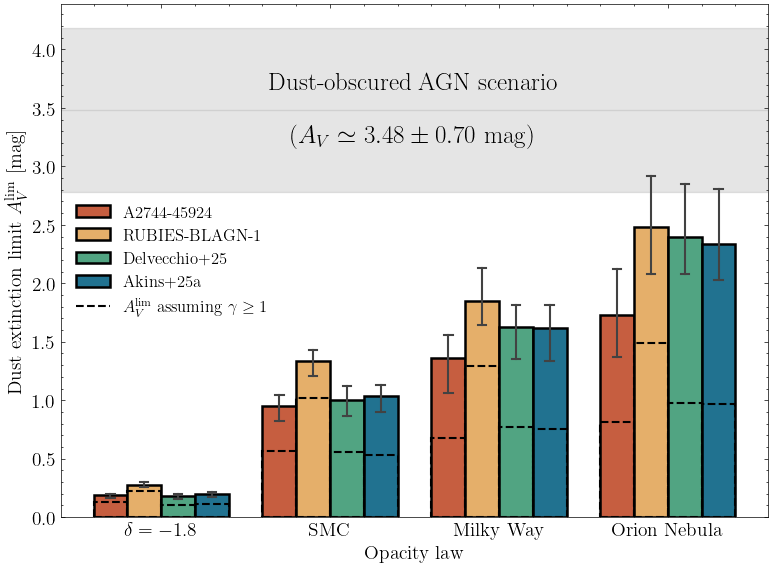

In [126]:
# 新版 summary plot，改用 barplot

plt.rcdefaults()
plt.style.use(['science',])
plt.rcParams['font.size'] = 14
# plt.rcParams['axes.linewidth'] = 1.
# plt.rcParams['lines.linewidth'] = 1.5

summary_table['observed_data'][summary_table['observed_data'] == 'Akins+24'] = 'Akins+25a'  # 把 Akins+24 更新为 Akins+25a

_table = summary_table[np.isfinite(summary_table['M_dust_limit'])]  # 排除掉 M_dust_limit = inf 的数据
# _table = summary_table
_df = _table.to_pandas()  # .sort_values('A_V_limit')


_options = dict(
    # dodge=True,
    # lw=1.5,
)


# M_dust_limit = [1e4, 1e5, 1e6] Msun 对应的 A_V_limit
g = sns.catplot(
    data=_df,
    kind='bar',
    y='A_V_limit',
    x='opacity',
    hue='observed_data',
    order=list(opacity_display_names)[::-1],
    estimator=np.median,  # TEMP 因为只有 3 个点，median 就是中间的 1e5 Msun
    errorbar=lambda arr: (arr.min(), arr.max()),
    capsize=0.2,
    height=6,
    aspect=4 / 3,
    ls='-',
    lw=1.8,
    edgecolor='k',
    legend='auto',
    legend_out=False,
    # palette=["#92C300", "#00D3A5", "#006FD1", "#2E47ED"], 
    # palette=sns.color_palette('muted'), 
    # palette=['#EE2617FF', '#F2A241FF', '#558934FF', '#0E54B6FF'], 
    palette=['#DD5129FF', '#FAB255FF',  '#43B284FF', '#0F7BA2FF',], 
    **_options,
)


# gamma >= 1 限制下的 A_V_limit
gamma_1_line_style = dict(ls='--', lw=1.5)
sns.barplot(
    data=_df,
    y='A_V_limit_gamma>=1',
    x='opacity',
    hue='observed_data',
    estimator=np.median,
    errorbar=None,
    facecolor='none',
    edgecolor='k',
    **gamma_1_line_style,
    # hatch='/',
    # hatch_linewidth=0.5,
    ax=g.ax,
    legend=False,
    **_options,
)

g.ax.plot(
    [], [], color='k', **gamma_1_line_style, label=r'$A_V^{\rm lim}$ assuming $\gamma \geq 1$'
)  # 添加一个空的图例句柄


# M_dust = inf 对应的 A_V_limit
if False:
    _df_M_dust_inf = summary_table[~np.isfinite(summary_table['M_dust_limit'])].to_pandas()
    
    sns.barplot(
        data=_df_M_dust_inf,
        y='A_V_limit',
        x='opacity',
        hue='observed_data',
        facecolor='none',
        edgecolor='k',
        ls=':',
        ax=g.ax,
        legend=False,
        **_options,
    )

    g.ax.plot(
        [], [], color='k', ls=':', label=r'$A_V^{\rm lim}$ limit without $M_{\rm dust}$ constraint'
    )  # 添加一个空的图例句柄


g.set_axis_labels(x_var='Opacity law', y_var=r"Dust extinction limit $A_V^{\rm lim}$ [mag]")

g.set_xticklabels(list(opacity_display_names.values())[::-1]) #TEMP 不该这么写的


# TEMP
g.ax.legend(loc='best', frameon=False, 
            # bbox_to_anchor=(0.02, 0.97), 
            fontsize=12, 
            framealpha=.5
            )
# g.ax.get_legend().set_title('Observed data')
# g.legend.set_loc('upper left')


A_V_Akins = 3.48
g.ax.axhspan(A_V_Akins-.7, A_V_Akins+.7, color='gray', alpha=0.2)
g.ax.axhline(A_V_Akins, color='gray', alpha=0.2)
g.ax.text(1.5, A_V_Akins, 'Dust-obscured AGN scenario' + '\n\n' + r'($A_V \simeq 3.48\pm 0.70~{\rm mag}$)', ha='center', va='center', size=18)

if False:
    A_V_Galaxy = 2
    g.ax.axhspan(A_V_Galaxy-.2, A_V_Galaxy+.2, color="#80BDD4", alpha=0.15)
    g.ax.text(-.3, A_V_Galaxy, r'Galaxy@$z \sim ??$ (TEMP)', ha='left', va='center')

g.ax.set_ylim(0)

# 让边框显示
g.ax.spines['top'].set_visible(True)
g.ax.spines['right'].set_visible(True)

# g.savefig('figures/summary/summary_plot_10.pdf', bbox_inches='tight')

### 图 6: PRIMA

#### PRIMA Sensitivity

PRIMA sensitivity

In [56]:
from astropy.table import QTable
PRIMA_sensitivity = {}

PRIMA_sensitivity['1arcmin^2_10h'] = QTable.read('data/PRIMA/1arcmin^2_10h.csv', 
            format='ascii', names=['lambda', 'f_nu'], units=[u.um, u.uJy], )
PRIMA_sensitivity['1arcmin^2_10h'].meta |= {'exposure_time': 10 * u.h, 'resolution': 1 * u.arcmin**2}

PRIMA_sensitivity['10arcmin^2_20h'] = QTable.read('data/PRIMA/10arcmin^2_20h.csv', 
            format='ascii', names=['lambda', 'f_nu'], units=[u.um, u.uJy],
            )
PRIMA_sensitivity['10arcmin^2_20h'].meta |= {'exposure_time': 20 * u.h, 'resolution': 10 * u.arcmin**2}

PRIMA sensitivity for Ichikawa's proposal (2025-05)

- Shallow survey goal:
  f_nu = 200 uJy at 24 um, f_nu = 460 uJy at 84 um
- Deep survey goal:
  f_nu = 40 uJy at 24 um, f_nu = 140 uJy at 84 um

In [57]:
PRIMA_sensitivity_Ichikawa = QTable([[24, 84] * u.um, [200, 460] * u.uJy, [40, 140] * u.uJy], names=['wavelength_obs', 'f_nu_shallow', 'f_nu_deep'],)

In [58]:
PRIMA_sensitivity_SED = SED(nu=(PRIMA_sensitivity['10arcmin^2_20h']['lambda'] / (1+Labbe_photo.meta['z'])).to(u.Hz, equivalencies=u.spectral()),
    L_nu=L_nu_rest_from_f_nu(f_nu=PRIMA_sensitivity['10arcmin^2_20h']['f_nu'], cosmology=cosmo, z=Labbe_photo.meta['z'], magnification=Labbe_photo.meta['magnification']).to(u.erg/u.s/u.Hz)
)

In [59]:
Labbe_SED_with_PRIMA = SED(nu=np.concat([Labbe_SED.nu, PRIMA_sensitivity_SED.nu]), 
    L_nu=np.concat([Labbe_SED.L_nu, PRIMA_sensitivity_SED.L_nu])
)

In [60]:
# calc_A_V_max_array_in_paras_space(n_0_array=n_0_array, gamma_array=gamma_array, 
#                                   constraint_SED=Labbe_photo, 
#                                   model_factory=_model_factory
#                                   )

#### Background Spectra

##### VB01

In [61]:
# VB01

VB01_template = QTable.read('data/SED_template/VB01.dat', format='ascii', names=['wavelength_rest', 'f_nu'], units=[u.AA, u.uJy],)
VB01_template_selected = VB01_template[VB01_template['wavelength_rest'] <= 9000 * u.AA]

In [62]:
VB01_template_selected['f_nu'].max()

<Quantity 14.11971 uJy>

##### 暂时用不到的

In [63]:
# 读取观测光谱数据
# 红移：李政融：wang:3.1034 taylor:9.288 de graff:3.55 furtak:7.045 Naidu:7.7569

background_spectra = {
    'MoM-150135': read_table_and_set_meta('data/observed_spectrum/mom-uds01-v3_prism-clear_5224_150135.spec.fits', meta={'z': 7.7569}),
    'RUBIES-UDS-154183': read_table_and_set_meta('data/observed_spectrum/rubies-uds31-v3_prism-clear_4233_154183.spec.fits', meta={'z': 3.55})
}



# table = QTable.read('data/observed_spectrum/119334_pablooptimal_calibrated_spectrum.fits')
# table = QTable(table, names=['wave', 'flux', 'flux_err'],  units=[u.um, u.uJy, u.Jy])
# background_spectra['119334'] = table


In [64]:
# # 导出到 CSV 格式的 txt 文件
# Labbe_spec_raw.write('data/observed_spectrum/export_csv/uncover-v2_prism-clear_2561_45924.txt', format='ascii.csv', overwrite=True,)
# background_spectra['MoM-150135'].write('data/observed_spectrum/export_csv/mom-uds01-v3_prism-clear_5224_150135.txt', format='ascii.csv', overwrite=True,)
# background_spectra['RUBIES-UDS-154183'].write('data/observed_spectrum/export_csv/rubies-uds31-v3_prism-clear_4233_154183.txt', format='ascii.csv', overwrite=True,)

In [65]:
furtak24 = QTable.read('data/observed_spectrum/furtak24_spectrum.txt', format='ascii', 
            names=['wav_obs', 'wav_rest', 'flam', 'flam_err'],
            units=[u.um, u.AA, 1e-20 * u.erg/u.s/u.cm/u.cm**2, u.erg/u.s/u.cm/u.cm**2]
            )
furtak24.meta['z'] = 7.045 

furtak24['wave'] = furtak24['wav_obs']
furtak24['nu_obs'] = const.c / furtak24['wav_obs']  # 观测频率
furtak24['flux'] = furtak24['flam'] * furtak24['wav_obs'] / furtak24['nu_obs']

background_spectra['Abell2744-QSO1'] = furtak24

#### 出图

##### 从 Fig.3a 中拿到 contour

In [244]:
# sample_points_on_contour_level 函数
import numpy as np
from matplotlib.contour import ContourSet

def sample_points_on_contour_level(
    contour_set: ContourSet, 
    *, 
    target_level: float, 
    num_samples: int
) -> np.ndarray:
    """
    在 ContourSet 对象的指定等值线上采样 N 个点。

    参数:
    contour_set (matplotlib.contour.ContourSet): 包含等值线信息的对象。
    target_level (float): 要采样的等值线的值。
    num_samples (int): 要采样的点的数量。

    返回:
    np.ndarray: 一个 Nx2 的 NumPy 数组，包含采样点的 (x, y) 坐标。
                如果找不到等值线或无法采样，则返回一个空的 NumPy 数组。
    """
    sampled_points = np.array([])

    if not hasattr(contour_set, 'levels') or not hasattr(contour_set, 'allsegs'):
        print("Error: ContourSet object is missing 'levels' or 'allsegs' attributes.")
        return sampled_points

    try:
        # 1. 找到目标 level 在 contour_set.levels 中的索引
        levels_list = list(contour_set.levels)
        level_idx = levels_list.index(target_level)
        
        # 2. 获取该 level 对应的所有线段（路径）
        segments_for_level: list[list[np.ndarray]] = contour_set.allsegs[level_idx]
        
        # 过滤掉无效或过短的线段（少于2个点无法构成线段）
        # contour_set.allsegs[i] 是一个列表，其中每个元素是一个 Nx2 的顶点数组
        valid_paths: list[np.ndarray] = []
        for path_segments in segments_for_level: # segments_for_level 本身可能是一个包含多个独立路径的列表
            # 在旧版本的 matplotlib 中，allsegs[i] 直接是路径列表 list[np.ndarray]
            # 在新版本中，allsegs[i] 可能是 list[list[np.ndarray]] 如果有多个不连续的等值线段
            # 这里我们假设 segments_for_level 是一个路径列表 list[np.ndarray]
            # 如果不是，需要根据 contour_set.allsegs 的实际结构调整
            # 实际上，matplotlib 文档指出 allsegs[i] is a list of arrays of vertices
            if isinstance(path_segments, np.ndarray) and path_segments.ndim == 2 and path_segments.shape[0] >= 2:
                valid_paths.append(path_segments)
            # The following was the original interpretation, which might be more robust
            # if isinstance(segments_for_level, list):
            #     for seg_array in segments_for_level:
            #         if isinstance(seg_array, np.ndarray) and seg_array.ndim == 2 and seg_array.shape[0] >= 2:
            #             valid_paths.append(seg_array)
        
        if not valid_paths:
            print(f"No valid path segments (>= 2 points) found for contour level {target_level}.")
            return sampled_points
        
        # 3. 将所有有效路径的顶点合并成一个连续的顶点序列
        path_vertices: np.ndarray = np.vstack(valid_paths)
        num_path_vertices: int = path_vertices.shape[0]

        if num_path_vertices < 2:
            print(f"Not enough distinct vertices ({num_path_vertices}) in combined path for interpolation at level {target_level}.")
            return path_vertices if num_path_vertices > 0 else sampled_points
        
        #TEMP TEST
        # return path_vertices

        # 4. 计算沿路径的累积距离
        segment_vectors: np.ndarray = np.diff(path_vertices, axis=0)
        segment_lengths: np.ndarray = np.sqrt(np.sum(segment_vectors**2, axis=1))
        
        cumulative_distances: np.ndarray = np.zeros(num_path_vertices)
        cumulative_distances[1:] = np.cumsum(segment_lengths)
        total_length: float = cumulative_distances[-1]

        if total_length < 1e-9:  # 路径总长度几乎为零
            print(f"Warning: Contour path for level {target_level} has effectively zero length. Sampling the start point {num_samples} times.")
            sampled_points = np.repeat(path_vertices[0:1, :], num_samples, axis=0)
        else:
            # 5. 生成沿路径总长度均匀分布的采样距离点
            sample_distances: np.ndarray = np.linspace(0, total_length, num_samples)
            
            # 6. 对 x 和 y 坐标分别进行一维线性插值
            sampled_x: np.ndarray = np.interp(sample_distances, cumulative_distances, path_vertices[:, 0])
            sampled_y: np.ndarray = np.interp(sample_distances, cumulative_distances, path_vertices[:, 1])
            
            sampled_points = np.vstack((sampled_x, sampled_y)).T

    except ValueError:
        print(f"Error: Level {target_level} not found in contour levels: {contour_set.levels}")
    except IndexError:
        print(f"Error: IndexError accessing segments for level {target_level}. Level index might be out of bounds for allsegs.")
    
    return sampled_points

# --- 调用示例 ---
# 假设 cntr 是已经通过 ax.contour(...) 创建的 ContourSet 对象
# fig, ax, cntr 这些变量需要在调用此函数前被定义

# target_level_to_sample = 1e5
# number_of_samples = 100

# sampled_points_on_contour = sample_points_on_contour_level(cntr, target_level_to_sample, number_of_samples)

# if sampled_points_on_contour.ndim == 2 and sampled_points_on_contour.shape[0] > 0:
#     print(f"\nSuccessfully sampled {sampled_points_on_contour.shape[0]} points for contour level {target_level_to_sample}.")
#     # print(f"First sampled point: {sampled_points_on_contour[0]}")
#     # (可选) 在图上绘制采样点以验证
#     # if 'ax' in locals() and ax is not None: # 检查 ax 是否已定义
#     #     ax.plot(sampled_points_on_contour[:, 0], sampled_points_on_contour[:, 1], 
#     #             'mo', markersize=4, label=f'Interpolated pts for {target_level_to_sample:.0e}', zorder=102, alpha=0.7)
#     #     if not ax.get_legend():
#     #         ax.legend()
#     #     else:
#     #         handles, labels = ax.get_legend_handles_labels()
#     #         if f'Interpolated pts for {target_level_to_sample:.0e}' not in labels:
#     #             ax.legend()
# elif sampled_points_on_contour.size > 0:
#     print(f"\nSampled points for level {target_level_to_sample} (possibly a single point repeated):\n{sampled_points_on_contour}")
# else:
#     print(f"\nNo points were sampled for level {target_level_to_sample}.")

# # 你选择的单元格内容，现在可以这样调用：
# # sampled_points_on_contour = sample_points_on_contour_level(cntr, 1e5, 100) # 假设 cntr 已定义
# ...existing code...

In [52]:
# 读取数据
_dump_filename = 'data/dump/paras_survey/Labbe+SMC_res=90*110.npz'
# _dump_filename = 'data/dump/paras_survey/Labbe+SMC_res=100_100.npz'

_data_from_file = load_paras_survey_data(_dump_filename);

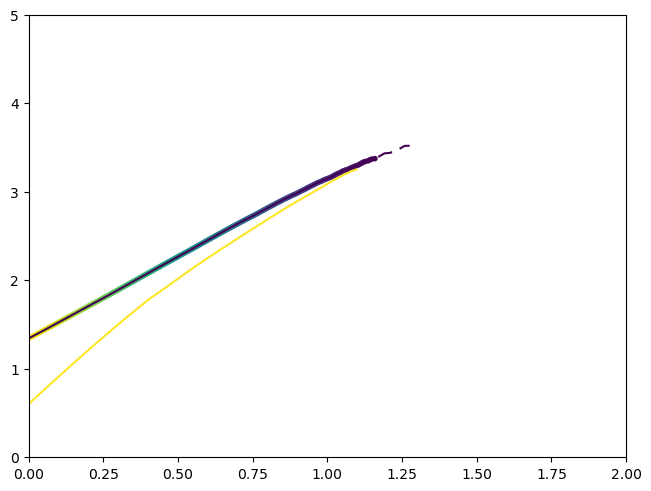

In [ ]:
%matplotlib inline

NH_MAX_mask = (_data_from_file['constrained_by']==Constraint.NH_MAX)

fig, ax = plt.subplots(layout='constrained',)
contour_set = ax.contour(_data_from_file['gamma_array'], np.log10(_data_from_file['n_0_array'].value),
        #   np.where(X<1.35, M_dust_array.to_value(u.Msun), np.nan),
        np.ma.array(_data_from_file['M_dust'].to_value(u.Msun), 
                    mask=NH_MAX_mask, fill_value=np.nan
                    ),
        levels=[1e5, 1e6],
        )

sampled_points_on_contour = contour_sampling.sample_points_on_contour(contour_set, target_level=1e5, num_samples=200, merge_strategy='longest')
# sampled_points_on_contour = np.linspace([0.25, 0], [0.25, 5], 300)

ax.scatter(sampled_points_on_contour[:, 0], sampled_points_on_contour[:, 1], 
           c=plt.get_cmap('viridis')(np.linspace(0,1, len(sampled_points_on_contour))), 
           marker='.')

In [66]:
_model_factory_PRIMA = partial(
    create_model_with_basic,
    opacity=SMC_opacity,
    observed_SED=get_SED_detection(Labbe_photo),
    config={'T_floor': 30 * u.K, 'r_out_limit': 1e4 * u.pc},  #* 在 paras survey 时，额外限定 'r_out_limit': 1e4 * u.pc，从而在 paras survey plot 中画出 r > 10 kpc 的区域。
    # config={'T_floor': 0 * u.K, 'r_out_limit': 1e4 * u.pc},  #TEMP 尝试取消 T_floor
)

A_V_max_list_on_contour = np.array(
    [
        res.A_V_max
        for res in calc_A_V_max_for_paras_list(
            paras_list=[(gamma, 10**lg_n_0 * u.cm**-3) for gamma, lg_n_0 in sampled_points_on_contour],
            model_factory=_model_factory_PRIMA,
            constraint_SED=SED.from_QTable(Labbe_photo),
        )
    ]
)

paras survey:   0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
# 插进去一个 nan，这样画出来的线中间是间断的
PRIMA_sensitivity['10arcmin^2_20h'].insert_row(3, [90 * u.um, np.nan * u.uJy])
PRIMA_sensitivity['10arcmin^2_20h']

In [86]:
# deep reload LRD_IR_spectrum
import LRD_IR_spectrum
deep_reload(LRD_IR_spectrum)
from LRD_IR_spectrum import *

/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/plotting/PRIMA_plot.py:143: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string ".-" (-> marker='.'). The keyword argument will take precedence.
  lw=3, color="#F48C4B", marker='D', markersize=6,)


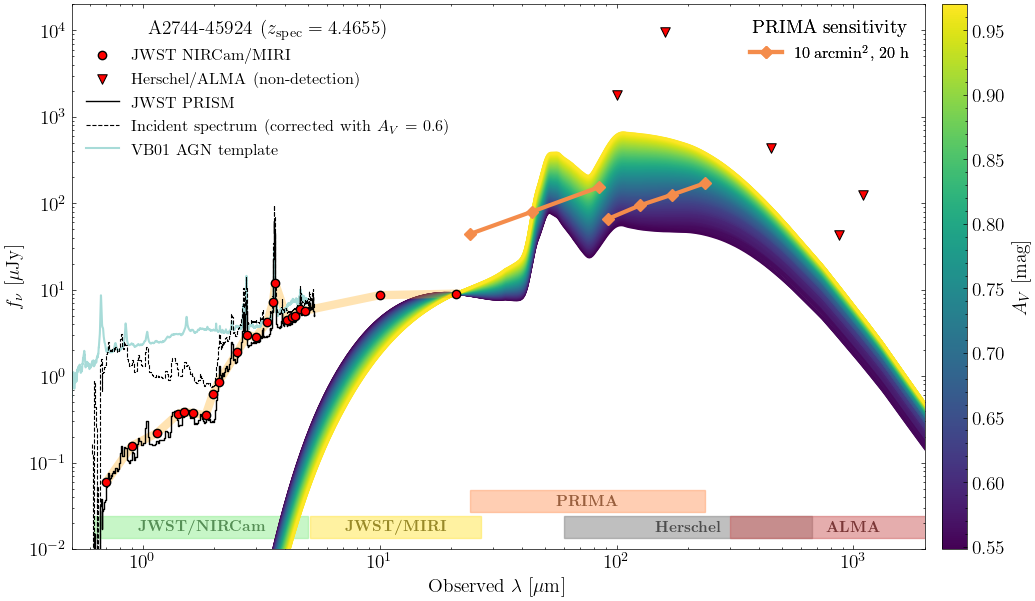

In [ ]:
import scienceplots
plt.rcdefaults()
plt.style.use(['science',])
plt.rcParams['lines.linewidth'] = 1.5

plt.rcParams['font.size'] = 14
plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['legend.title_fontsize'] = 'medium'


plot_6 = PRIMA_Plot()
plot_6.plot_figure(
    sampled_points_on_contour=sampled_points_on_contour,
    A_V_max_list_on_contour=A_V_max_list_on_contour,
    model_factory=_model_factory_PRIMA,
    SED_table=Labbe_photo,
    cosmology=WMAP9,
    Labbe_spec_raw=Labbe_spec_raw,
    PRIMA_sensitivity=PRIMA_sensitivity,
    VB01_template_selected=VB01_template_selected,
    opacity=SMC_opacity,
)

# plot_6.fig.savefig('figures/PRIMA/M_dust=1e5_v5.pdf', bbox_inches='tight')

In [ ]:
# fig.savefig('figures/PRIMA/M_dust=1e5_Ichikawa.pdf', bbox_inches='tight') 

## 限制 $A_V$

### 随 $A_V$ 的变化

In [ ]:
np.seterr(over='ignore', divide='ignore')  # 忽略 overflow 和 divide by zero 的警告

A_V_list = np.arange(0., 6, 0.1)

r_in_list = []
for A_V in A_V_list:
    model = create_model_with_fiducial(n_0=1e0 * u.cm**-3, gamma=2, A_V=A_V)
    r_in_list.append(model.r_in)
    
r_in_list = Quantity(r_in_list)  # 转换为 astropy 的 Quantity 对象

In [ ]:
r_in_list

<Quantity [2.06391283e-01, 2.25612767e-01, 2.49831251e-01, 2.80790962e-01,
           3.20816325e-01, 3.72966740e-01, 4.41230670e-01, 5.30780872e-01,
           6.48321081e-01, 8.02560373e-01, 1.00485663e+00, 1.27007881e+00,
           1.61775226e+00, 2.07357401e+00, 2.67141526e+00, 3.45596946e+00,
           4.48625716e+00, 5.84026904e+00, 7.62112098e+00, 9.96521852e+00,
           1.30530914e+01, 1.71237773e+01, 2.24939248e+01, 2.95831707e+01,
           3.89478657e+01, 5.13259056e+01, 6.76963442e+01, 8.93586819e+01,
           1.18038355e+02, 1.56027118e+02, 2.06369905e+02, 2.73113636e+02,
           3.61638547e+02, 4.79099562e+02, 6.35014345e+02, 8.42046975e+02,
           1.11705253e+03, 1.48246971e+03, 1.96817790e+03, 2.61397392e+03,
           3.47287600e+03, 4.61553200e+03, 6.13610197e+03, 8.16010958e+03,
           1.08549231e+04, 1.44437488e+04, 1.92243172e+04, 2.55938398e+04,
           3.40823442e+04, 4.53972102e+04, 6.04826749e+04, 8.05993529e+04,
           1.07430516e+05

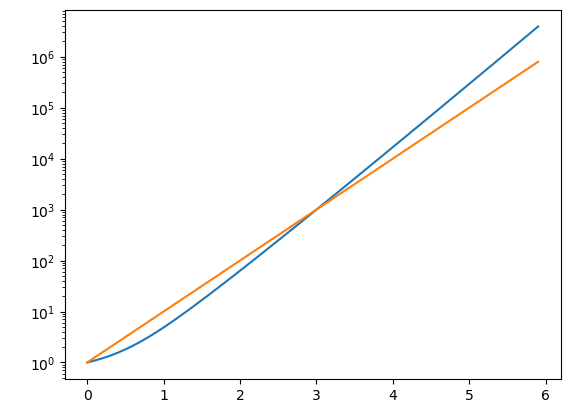

In [ ]:
fig, ax = plt.subplots()
ax.plot(A_V_list, r_in_list / r_in_list[0])
ax.plot(A_V_list, 10**(0.2* 5 * A_V_list))
ax.set_yscale('log')


/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


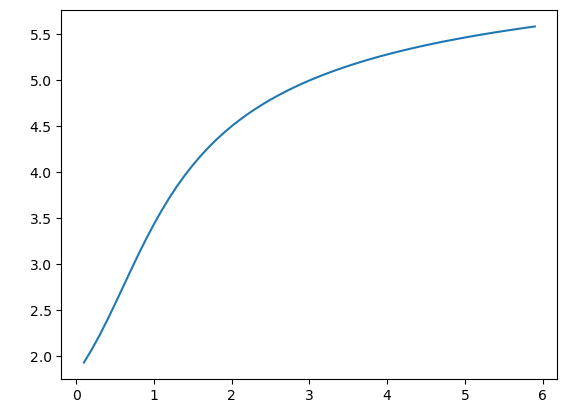

In [ ]:
fig, ax = plt.subplots()
ax.plot(A_V_list, np.log10(r_in_list/r_in_list[0]) / A_V_list /.2)
# ax.set_yscale('log')


### $\gamma > 1$ 时的 $N_H$ max 限制 

In [ ]:
create_model_with_fiducial(n_0=1e0 * u.cm**-3, gamma=2, A_V=1).A_V_max_from_NH_max.value

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


np.float64(0.00012601139896617424)

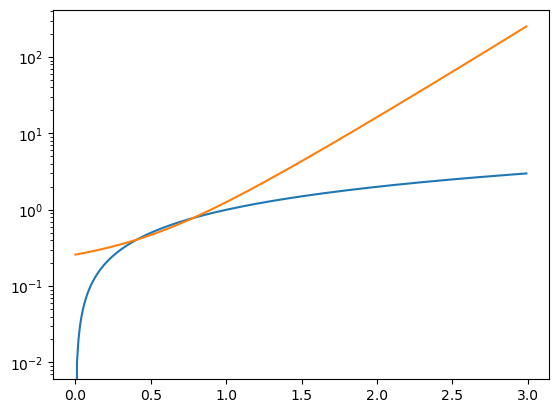

In [ ]:
A_V_list = np.arange(0., 3, 1e-2)

A_V_max_list = []
for A_V in A_V_list:
    A_V_max = create_model_with_fiducial(n_0=1e4 * u.cm**-3, gamma=2, A_V=A_V).A_V_max_from_NH_max.value
    A_V_max_list.append(A_V_max)
    
fig, ax = plt.subplots()
ax.plot(A_V_list, A_V_list, label='A_V_max')
ax.plot(A_V_list, A_V_max_list, label='A_V_max')
ax.set_yscale('log')

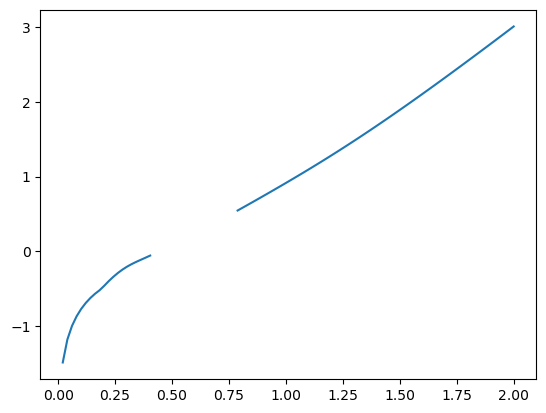

In [ ]:
A_V_list = np.linspace(0, 2, 100)
diff_list = []
for A_V in A_V_list:
    try:
        _index, diff = paras_diff(gamma=2, n_0=1e4 * u.cm**-3, A_V=A_V)
    except R_out_Error:
        diff = np.inf
    diff_list.append(diff)
    
    
fig, ax = plt.subplots()
ax.plot(A_V_list, diff_list)

### M_dust 限制

In [117]:
paras = dict(gamma=0, n_0=1e3 * u.cm**-3)
M_dust_limit = 1e5 * u.Msun

_model_factory = partial(
    create_model_with_basic,
    opacity=Orion_opacity,
    observed_SED=get_SED_detection(Wang_photo),
    config={
        'T_floor': 30 * u.K,
        'r_out_limit': 1e4 * u.pc,
    },  # * 在 paras survey 时，额外限定 'r_out_limit': 1e4 * u.pc，从而在 paras survey plot 中画出 r > 10 kpc 的区域。
)

In [118]:
calc_A_V_max_from_M_gas_intersection_for_paras(
    **paras,
    M_gas=M_dust_limit / dust_to_gas_mass_ratio,
    model_factory=_model_factory
)

8.366728864151579

In [ ]:
np.seterr(over='ignore', divide='ignore')  # 忽略 overflow 和 divide by zero 的警告

A_V_list = np.arange(0., 15, 0.1)
result_list = []
for A_V in A_V_list:
    model = _model_factory(A_V=A_V, **paras)
    result_list.append(model.A_V_out_from_M_gas(M_dust_limit / dust_to_gas_mass_ratio).value)

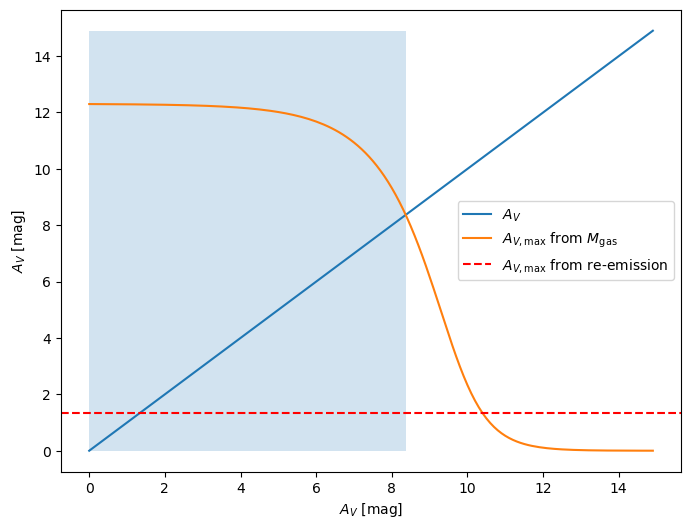

In [103]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(A_V_list, A_V_list, label=r'$A_V$')
ax.plot(A_V_list, result_list, label=r'$A_{V, {\rm max}}$ from $M_{\rm gas}$')
ax.axhline(
    y=calc_A_V_max_for_paras(
        **paras,
        model_factory=_model_factory,
        constraint_SED=SED.from_QTable(Wang_photo)
    ).A_V_max,
    color='r',
    linestyle='--',
    label=r'$A_{V, {\rm max}}$ from re-emission',
)

A_V_intersection = calc_A_V_max_from_M_gas_intersection_for_paras(
    **paras, M_gas=M_dust_limit / dust_to_gas_mass_ratio, model_factory=_model_factory
)
ax.fill_betweenx([0, A_V_list.max()], 0, A_V_intersection, alpha=0.2)

ax.set_xlabel(r"$A_V$ [mag]")
ax.set_ylabel(r"$A_V$ [mag]")
ax.legend()

### 光谱图

interactive(children=(FloatLogSlider(value=1000.0, description='n_0', max=6.0, step=0.01), FloatSlider(value=0…

<function __main__.interactive_plot(*, n_0: float, gamma: float, A_V: float, opacity: LRD_IR_spectrum.opacity.OpacityData, T_floor: float = 30, T_sub: float = 1500)>

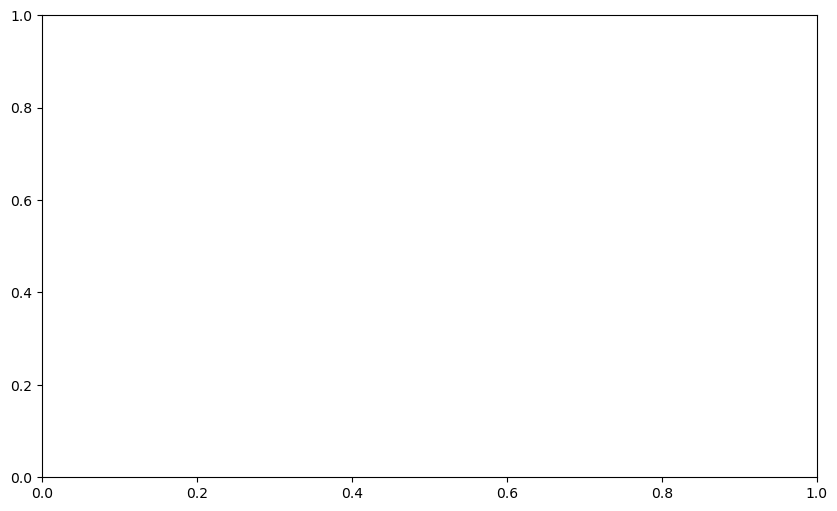

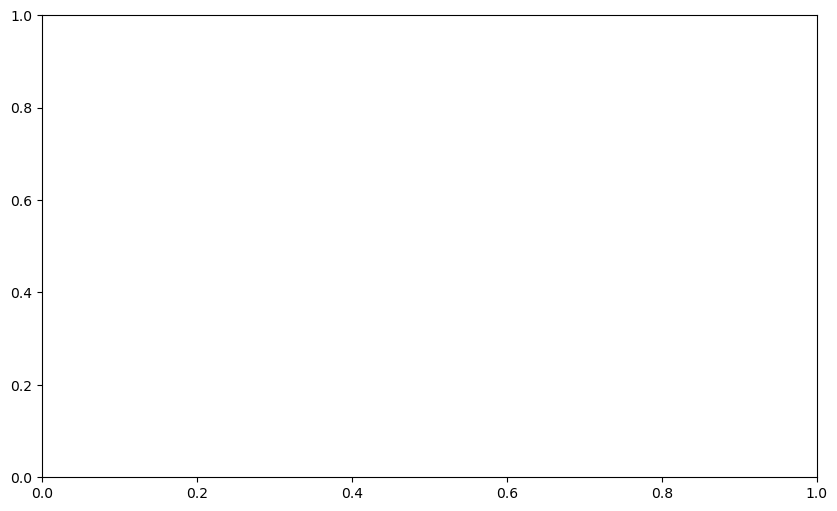

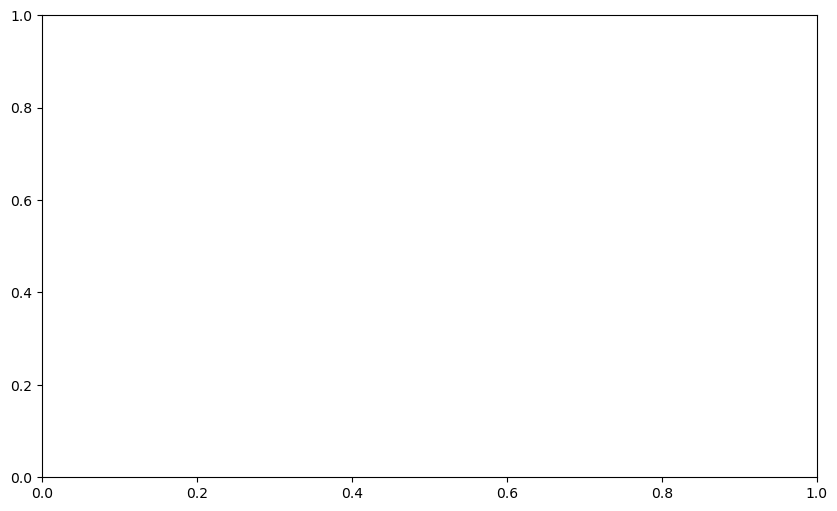

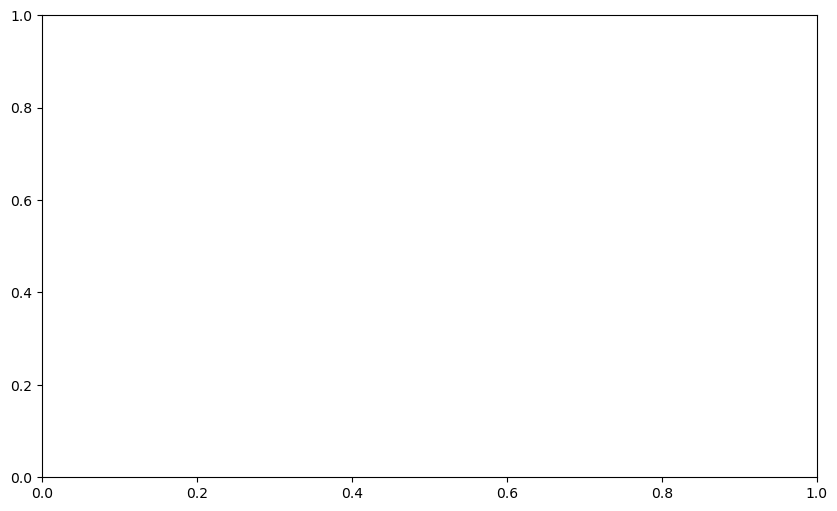

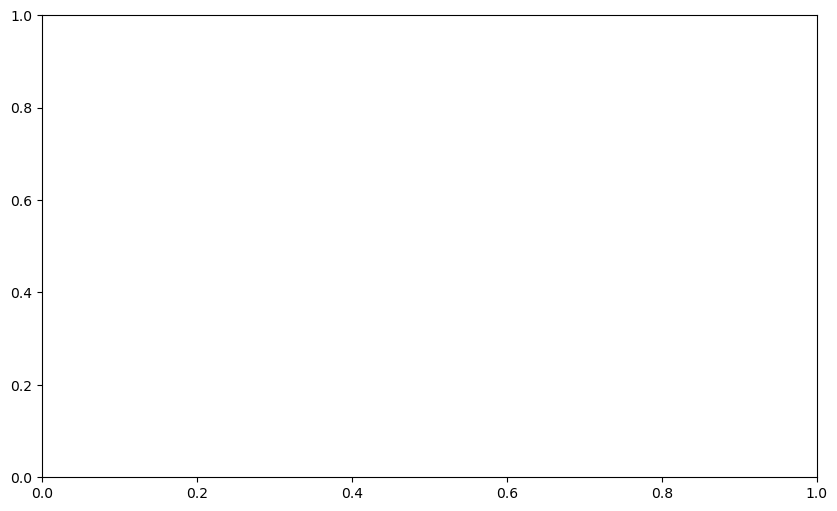

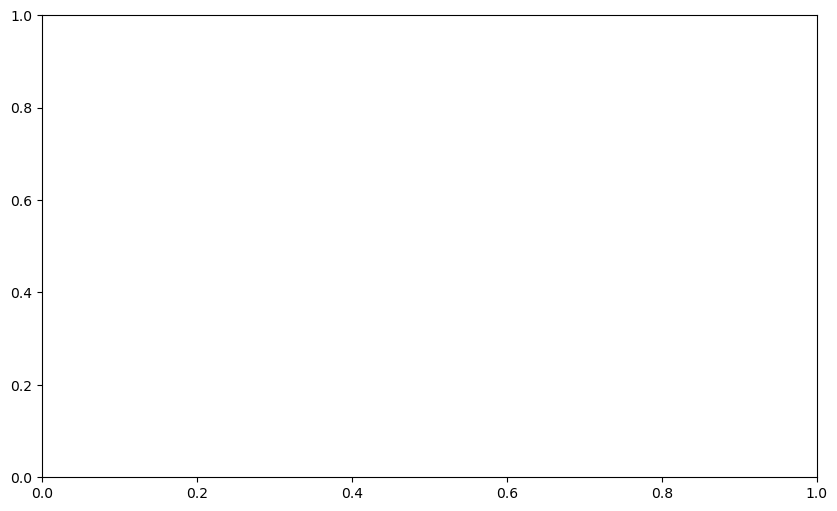

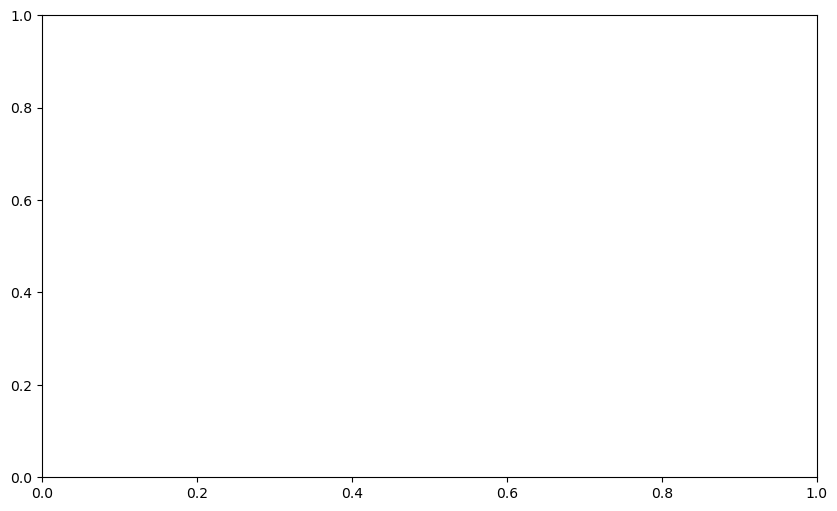

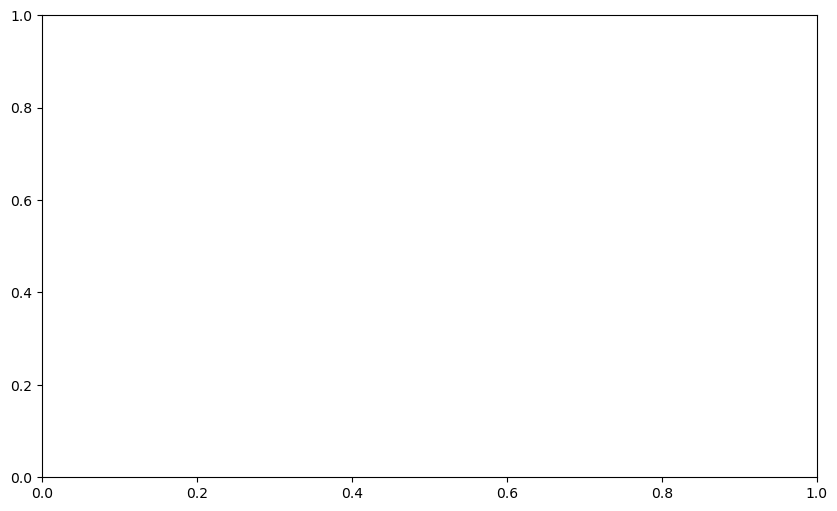

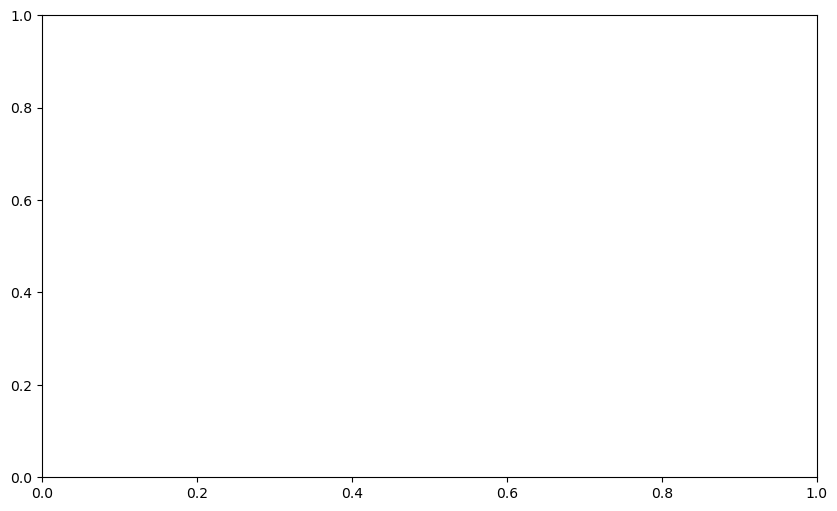

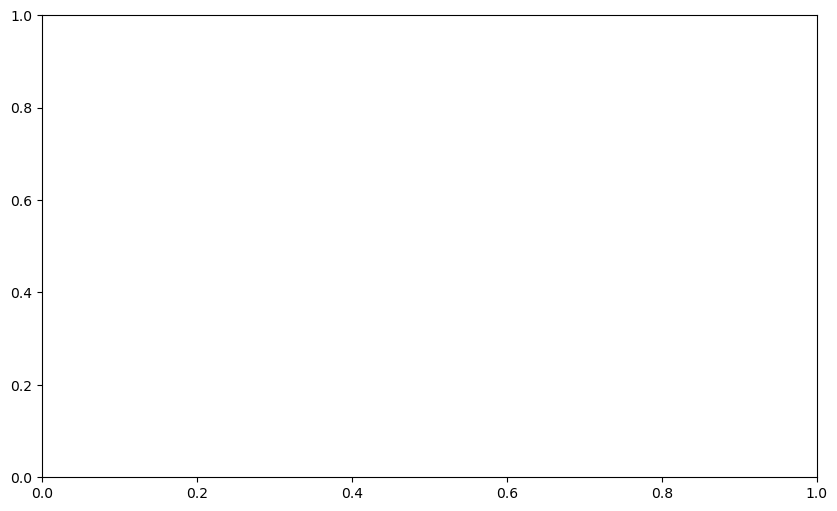

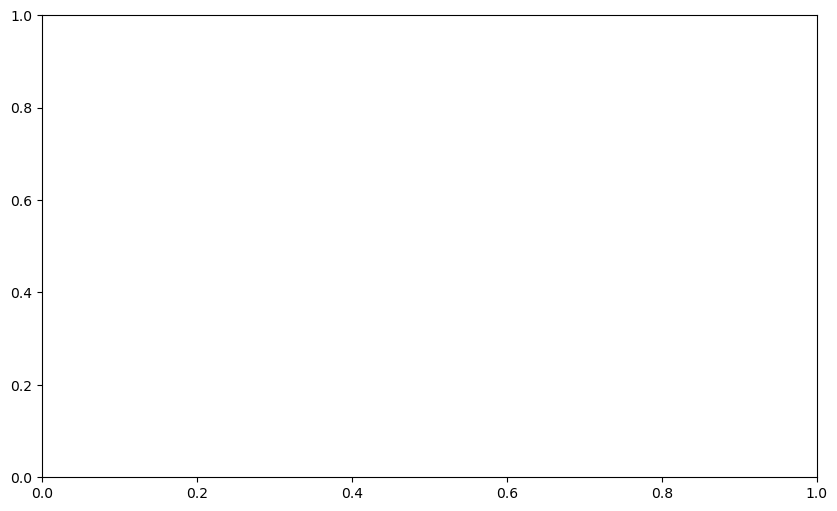

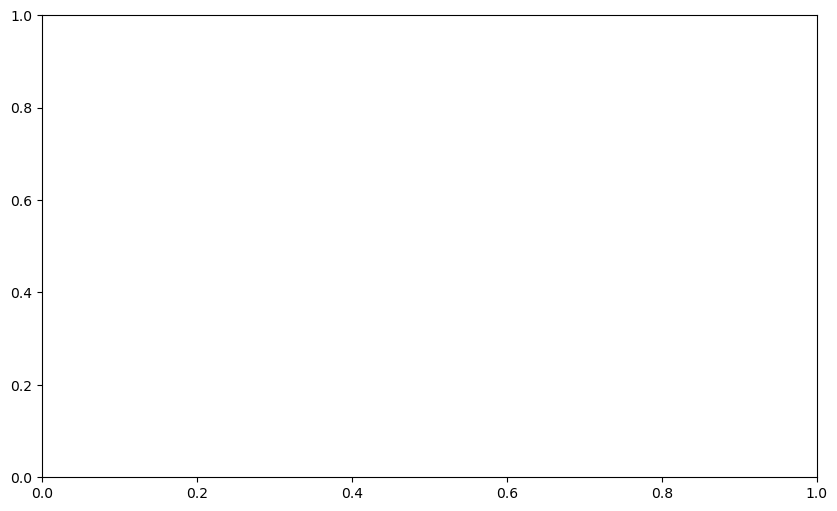

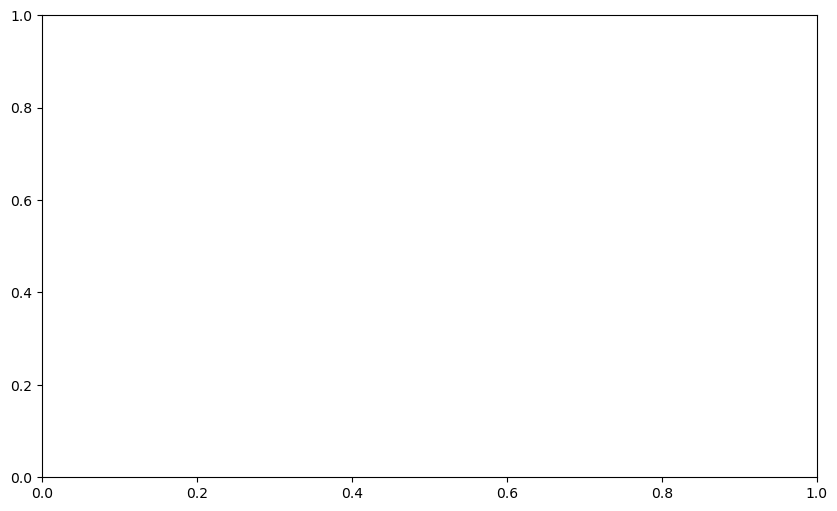

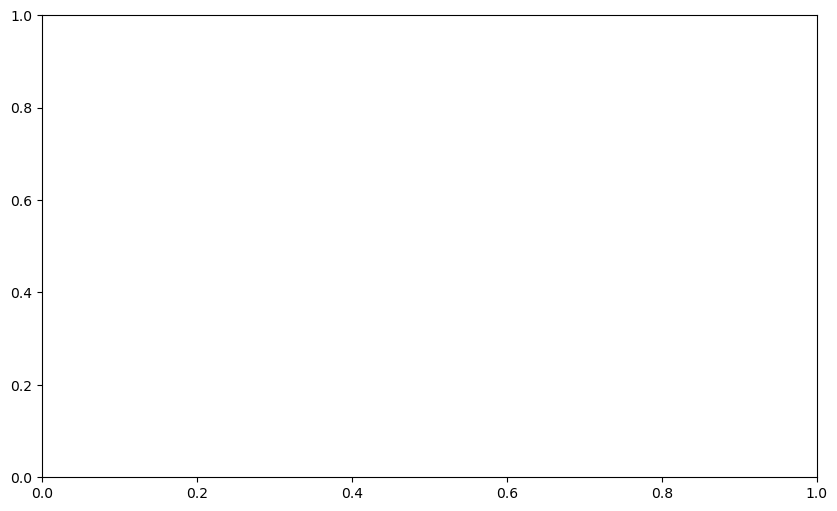

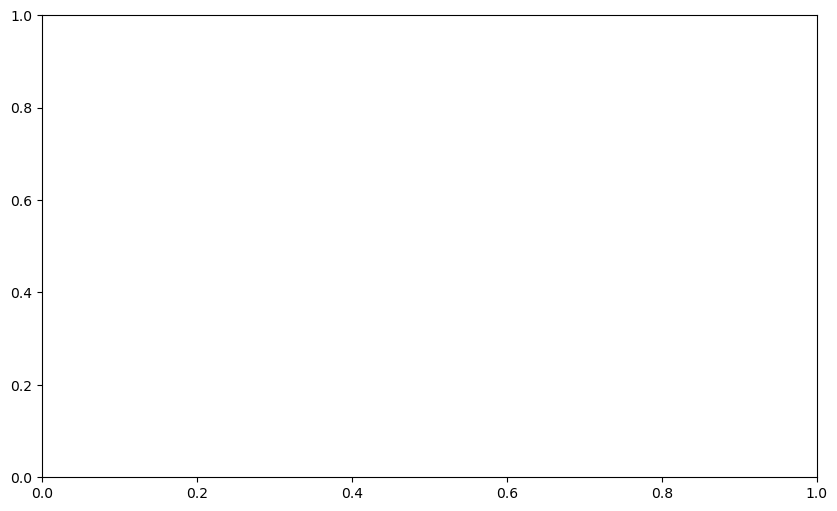

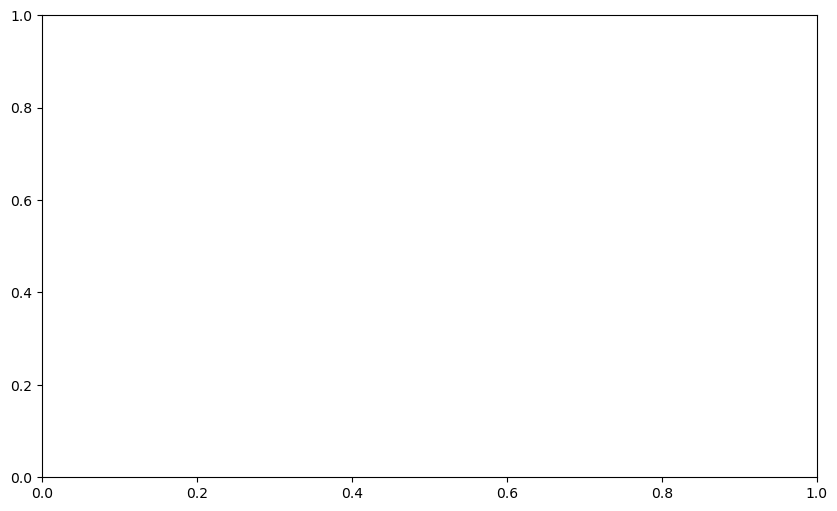

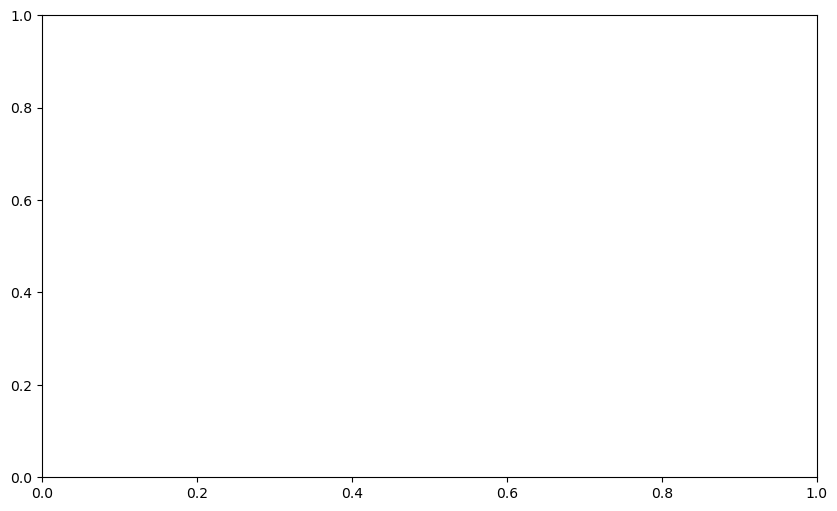

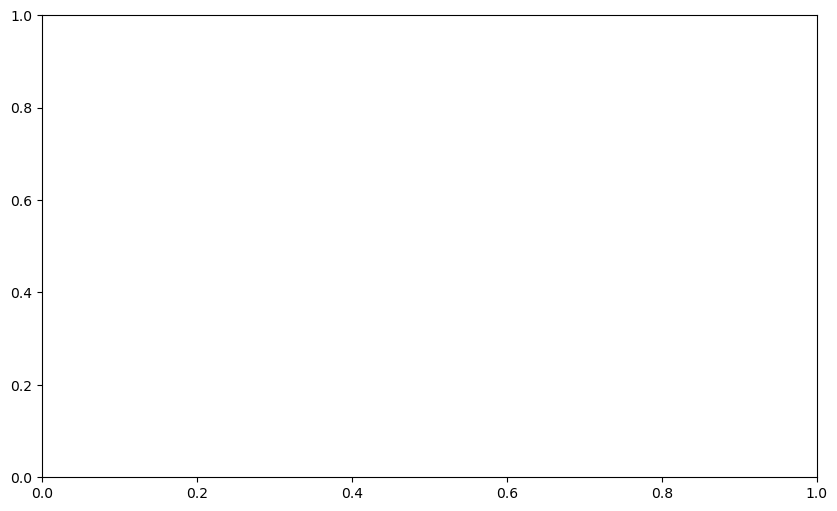

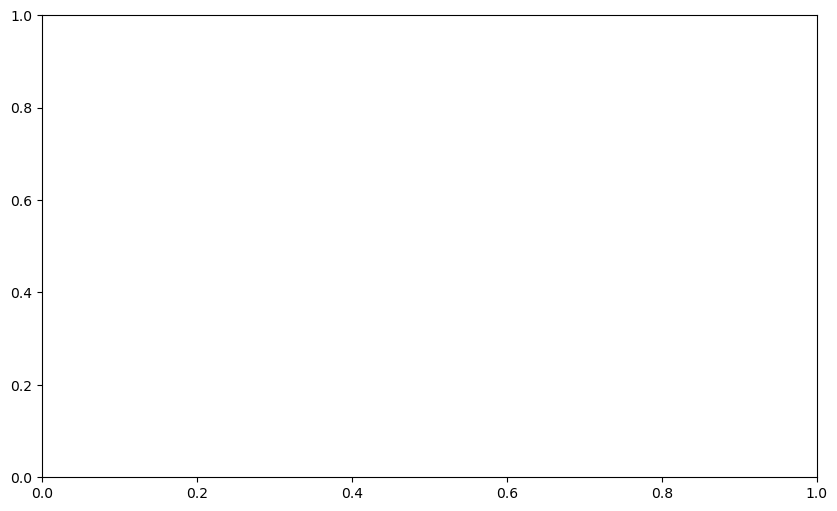

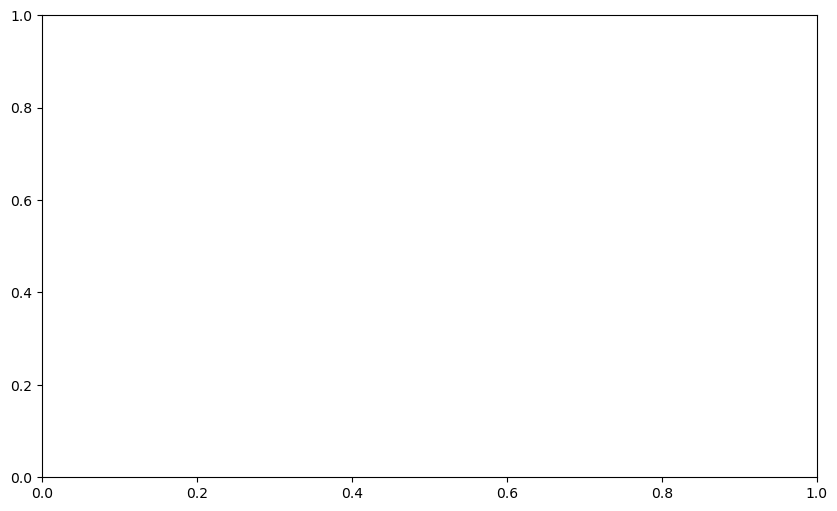

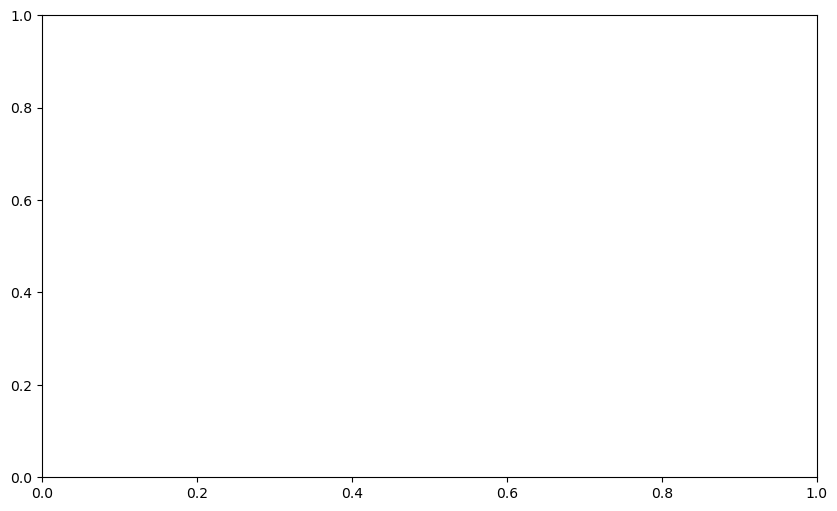

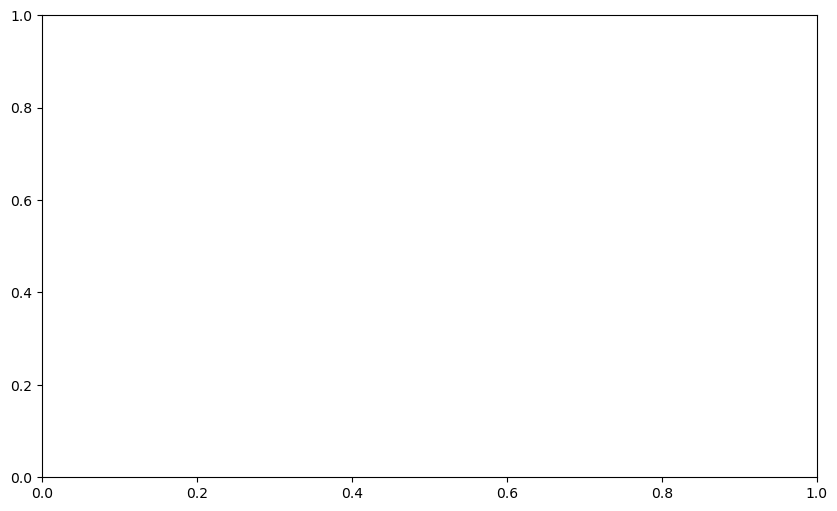

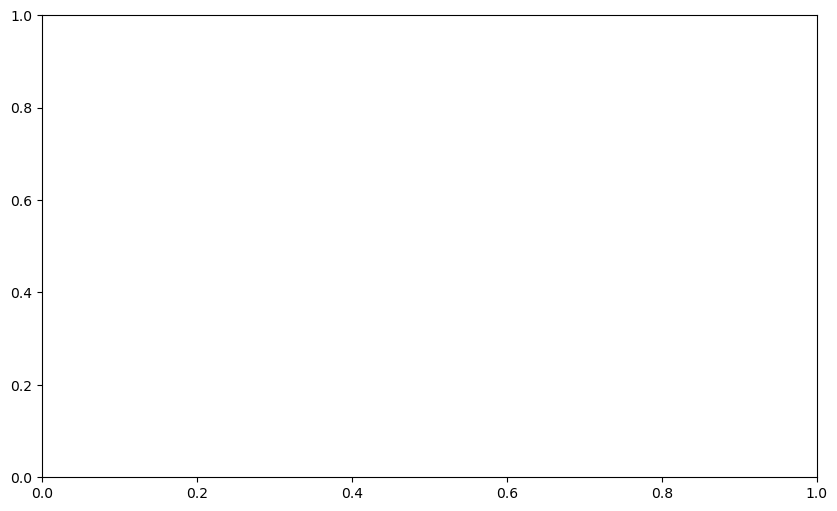

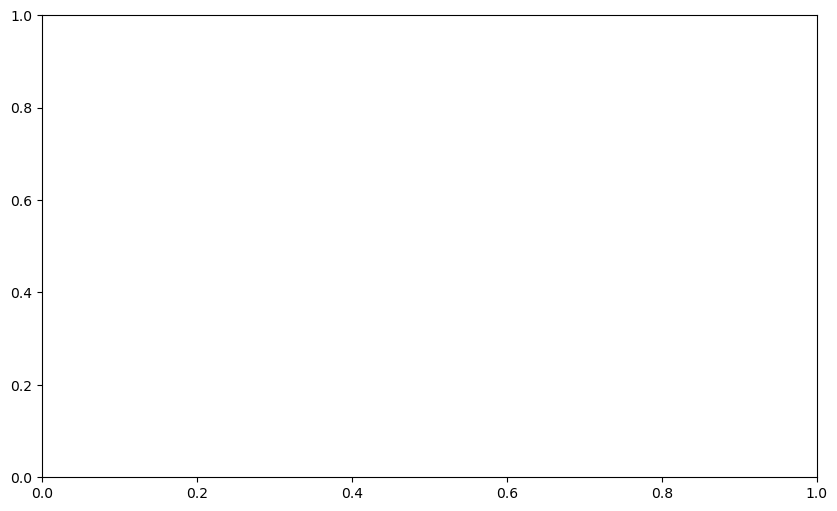

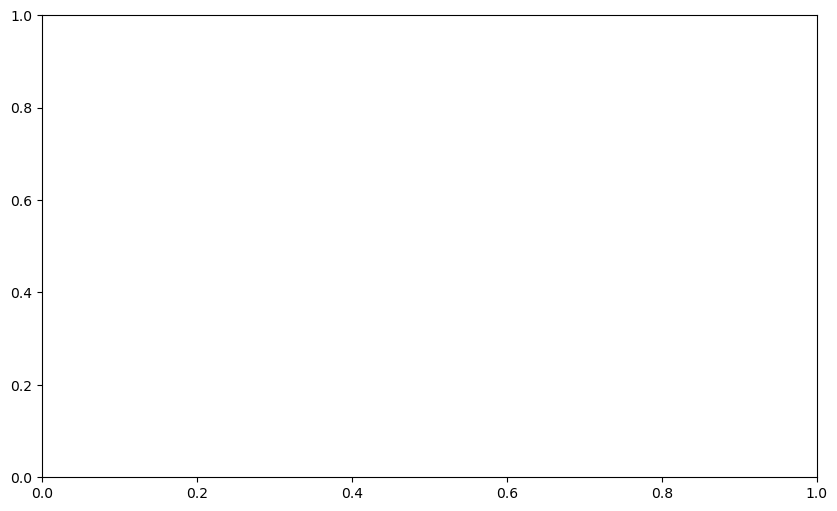

In [ ]:
# interactive plot

import copy

import ipywidgets
from ipywidgets import interact, FloatLogSlider, FloatSlider, SelectionRangeSlider, Select
from IPython.display import display

#TODO: A_V 用 range slider 选择多个；feedback method 可以多选；

def interactive_plot(*, n_0: float, gamma: float, A_V: float, opacity: OpacityData, T_floor: float = 30, T_sub: float = 1500, ):
    np.seterr(over='ignore', divide='ignore')  # 忽略 overflow 和 divide by zero 的警告

    observed_SED = SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest']).select_wavelength_range(max=8 * u.um)#.refine(100)
    model = A_V_Model(
        n_0=n_0 * u.cm**-3,
        gamma=gamma,
        T_sub=T_sub * u.K,
        A_V=A_V,
        opacity=opacity,
        observed_SED=observed_SED,
        tau_ph=0,
        config={'T_floor': T_floor * u.K}
        # config={'sigma_H_Prad_eff.method': 'max'}
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    # 模型结果
    lines = ax.loglog(model.opacity.wavelength, model.calc_nu_L_nu(), label='feedback: no')
    color = lines[0].get_color()

    model_SED_mean = copy.deepcopy(model)
    model_SED_mean.tau_ph = 1
    ax.loglog(model_SED_mean.opacity.wavelength, model_SED_mean.calc_nu_L_nu(), '--', label='feedback: SED-mean', color=color)

    model_Prad_max = copy.deepcopy(model)
    model_Prad_max.tau_ph = 1
    model_Prad_max.config['sigma_H_Prad_eff.method'] = 'max'
    ax.loglog(model_Prad_max.opacity.wavelength, model_Prad_max.calc_nu_L_nu(), '-.', label=r'feedback: $P_{\rm rad}$ max', color=color)

    # de-redden 入射光谱
    ax.plot(model.incident_SED.wavelength, model.incident_SED.nu_L_nu, '.-', label='incident SED', color=color, alpha=.5)


    # 观测数据
    ax.scatter('wavelength_rest', 'nu_L_nu', data=Labbe_photo, label='observed SED', color='k', s=10)

    # 设定坐标轴的范围
    ax.set_xlim(*[1e-1, 3e2] * u.um)
    ax.set_ylim(*[1e43, 3e46] * u.erg/u.s)

    # 坐标轴 label
    set_xylabel_with_unit(ax, xlabel=r"Rest-frame $\lambda$", ylabel=r"$\nu L_\nu$") 

    # 上方的 T 轴
    add_T_xaxis(ax, location='top')
    ax.axvline(wavelength_to_temperature(4 * model.T_out.to_value(u.K)), color='grey', alpha=.4, linestyle='--', label = r"$4 T_{\rm out}$")

    # 下方的观测波长轴
    add_wavelength_obs_xaxis(ax, z=Labbe_photo.meta['z'], location=-.15)

    # 添加图例
    ax.legend()
    ax.set_title(rf"{model_Prad_max:latex}")  # 标题
    
    # display(model)
    # return fig, ax
    
interact(interactive_plot, 
         n_0=FloatLogSlider(value=1e3, base=10, min=0, max=6, step=0.01, description='n_0'), 
         gamma=FloatSlider(value=0, min=0, max=2, step=0.01, description='gamma'),
         A_V=FloatSlider(value=1, min=0, max=4, step=0.1, description='A_V'),
         opacity=Select(options=opacity_dict,
                            description='Opacity',
                            disabled=False),
         T_floor=FloatSlider(value=30, min=0, max=100, step=1, description='T_floor'),
         T_sub=FloatSlider(value=1500, min=100, max=3000, step=1, description='T_sub'),
         )

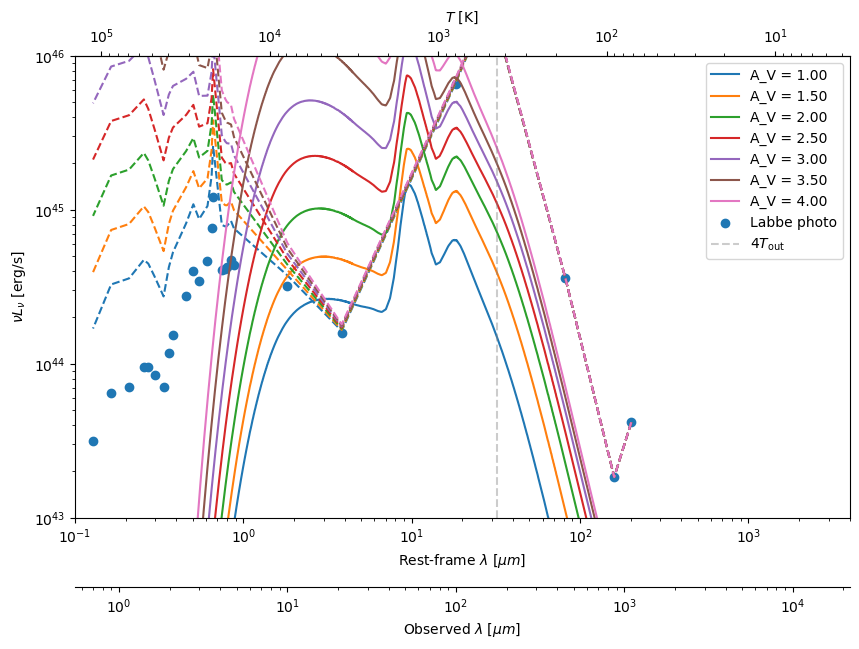

In [ ]:
# old plot

fig, ax = plt.subplots(figsize=(10, 6))

color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
for index, A_V in enumerate(np.arange(1, 4.5, .5)):
    model = A_V_Model(
        n_0=1e3 * u.cm**-3,
        gamma=0.5,
        T_sub=1500 * u.K,
        A_V=A_V,
        opacity=Orion_opacity,
        observed_SED=SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest']),
        tau_ph = 0,
    )

    nu_L_nu = model.calc_nu_L_nu(r_sample_num=1000)

    ax.loglog(Orion_opacity.wavelength, nu_L_nu, label=f'{A_V = :.2f}', color=color_cycle[index]) # IR 出射光谱
    
    ax.loglog(model.incident_SED.nu.to(u.um, u.spectral()), model.incident_SED.L_nu * model.incident_SED.nu, color=color_cycle[index], ls='--') #  de-reddened 入射光谱

#TEMP
ax.scatter('wavelength_rest', 'nu_L_nu', data=Labbe_photo, label='Labbe photo', )


# ax.set_yscale('linear')

# 设定坐标轴的范围
ax.set_xlim(*[1e-1, 4e3] * u.micron)
ax.set_ylim(*[1e43, 1e46] * u.erg/u.s)

# 坐标轴 label
ax.set_xlabel(r"Rest-frame $\lambda$ [$\mu m$]")
ax.set_ylabel(r"$\nu L_\nu \ [{\rm erg/s}]$")

# 上方的 T 轴
def convert_wavelength_to_temperature(x):
    from astropy.constants import c, h, k_B
    return (h * c / k_B).to_value(u.K * u.micron) / x

T_axis = ax.secondary_xaxis('top', functions=(convert_wavelength_to_temperature, convert_wavelength_to_temperature))
T_axis.set_xlabel(r"$T$ [K]")
ax.axvline(convert_wavelength_to_temperature(4 * model.T_out.to_value(u.K)), color='grey', alpha=.4, linestyle='--', label = r"$4 T_{\rm out}$")

z = Labbe_photo.meta['z']
T_axis = ax.secondary_xaxis(location=-.15, functions=(lambda x: x * (1+z), lambda x: x / (1+z)))
T_axis.set_xlabel(r"Observed $\lambda$ [$\mu m$]")

# 添加图例
ax.legend()
# ax.set_title(rf"{model:latex}")

## 草稿

### 检查能量平衡 Check Energy Balance

In [ ]:
op = OpacityData(nu=Orion_opacity.nu, 
                 sigma_H_ext=Orion_opacity.sigma_H_ext)

model = A_V_Model(
    n_0=1e3 * u.cm**-3,
    gamma=0.5,
    T_sub=1500 * u.K,
    A_V=3 * u.mag,
    opacity=op,
    observed_SED=SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest']),
    tau_ph=1
)
# model

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [ ]:
model.check_Luminosity()

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in 

{'calc_L_from_extinction': <Quantity 1.41609096e+46 erg / s>,
 'calc_L_from_UV_Flux': <Quantity 1.41609062e+46 erg / s>,
 'calc_L_from_UV_Flux_with_feedback': <Quantity 1.41609062e+46 erg / s>,
 'calc_L_from_IR_Flux': <Quantity 1.41609104e+46 erg / s>,
 'calc_L_from_L_nu': <Quantity 1.41609104e+46 erg / s>}

In [ ]:
# 验证 UV_Flux 和 IR_Flux 在各个 r 处都相等。没有 feedback 时成立，有 feedback 时不对
r_array = np.geomspace(model.r_in, model.r_out, 1000)
np.allclose(model.UV_Flux(r_array), model.IR_Flux(model.T_dust_profile(r_array)), rtol=1e-4, atol=0)

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


False

In [ ]:
np.allclose(model.UV_Flux_with_feedback(r_array), model.IR_Flux(model.T_dust_profile(r_array)), rtol=1e-4, atol=0)

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


True

### feedback 的 T_profile 

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in 

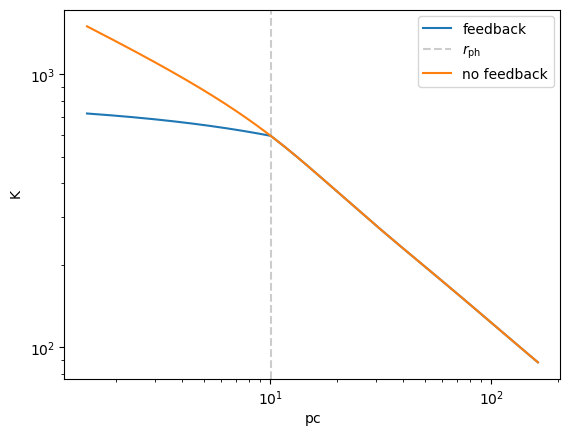

In [ ]:
model = A_V_Model(
    n_0=1e3 * u.cm**-3,
    gamma=0.5,
    T_sub=1500 * u.K,
    A_V=3.5,
    opacity=Orion_opacity,
    observed_SED=SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest']),
    # tau_ph=0,
)


r_array = np.geomspace(model.r_in, model.r_out, 1000)
plt.loglog(r_array, model.T_dust_profile(r_array), label='feedback')
plt.axvline(model.r_ph, color='grey', alpha=.4, linestyle='--', label = r"$r_{\rm ph}$")
model.tau_ph = 0
plt.loglog(r_array, model.T_dust_profile(r_array), label='no feedback')
plt.legend()

### "mean" dust attenuation

In [55]:
%matplotlib inline

Text(0.5, 1.0, '$$f_{\\rm scat} = 0.9$$')

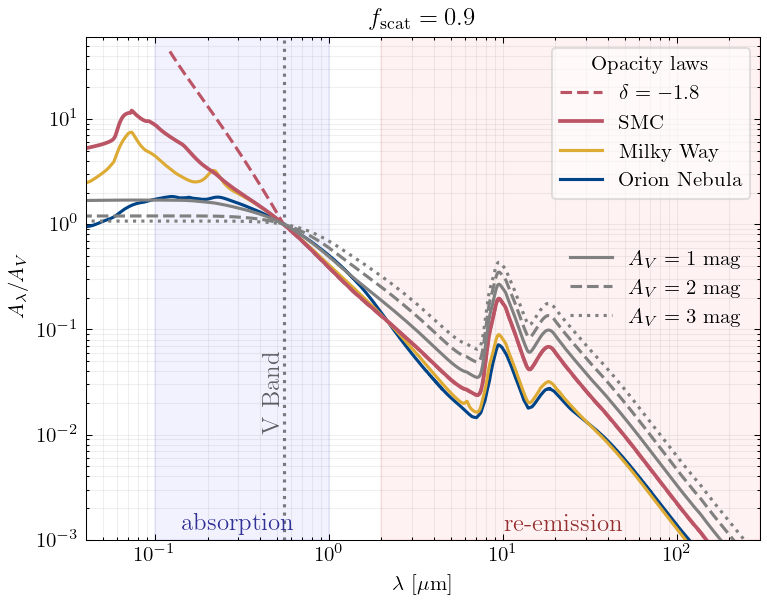

In [93]:


import scienceplots
plt.rcdefaults()
plt.style.use(['science', 'high-contrast',])
plt.rcParams['lines.linewidth'] = 1.5

fig, ax = plt.subplots(figsize=np.array([4,3])*1.45, dpi=150)
    
for opacity_name, opacity in opacity_dict.items():
    _props = dict()
    if opacity_name == 'super SMC':  # 对于 super SMC 特殊处理
        _props['linestyle'] = '--'
        _props['color'] = _line.get_color()  # 使用上一条线的颜色

    _line, = ax.loglog(opacity.wavelength, opacity.sigma_H_ext / opacity.sigma_H_ext_V, label=opacity_display_names[opacity_name], **_props)
    
    if opacity_name == 'SMC':  # SMC 线悄悄加粗一些，因为这是 fiducial case
        _line.set_linewidth(_line.get_linewidth() * 1.2) 
    
# 标记 V band
ax.axvline(5470 * u.AA, linestyle=':', color='k', alpha=.5)  
ax.text(5470 * u.AA, 1e-2, 'V Band', ha='right', va='bottom', rotation=90, fontsize=12, alpha=.6)  # V band 竖线附近的文字
# ax.scatter(5470 * u.AA, 1, marker='.', color='k', s=100, label='V Band', zorder=100)

# 标记 absorption 和 re-emission 的范围
ax.axvspan(1e-1 * u.um, 1e0 * u.um, color='blue', alpha=0.05)
ax.axvspan(2 * u.um, 3e2 * u.um, color='red', alpha=0.05)

ax.text(3e-1 * u.um, 1.1e-3, 'absorption', ha='center', va='bottom', fontsize=12, alpha=1, color='#303095', zorder=100)
ax.text(2.2e1 * u.um, 1.1e-3, 're-emission', ha='center', va='bottom', fontsize=12, alpha=1, color='#953030', zorder=100)



# 右边的 y 轴显示 sigma_H_ext
if False:
    def _A_rel_to_sigma_H(A_rel: float) -> float:
        return A_rel * Orion_opacity.sigma_H_ext_V.cgs.value
    def _sigma_H_to_A_rel(sigma_H: float) -> float:
        return sigma_H / Orion_opacity.sigma_H_ext_V.cgs.value
    yaxis_2 = ax.secondary_yaxis('right', functions=(_A_rel_to_sigma_H, _sigma_H_to_A_rel))
    yaxis_2.set_ylabel(r"$\sigma_\nu^{\rm ext}$ [${\rm cm^2}$]")

ax.grid(which='both', lw=.5, alpha=0.2)

ax.set_xlim(*[4e-2, 3e2] * u.um)
ax.set_ylim(1e-3, 60)

set_xylabel_with_unit(ax, xlabel=r'$\lambda$', ylabel=r'$A_\lambda/A_V$')
ax.add_artist(ax.legend(handles=ax.get_legend_handles_labels()[0][::-1], title='Opacity laws', framealpha=.6, frameon=True))

ax.get_legend()

# fig.savefig('figures/opacity_laws/opacity_laws_4.pdf', bbox_inches='tight')
# fig

# plt.rcdefaults()
opacity = SMC_opacity
# fig, ax = plt.subplots()
f_scat=9e-1
_lines = []
for A_V, ls in zip([1,2,3], ['-', '--', ':']):
    _lines += ax.loglog(opacity.wavelength, 
              np.log10(f_scat + (1-f_scat) * 10**(-0.4*opacity.A_rel*A_V)) / np.log10(f_scat + (1-f_scat) * 10**(-0.4*A_V)), 
              ls=ls, color='.5', label=f'$A_V={A_V}$ mag' ) 
ax.legend(handles=_lines, loc='right')
ax.set_title(rf"$$f_{{\rm scat}} = {f_scat}$$")




In [66]:
plt.rcdefaults()
opacity = SMC_opacity
# fig, ax = plt.subplots()
for A_V, ls in zip([1,2,3], ['-', '--', ':']):
    for f_scat, color in zip([1e-2,1e-1,0.9], plt.rcParams['axes.prop_cycle']):
        ax.loglog(opacity.wavelength, np.log10(f_scat + (1-f_scat) * 10**(-0.4*opacity.A_rel*A_V)) / np.log10(f_scat + (1-f_scat) * 10**(-0.4*A_V)), ls=ls, color=color['color']) 


ax.set_xlim(*[4e-2, 3e2] * u.um)
ax.set_ylim(1e-3, 60)


(0.001, 60)

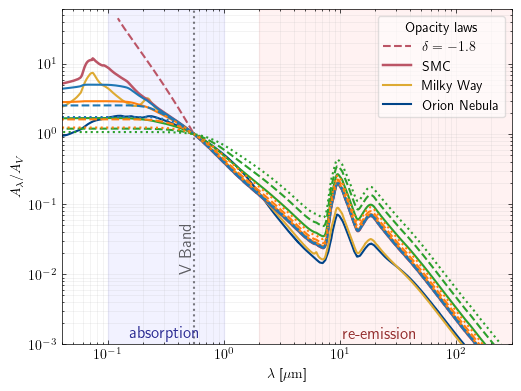

In [67]:
fig

In [73]:
list(plt.rcParams['axes.prop_cycle'])

[{'color': '#1f77b4'},
 {'color': '#ff7f0e'},
 {'color': '#2ca02c'},
 {'color': '#d62728'},
 {'color': '#9467bd'},
 {'color': '#8c564b'},
 {'color': '#e377c2'},
 {'color': '#7f7f7f'},
 {'color': '#bcbd22'},
 {'color': '#17becf'}]

In [82]:
A_V

NameError: name 'A_V' is not defined

## 临时测试

### mag

### 图例

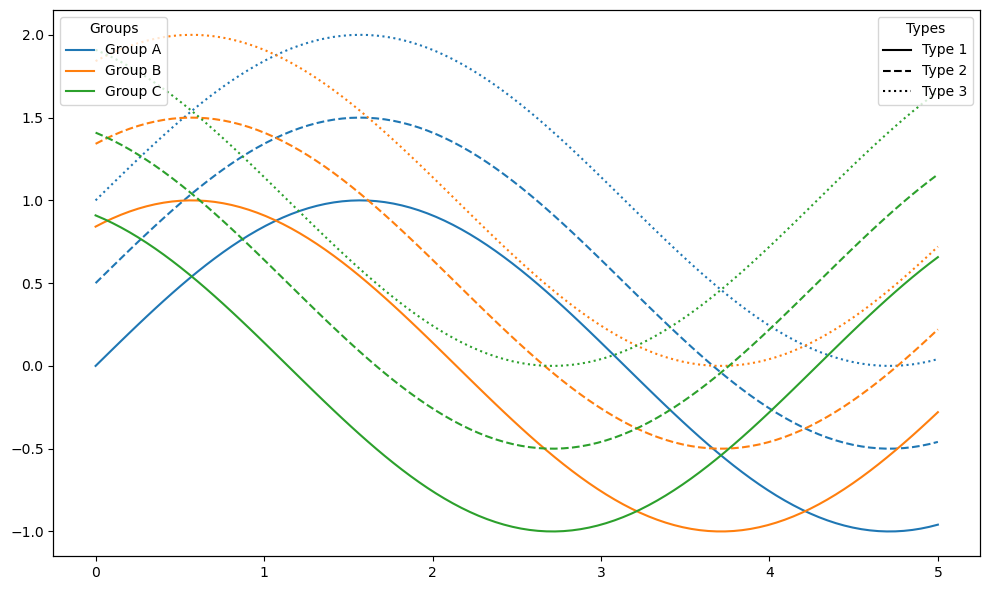

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# 创建图表
fig, ax = plt.subplots(figsize=(10, 6))

# 定义分组和类型
groups = ['Group A', 'Group B', 'Group C']
types = ['Type 1', 'Type 2', 'Type 3']

# 定义样式
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
linestyles = ['-', '--', ':']

# 生成数据并绘图
x = np.linspace(0, 5, 100)
lines = []

for g_idx, group in enumerate(groups):
    group_lines = []
    for t_idx, type_name in enumerate(types):
        y = np.sin(x + g_idx) + t_idx * 0.5
        contour_multiline, = ax.plot(x, y, color=colors[g_idx], linestyle=linestyles[t_idx])
        group_lines.append(contour_multiline)
    lines.append(group_lines)

# 创建自定义图例 - 分成两部分
# 1. 组别图例
group_handles = [mlines.Line2D([], [], color=color, linestyle='-', 
                              label=group) for color, group in zip(colors, groups)]
# 2. 类型图例
type_handles = [mlines.Line2D([], [], color='black', linestyle=ls, 
                             label=type_name) for ls, type_name in zip(linestyles, types)]

# 添加两组图例
ax.legend(handles=group_handles, loc='upper left', title='Groups')
# 添加第二个图例框
ax2 = ax.twinx()
ax2.set_yticks([])
ax2.legend(handles=type_handles, loc='upper right', title='Types')

plt.tight_layout()

In [ ]:
group_handles

### 求根

In [ ]:
from functools import lru_cache
# @lru_cache(maxsize=None)
# @MyCache
def test_diff(A_V:float):
    original_SED= SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest'])
    
    observed_SED = original_SED.select_wavelength_range(max=8 * u.um)#.refine(100)
    model = A_V_Model(
        n_0=1e3 * u.cm**-3,
        gamma=0.,
        T_sub=1500 * u.K,
        A_V=A_V,
        opacity=Orion_opacity,
        observed_SED=observed_SED,
        tau_ph=1,
        # config={'sigma_H_Prad_eff.method': 'max'}
    )
    
    diff = model.calc_nu_L_nu(original_SED.nu) - original_SED.nu_L_nu
    index = np.argmax(diff) 
    return index, diff[index]

# test_diff(1.96)

In [ ]:
model = A_V_Model(
    n_0=1e3 * u.cm**-3,
    gamma=0.,
    T_sub=1500 * u.K,
    A_V=1,
    opacity=Orion_opacity,
    observed_SED=observed_data,
    tau_ph=1,
    # config={'sigma_H_Prad_eff.method': 'max'}
)
model

In [ ]:
%timeit model.calc_nu_L_nu()

274 ms ± 9.12 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
from functools import wraps

class CacheKey:
    def __init__(self, args, kwargs):
        self.args = args
        self.kwargs = frozenset(kwargs.items())
        
    def __hash__(self):
        return hash((self.args, self.kwargs))
    
    def __eq__(self, other):
        return (self.args == other.args) and (self.kwargs == other.kwargs)
    
    def __repr__(self):
        return f"CacheKey(args={self.args}, kwargs={dict(self.kwargs)})"

class MyCache:
    def __init__(self, func):
        self.cache = {}
        self.func = func
        
    def __call__(self, *args, **kwargs):
        key = CacheKey(args=args, kwargs=kwargs)
        if key not in self.cache:
            self.cache[key] = self.func(*args, **kwargs)
        return self.cache[key]
    
@MyCache
def foo(x, y):
    print(f"Calculating {x} + {y}")
    return x + y
        
foo(1, 2)


Calculating 1 + 2


3

In [ ]:
list(test_diff.cache)[0].args[0]

1.96

In [ ]:
test_diff(res.root)

(np.int64(5), <Quantity 7.98223737e+30 erg / s>)

In [ ]:
test_diff(res.root - 1e-3)

(np.int64(5), <Quantity -5.25387525e+41 erg / s>)

In [ ]:
res = optimize.root_scalar(lambda A_V: test_diff(A_V)[1].value, bracket=[0, 4.4], method='brentq', xtol=1e4)
res

      converged: True
           flag: converged
 function_calls: 2
     iterations: 1
           root: 0.0
         method: brentq

In [ ]:
[[k.args[0],v[1]] for k,v in test_diff.cache.items()]

[[0.0, <Quantity -1.83670443e+43 erg / s>],
 [4.0, <Quantity 1.66264887e+46 erg / s>],
 [0.0044138668648726065, <Quantity -1.83667197e+43 erg / s>],
 [2.0022069334324364, <Quantity 2.18662033e+43 erg / s>],
 [0.9164257831349736, <Quantity -1.83151038e+43 erg / s>],
 [1.459316358283705, <Quantity -1.8293191e+43 erg / s>],
 [1.7307616458580708, <Quantity -1.8278775e+43 erg / s>],
 [1.8664842896452536, <Quantity -1.82692306e+43 erg / s>],
 [1.9343456115388449, <Quantity -1.44575115e+43 erg / s>],
 [1.9682762724856406, <Quantity 2.78586592e+42 erg / s>],
 [1.96279438400392, <Quantity -1.20289064e+41 erg / s>],
 [1.9630212856097766, <Quantity -9.38018422e+38 erg / s>],
 [1.9630230683025536, <Quantity 1.22265495e+34 erg / s>],
 [1.9630230682793175, <Quantity -1.78263366e+29 erg / s>],
 [1.9630230682803185, <Quantity 5.2647114e+32 erg / s>]]

In [ ]:
abs(y).min()

<Quantity 1.78263366e+29 erg / s>

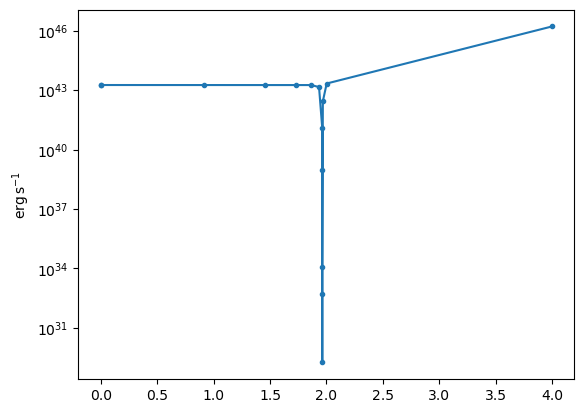

In [ ]:
x,y = zip(*sorted(_315))
y = u.Quantity(y)
plt.plot(x, abs(y), '.-')
plt.yscale('log')
# plt.yscale('symlog', linthresh=1e27)

In [ ]:
test_diff(res.root - 1e-13)

(np.int64(5), <Quantity -4.44866133e+31 erg / s>)

In [ ]:
res.items()

dict_items([('root', 1.9600000000000002), ('iterations', 3), ('function_calls', 4), ('converged', True), ('flag', 'converged'), ('method', 'brentq')])

In [ ]:
max(test_diff(1.))

<Quantity -1.83114999e+43 erg / s>

In [ ]:
u.Quantity([test_diff() for A_V in A_V_list])

<Quantity [-1.83353705e+43, -1.83226914e+43, -1.83114999e+43,
           -1.83013452e+43, -1.82914063e+43, -1.82775210e+43,
            2.05661895e+43,  2.33883122e+44,  6.41488231e+44,
            1.36060026e+45,  2.54254910e+45,  4.37646702e+45,
            7.10262836e+45,  1.10395145e+46,  1.66264887e+46,
            2.44848074e+46] erg / s>

In [ ]:
u.Quantity([test_diff(A_V)[1] for A_V in A_V_list])

<Quantity [-1.83599054e+43, -1.83531989e+43, -1.83468944e+43,
           -1.83409616e+43, -1.83353705e+43, -1.83300911e+43,
           -1.83250936e+43, -1.83203487e+43, -1.83158271e+43,
           -1.83114999e+43, -1.83073385e+43, -1.83033145e+43,
           -1.82993998e+43, -1.82955669e+43, -1.82914063e+43,
           -1.82864670e+43, -1.82807140e+43, -1.82741105e+43,
           -1.82666178e+43,  2.05661895e+43,  8.86708678e+43,
            1.78830828e+44,  2.96598490e+44,  4.48388506e+44,
            6.41488231e+44,  8.84050446e+44,  1.18509316e+45,
            1.55450298e+45,  2.00306790e+45,  2.54254910e+45,
            3.18579214e+45,  3.94690290e+45,  4.84147867e+45,
            5.88688427e+45,  7.10262836e+45,  8.51075969e+45,
            1.01363604e+46,  1.20081013e+46,  1.41588620e+46,
            1.66264887e+46,  1.94545775e+46,  2.26934716e+46,
            2.64013345e+46,  3.06454253e+46] erg / s>

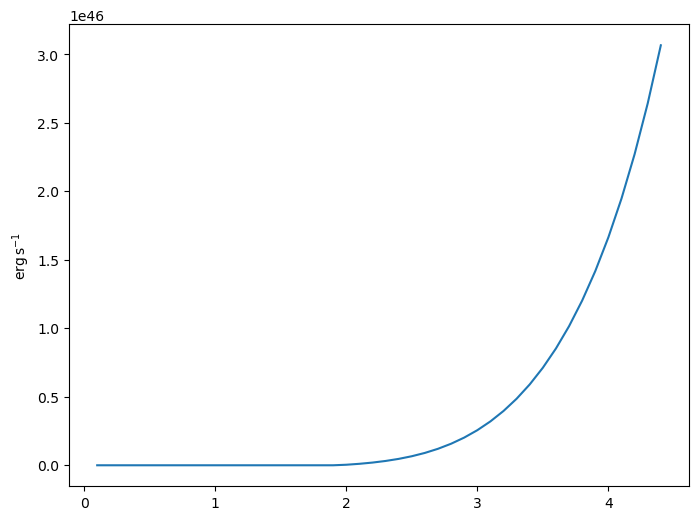

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
A_V_list = np.arange(.1, 4.5, .1)
ax.plot(A_V_list, u.Quantity([test_diff(A_V)[1] for A_V in A_V_list]))
# ax.set_yscale('symlog', linthresh=1e40)

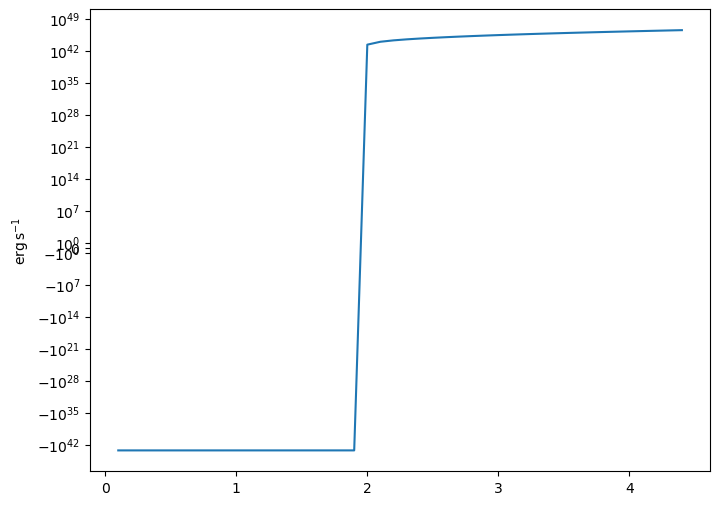

In [ ]:
ax.set_yscale('symlog', linthresh=1e0)
fig

### 参数空间 A_V 限制

In [ ]:
test_diff(n_0=1e0 * u.cm**-3, gamma=.9, A_V=0.3)

(np.int64(1), np.float64(49.454100257902475))

In [ ]:
create_model_with_fiducial(n_0=1e0 * u.cm**-3, gamma=.99, A_V=0.3)

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in subtract
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:482: RuntimeWarning: invalid value encountered in subtract
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


In [ ]:
calc_A_V_max_for_paras(n_0=1e0 * u.cm**-3, gamma=0.9)

Error: f(a) and f(b) must have different signs. n_0 = 1.0 1 / cm3, gamma = 0.9, A_V in [1.0, 6]


(      converged: True
            flag: converged
  function_calls: 10
      iterations: 9
            root: 0.0007607595380685585
          method: brentq,
 np.int64(1),
 np.float64(0.0030612254860820087),
 CacheInfo(hits=3, misses=16, maxsize=128, currsize=16))

In [ ]:
# def mock_calc_A_V_max(n_0, gamma):
#     import time
#     time.sleep(1)
#     return np.log10(n_0) * np.sin(2 * np.pi * gamma )

# calc_A_V_max = mock_calc_A_V_max

<BarContainer object of 10 artists>

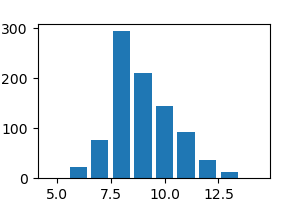

In [ ]:
function_calls_list = [res.function_calls for res in res_list]
from collections import Counter

function_calls_counter = Counter(function_calls_list)
plt.subplots(figsize=(3, 2))
plt.bar(function_calls_counter.keys(), function_calls_counter.values())

In [ ]:
np.unique(np.asarray(crit_index_list))

In [ ]:
# A_V_max_array, function_calls_array, converged_array = np.vectorize(lambda res: (res.root, res.function_calls, res.converged))(root_result_array)

In [ ]:
# 重新计算？
index_diff_array = Parallel()(
    delayed(test_diff)(gamma=gamma, n_0=n_0, A_V=A_V) for gamma, n_0, A_V in zip(X.flat, Y.flat, A_V_max_array.flat)
)
    

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   2 out of   6 | elapsed:    2.4s remaining:    4.8s
[Parallel(n_jobs=10)]: Done   3 out of   6 | elapsed:    2.4s remaining:    2.4s
[Parallel(n_jobs=10)]: Done   4 out of   6 | elapsed:    2.5s remaining:    1.2s
[Parallel(n_jobs=10)]: Done   6 out of   6 | elapsed:    2.5s finished


In [ ]:
index_diff_array = Parallel()(
    delayed(test_diff)(gamma=gamma, n_0=n_0, A_V=A_V) for gamma, n_0, A_V in zip(X.flat, Y.flat, A_V_max_list)
)
    

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   2 out of   6 | elapsed:    0.4s remaining:    0.8s
[Parallel(n_jobs=10)]: Done   3 out of   6 | elapsed:    0.4s remaining:    0.4s
[Parallel(n_jobs=10)]: Done   4 out of   6 | elapsed:    0.4s remaining:    0.2s
[Parallel(n_jobs=10)]: Done   6 out of   6 | elapsed:    1.2s finished


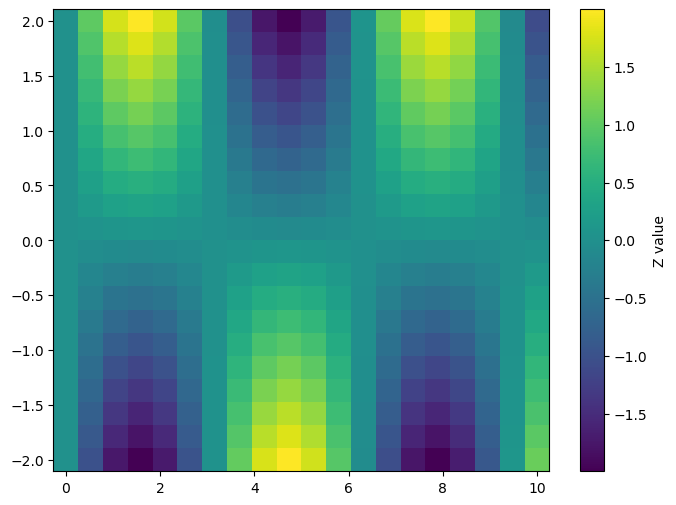

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 示例数据
x = np.linspace(0, 10, 20)
y = np.geomspace(1e-2, 1e2, 20)  # 确保 y 是正值
X, Y = np.meshgrid(x, y)
Z = np.sin(X) * np.log10(Y)

# 创建图像
fig, ax = plt.subplots(figsize=(8, 6))
p = ax.pcolormesh(X, np.log10(Y), Z, shading='auto', cmap='viridis')

# 设置 y 轴为对数刻度
# ax.set_yscale('log')

# 添加颜色条
cbar = fig.colorbar(p, ax=ax)
cbar.set_label('Z value')

# 显示图像
plt.show()

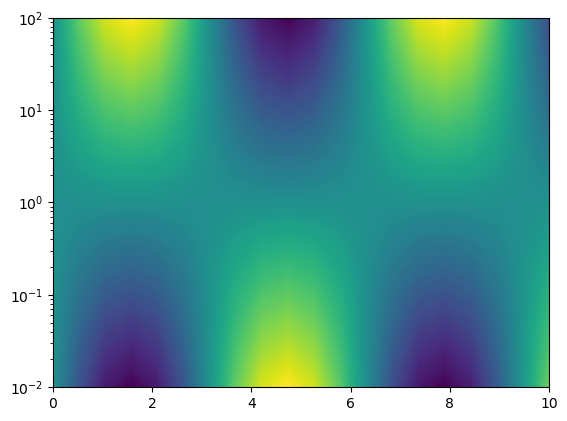

In [ ]:
plt.contourf(X, Y, Z, levels=100, cmap='viridis')
plt.yscale('log')

### idea： 直接积分限制

In [ ]:
observed_SED = SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest'])
model = A_V_Model(
    n_0=1e4 * u.cm**-3,
    gamma=0.,
    T_sub=1500 * u.K,
    A_V=1,
    opacity=Orion_opacity,
    observed_SED=observed_SED,
    tau_ph=1
)

In [ ]:
def calc_L_from_SED(sed: SED):
    return trapz_log(sed.L_nu, sed.nu)

A_V_list = np.arange(0, 4.5, .5)
[calc_L_from_SED(de_redden_SED(observed_SED=observed_SED.select_wavelength_range(max=8 * u.um).refine(100), A_V=3, opacity=Orion_opacity), ).cgs for A_V in A_V_list]



[<Quantity 1.46244313e+46 erg / s>,
 <Quantity 1.46244313e+46 erg / s>,
 <Quantity 1.46244313e+46 erg / s>,
 <Quantity 1.46244313e+46 erg / s>,
 <Quantity 1.46244313e+46 erg / s>,
 <Quantity 1.46244313e+46 erg / s>,
 <Quantity 1.46244313e+46 erg / s>,
 <Quantity 1.46244313e+46 erg / s>,
 <Quantity 1.46244313e+46 erg / s>]

In [ ]:
observed_SED = SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest'])
model = A_V_Model(
    n_0=30 * u.cm**-3,
    gamma=0.,
    T_sub=1500 * u.K,
    A_V=1.0,
    opacity=Orion_opacity,
    observed_SED=observed_SED.select_wavelength_range(max=8 * u.um).refine(100),
    tau_ph=0
)

In [ ]:
from astropy.constants import m_p

In [ ]:
r_array = model.get_r_array()
(trapz_log(model.n_profile(r_array) * 4 * np.pi * r_array **2, r_array).cgs * m_p).to(u.Msun) / 100 * 1e3

<Quantity 5.96712179e+08 solMass>

In [ ]:
(model.n_0 * 4 * np.pi * model.r_out**3 / 3 * m_p).to(u.Msun)

<Quantity 9.32381262e+08 solMass>

In [ ]:
model

In [ ]:
m_p

<<class 'astropy.constants.codata2018.CODATA2018'> name='Proton mass' value=1.67262192369e-27 uncertainty=5.1e-37 unit='kg' reference='CODATA 2018'>

In [ ]:
observed_SED = SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest'])
model = A_V_Model(
    n_0=30 * u.cm**-3,
    gamma=0.,
    T_sub=1500 * u.K,
    A_V=2,
    opacity=Orion_opacity,
    observed_SED=observed_SED,
    tau_ph=1
)

In [ ]:
model.check_Luminosity()

{'calc_L_from_extinction': <Quantity 4.59349073e+45 erg / s>,
 'calc_L_from_UV_Flux': <Quantity 4.59348995e+45 erg / s>,
 'calc_L_from_UV_Flux_with_feedback': <Quantity 4.59348995e+45 erg / s>,
 'calc_L_from_IR_Flux': <Quantity 4.59355818e+45 erg / s>,
 'calc_L_from_L_nu': <Quantity 4.59355818e+45 erg / s>}

### 加速：IR_Flux

In [ ]:
model = create_model_with_fiducial(A_V=1, opacity=Orion_opacity)

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [ ]:
model = create_model_with_fiducial(A_V=1,)

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [ ]:
np.seterr(over='ignore', divide='ignore')  # 忽略 overflow 和 divide by zero 的警告

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [ ]:
%load_ext viztracer

In [ ]:
%%viztracer --port 8888
model.calc_nu_L_nu()

Button(description='VizTracer Report', style=ButtonStyle())

In [ ]:
%timeit model.calc_nu_L_nu()

36.1 ms ± 1.57 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
%timeit model.calc_nu_L_nu()

15.9 ms ± 521 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
%timeit model.calc_nu_L_nu()

257 ms ± 9.25 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%timeit model.calc_nu_L_nu()

111 ms ± 2.99 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
%timeit model.calc_nu_L_nu()

92.1 ms ± 2.1 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
%%timeit
calc_A_V_max(n_0=1e3 * u.cm**-3, gamma=0.5)

126 ms ± 315 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
0.1 * u.s * 10 * 100*10 / 5 << u.min

<Quantity 3.33333333 min>

In [ ]:
0.1 * u.s * 10 * 100*100 / 5 << u.min

<Quantity 33.33333333 min>

In [ ]:
r_arr = model.get_r_array()
mat = (Orion_opacity.nu[:, None] * r_arr)

In [ ]:
%timeit mat * r_arr * 4 * np.pi * r_arr**2
%timeit mat * (r_arr * 4 * np.pi * r_arr**2)
%timeit mat * (r_arr * (4 * np.pi) * r_arr**2)

28.9 ms ± 2.15 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
7.57 ms ± 463 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
7.34 ms ± 343 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
%timeit (r_arr * r_arr**2)
%timeit (r_arr * 4 * np.pi * r_arr**2)
%timeit (r_arr * r_arr**2) * (4 * np.pi)
%timeit (r_arr * (4 * np.pi) * r_arr**2)

14.2 μs ± 153 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
22.3 μs ± 261 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
17.9 μs ± 83.8 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
18 μs ± 101 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


### 迭代满足 MIRI 约束

In [ ]:
Labbe_SED  # 观测约束

In [ ]:
import copy
SED_ext = copy.deepcopy(Labbe_SED)

In [ ]:
paras = dict(n_0=1e3 * u.cm**-3, gamma=0.5)
for i in range(3):
    A_V = calc_A_V_max_for_paras(**paras, SED_limit=SED_limit, SED_ext)[0].root
    model = create_model_with_fiducial(**paras, A_V=A_V, observed_SED=SED_ext)
    L_nu_re_emit = model.calc_L_nu(Labbe_SED.nu)
    SED_ext = SED(nu=Labbe_SED.nu, L_nu=SED_ext.L_nu - L_nu_re_emit)

### Spectrum

In [ ]:
furtak24 = QTable.read('data/observed_spectrum/furtak24_spectrum.txt', format='ascii', names=['wavelength_obs', 'wavelength_rest', 'flam', 'flam_err'], units=[u.um, u.AA, 1e-20 * u.g/u.s**2, 1e-20 * u.g/u.s**2],
            )


In [ ]:
u.Jy.cgs

Unit("1e-23 g / s2")

In [ ]:
furtak24

wavelength_obs,wavelength_rest,flam,flam_err
um,Angstrom,1e-20 g / s2,1e-20 g / s2
float64,float64,float64,float64
0.58,721.3930348258707,0.0,0.015565892280160724
0.5825795760027304,724.6014626899631,0.0,0.015428350535887606
0.5851921677748343,727.8509549438238,0.0,0.015290898237843603
0.5878386625732493,731.1426151408575,0.0,0.015153526568325177
0.5905195003500588,734.4769904851479,0.0,0.015016251054838085
0.5932355853927922,737.8552057124282,0.0,0.014879064246108669
0.595987410881779,741.2778742310684,0.0,0.014741980604041886
0.5987758961884396,744.7461395378604,0.0,0.01460499420380492


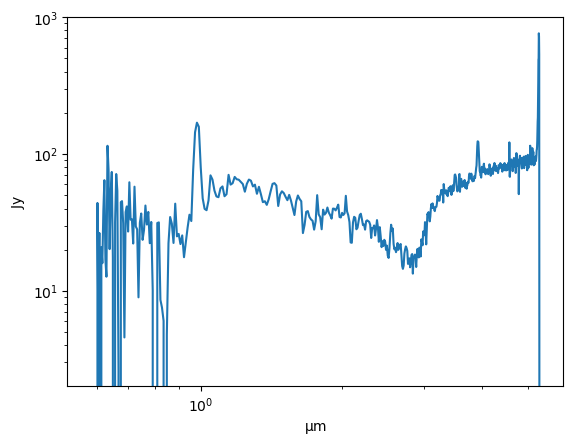

In [ ]:
plt.loglog('wavelength_obs', 'flam', data=furtak24)
plt.gca().yaxis.set_units(u.Jy)

In [ ]:
spec_dict = {file.stem: QTable.read(file) for file in Path('data/observed_spectrum').glob('*.spec.fits')}

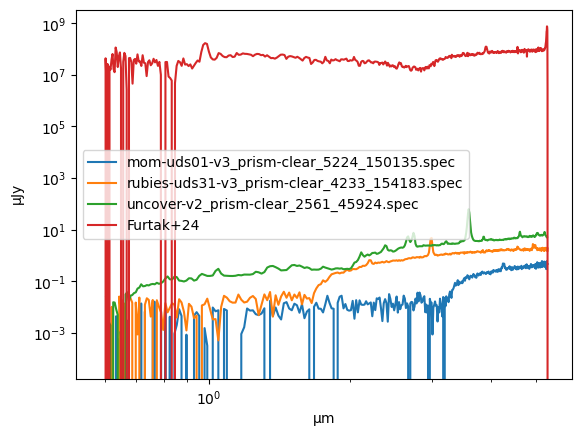

In [ ]:
for name, observed_flux in spec_dict.items():
    plt.loglog('wave', 'flux', data=observed_flux, label=name)
    
plt.loglog('wavelength_obs', 'flam', data=furtak24, label='Furtak+24')
plt.legend()

In [ ]:
spec_dict.keys()

dict_keys(['mom-uds01-v3_prism-clear_5224_150135.spec', 'rubies-uds31-v3_prism-clear_4233_154183.spec', 'uncover-v2_prism-clear_2561_45924.spec'])

In [ ]:
spec_dict['uncover-v2_prism-clear_2561_45924.spec']

wave,flux,err,path_corr
um,uJy,uJy,
float64,float64,float64,float64
0.58,———,inf,1.28
0.5836851085753291,———,inf,1.28
0.5874378771811705,———,inf,1.28
0.591260215571612,———,inf,1.28
0.5951542612478814,———,inf,1.28
0.5991219350103587,———,inf,1.28
0.6031652486825945,———,0.015416562948052362,1.28
0.6072866429848921,———,0.01399089040930812,1.27


In [ ]:
spec_dict['uncover-v2_prism-clear_2561_45924.spec']

wave,flux,err,path_corr
um,uJy,uJy,
float64,float64,float64,float64
0.58,———,inf,1.28
0.5836851085753291,———,inf,1.28
0.5874378771811705,———,inf,1.28
0.591260215571612,———,inf,1.28
0.5951542612478814,———,inf,1.28
0.5991219350103587,———,inf,1.28
0.6031652486825945,———,0.015416562948052362,1.28
0.6072866429848921,———,0.01399089040930812,1.27


### T_sub 的影响

In [ ]:
calc_A_V_max_for_paras(n_0=1e3 * u.cm**-3, gamma=0.5, model_factory=partial(create_model_with_fiducial, T_sub=2000*u.K))

(0.6113186635643438,
       converged: True
            flag: converged
  function_calls: 8
      iterations: 7
            root: 0.6113186635643438
          method: brentq,
 <Constraint.RE_EMISSION: 1>,
 np.int64(5),
 np.float64(0.00021791048231278864))

In [ ]:
partial(create_model_with_fiducial, T_sub=1500*u.K)(A_V=1)

In [ ]:
calc_A_V_max_array_in_paras_space()

TypeError: calc_A_V_max_array_in_paras_space() missing 5 required keyword-only arguments: 'observed_data_table', 'opacity', 'n_0_array', 'gamma_array', and 'model_factory_kwargs'

### debug

In [ ]:
A_V_max_array.max()

np.float64(2.6935276035111433)

In [ ]:
for index in range(100):
    try:
        calc_M_gas(n_0=Y.flat[index], gamma=X.flat[index], A_V=A_V_max_array.flat[index])
    except R_out_Error:
        print(index)

R_out_Error encountered!
A_V=np.float64(5.3223722488430175e-05)
R_out_Error encountered!
A_V=np.float64(3.822021912619612e-05)
R_out_Error encountered!
A_V=np.float64(3.356439815406792e-05)
R_out_Error encountered!
A_V=np.float64(2.9921504883264703e-05)
R_out_Error encountered!
A_V=np.float64(2.6920049813848087e-05)
R_out_Error encountered!
A_V=np.float64(2.418499200700815e-05)
R_out_Error encountered!
A_V=np.float64(2.0658193290946252e-05)
R_out_Error encountered!
A_V=np.float64(6.38869198308948e-05)
R_out_Error encountered!
A_V=np.float64(5.475413450099777e-05)
R_out_Error encountered!
A_V=np.float64(4.7886659232661646e-05)
R_out_Error encountered!
A_V=np.float64(4.2549595976893116e-05)
R_out_Error encountered!
A_V=np.float64(3.822021912619612e-05)
R_out_Error encountered!
A_V=np.float64(3.480242200175671e-05)
R_out_Error encountered!
A_V=np.float64(0.00010938749366383792)
R_out_Error encountered!
A_V=np.float64(9.18453243167973e-05)
R_out_Error encountered!
A_V=np.float64(7.90406085

In [ ]:
index = 20
calc_M_gas(n_0=Y.flat[index], gamma=X.flat[index], A_V=A_V_max_array.flat[index])

R_out_Error: The NH = <Quantity 9.66864901e+17 1 / cm2> is larger than possible self.NH_max = <Quantity 9.60868809e+17 1 / cm2> in this NH_profile with gamma = np.float64(1.5384615384615385), cannot find r

In [ ]:
A_V_max_array.flat[index]

np.float64(3.929352387921016e-05)

In [ ]:
N_H_from_A_V(A_V=A_V_max_array.flat[index], opacity=Orion_opacity)

<Quantity 9.73189827e+17 1 / cm2>

In [ ]:
constraint_array.flat[20]

np.int64(2)

In [ ]:
Constraint.NH_MAX 

<Constraint.NH_MAX: 2>

In [ ]:
diff_list[index]

np.float64(-4.465525533466949)

In [ ]:
Y.flat[index]

<Quantity 1. 1 / cm3>

In [ ]:
Y.flat[0]

<Quantity 1. 1 / cm3>

In [ ]:
X.flat[0]

np.float64(0.0)